In [1]:
!git clone https://github.com/VladWero08/time-series-ad-gan.git

fatal: destination path 'time-series-ad-gan' already exists and is not an empty directory.


In [2]:
pip install pandas numpy kagglehub torch scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys 
import os

module_path = os.path.abspath("./time-series-ad-gan")
if module_path not in sys.path:
    sys.path.append(module_path)

In [ ]:
import ast
import pandas as pd
import numpy as np
import json
import kagglehub
import typing as t
import torch
import matplotlib.pyplot as plt
from urllib.request import urlopen

from src.models.mad_gan import run_pipeline
from src.utils.data import intervals_to_points
from src.utils.errors import point_wise_error, area_wise_error, dtw_error

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Working on {device}!")

Working on cuda!


In [6]:
def plot_signal(X: np.ndarray, y: np.ndarray) -> None:
    plt.figure(figsize=(15, 4))
    for idx in np.where(y == 1)[0]:
        plt.axvline(idx, color='red', alpha=0.4, linewidth=0.8, zorder=0)
    plt.plot(X, zorder=1)
    plt.show()

## **NASA**

In [13]:
NASA_SPLIT_REPO = "https://raw.githubusercontent.com/ML4ITS/mtad-gat-pytorch/refs/heads/main/datasets/data/"
NASA_LABELS_FILE = "labeled_anomalies.csv"
NASA_MSL_SPLIT = "msl_train_md.csv"
NASA_SMAP_SPLIT = "smap_train_md.csv"

In [14]:
NASA_HYPERPARAMS = {
    "device": device,
    "anomaly_type": "contextual",
    "verbose": False,
    "lr_g": 1e-5,
    "lr_d": 1e-5,
    "epochs": 1000,
    "rec_error_funcs": [("point", point_wise_error), ("area", area_wise_error)],
}

In [15]:
nasa_dataset_path = kagglehub.dataset_download("patrickfleith/nasa-anomaly-detection-dataset-smap-msl")
# path to the training samples from the Kaggle dataset
nasa_train_path = os.path.join(nasa_dataset_path, "data", "data", "train")
# path to the testing samples from the Kaggle dataset
nasa_test_path = os.path.join(nasa_dataset_path, "data", "data", "test")

100%|██████████| 82.0M/82.0M [00:03<00:00, 25.6MB/s]

Extracting files...


In [16]:
# download the NASA labels that correspond to the labels for test data
nasa_labels_url = f"{NASA_SPLIT_REPO}{NASA_LABELS_FILE}"
nasa_labels = pd.read_csv(nasa_labels_url)

### **MSL**

In [17]:
MSL_HYPERPARAMS = NASA_HYPERPARAMS.copy()
MSL_HYPERPARAMS["verbose"] = True

In [18]:
msl_split_url = f"{NASA_SPLIT_REPO}{NASA_MSL_SPLIT}"
msl_split = pd.read_csv(msl_split_url)

# extract the channel names corresponding to the MSL dataset
msl_channel_names = list(msl_split["chan_id"].values) 
# add the .npy file extensions to the MSL file names
msl_file_names = [f"{msl_file_name}.npy" for msl_file_name in msl_channel_names]
# sort them alphabetically
msl_file_names.sort()

In [19]:
msl_train: list[np.ndarray] = []
msl_test: list[np.ndarray] = []
msl_test_y: list[list] = []

for msl_file_name in msl_file_names:
    # load both the train and test time series for the same channel, concatenate
    # the time series and add them to the MSL dataset
    msl_train_ts = np.load(os.path.join(nasa_train_path, msl_file_name))
    msl_test_ts = np.load(os.path.join(nasa_test_path, msl_file_name))

    # extract the anomaly labels for the test time-series
    # -4 is needed to get rid of the file extension from the name
    row = nasa_labels[nasa_labels["chan_id"] == msl_file_name[:-4]]
    msl_test_interval_str = row["anomaly_sequences"].iloc[0]
    msl_test_interval = ast.literal_eval(msl_test_interval_str)
    msl_test_labels = intervals_to_points(msl_test_interval, len(msl_test_ts))

    msl_train.append(msl_train_ts)
    msl_test.append(msl_test_ts)

    msl_test_y.append(msl_test_labels)

Channel C-1 Signal...
Epoch  25 | D Loss: 5.471974 | G Loss: -0.180068
Epoch  50 | D Loss: 2.765323 | G Loss: -0.204791
Epoch  75 | D Loss: 0.816074 | G Loss: -0.342601
Epoch 100 | D Loss: 0.453246 | G Loss: -0.605372
Epoch 125 | D Loss: 0.009842 | G Loss: -0.018387
Epoch 150 | D Loss: -1.434374 | G Loss: 1.523001
Epoch 175 | D Loss: -0.231518 | G Loss: 0.375945
Epoch 200 | D Loss: 0.359630 | G Loss: -0.424406
Epoch 225 | D Loss: 0.553753 | G Loss: -0.497227
Epoch 250 | D Loss: -0.067459 | G Loss: 0.174067
Epoch 275 | D Loss: -0.035577 | G Loss: -0.040910
Epoch 300 | D Loss: 0.128613 | G Loss: -0.313555
Epoch 325 | D Loss: 0.116050 | G Loss: -0.063674
Epoch 350 | D Loss: -0.001600 | G Loss: 0.051822
Epoch 375 | D Loss: 0.046982 | G Loss: -0.015644
Epoch 400 | D Loss: 0.126730 | G Loss: -0.101984
Epoch 425 | D Loss: 0.142530 | G Loss: -0.003784
Epoch 450 | D Loss: 0.139853 | G Loss: 0.058520
Epoch 475 | D Loss: 0.171263 | G Loss: 0.022239
Epoch 500 | D Loss: 0.164447 | G Loss: 0.031396


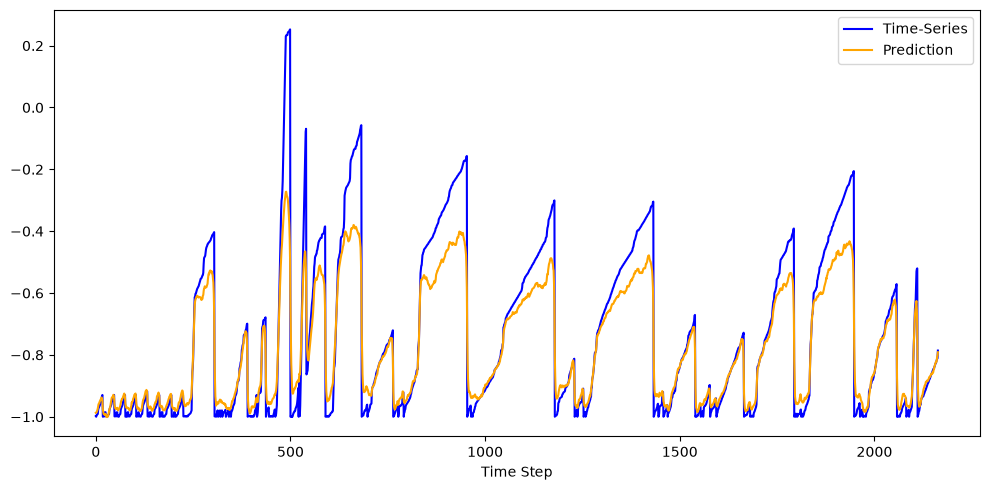

Channel C-2 Signal...
Epoch  25 | D Loss: 7.350189 | G Loss: -0.039469
Epoch  50 | D Loss: 6.416858 | G Loss: -0.047987
Epoch  75 | D Loss: 5.296975 | G Loss: -0.059044
Epoch 100 | D Loss: 4.113943 | G Loss: -0.080081
Epoch 125 | D Loss: 3.106812 | G Loss: -0.154513
Epoch 150 | D Loss: 2.193882 | G Loss: -0.299456
Epoch 175 | D Loss: 1.489899 | G Loss: -0.303605
Epoch 200 | D Loss: 1.186330 | G Loss: -0.333301
Epoch 225 | D Loss: 1.064316 | G Loss: -0.533880
Epoch 250 | D Loss: 1.064218 | G Loss: -0.759426
Epoch 275 | D Loss: 1.146130 | G Loss: -0.973558
Epoch 300 | D Loss: 1.230228 | G Loss: -1.153881
Epoch 325 | D Loss: 1.286634 | G Loss: -1.239808
Epoch 350 | D Loss: 1.323447 | G Loss: -1.269816
Epoch 375 | D Loss: 1.359030 | G Loss: -1.277339
Epoch 400 | D Loss: 1.385913 | G Loss: -1.280948
Epoch 425 | D Loss: 1.358657 | G Loss: -1.232850
Epoch 450 | D Loss: 1.498302 | G Loss: -1.363096
Epoch 475 | D Loss: 1.473055 | G Loss: -1.331309
Epoch 500 | D Loss: 1.378203 | G Loss: -1.24631

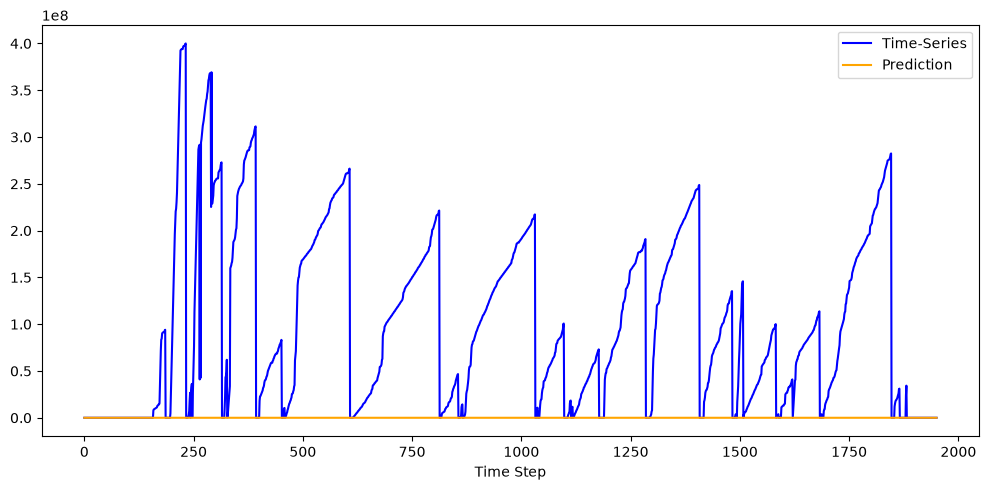

Channel D-14 Signal...
Epoch  25 | D Loss: 1.847993 | G Loss: 0.004208
Epoch  50 | D Loss: 2.049398 | G Loss: -1.404595
Epoch  75 | D Loss: 0.450516 | G Loss: -0.762011
Epoch 100 | D Loss: 0.688407 | G Loss: -0.610537
Epoch 125 | D Loss: 0.851605 | G Loss: -0.858897
Epoch 150 | D Loss: 0.724319 | G Loss: -0.697690
Epoch 175 | D Loss: 0.163558 | G Loss: -0.226590
Epoch 200 | D Loss: 0.568504 | G Loss: -0.514043
Epoch 225 | D Loss: 0.466231 | G Loss: -0.432166
Epoch 250 | D Loss: 0.364160 | G Loss: -0.409738
Epoch 275 | D Loss: 0.247300 | G Loss: -0.321449
Epoch 300 | D Loss: 0.170279 | G Loss: -0.246019
Epoch 325 | D Loss: 0.170364 | G Loss: -0.248814
Epoch 350 | D Loss: 0.221074 | G Loss: -0.280625
Epoch 375 | D Loss: 0.169313 | G Loss: -0.231587
Epoch 400 | D Loss: 0.148405 | G Loss: -0.218541
Epoch 425 | D Loss: 0.165189 | G Loss: -0.304955
Epoch 450 | D Loss: 0.142239 | G Loss: -0.395859
Epoch 475 | D Loss: 0.130228 | G Loss: -0.699716
Epoch 500 | D Loss: 0.103696 | G Loss: -0.99468

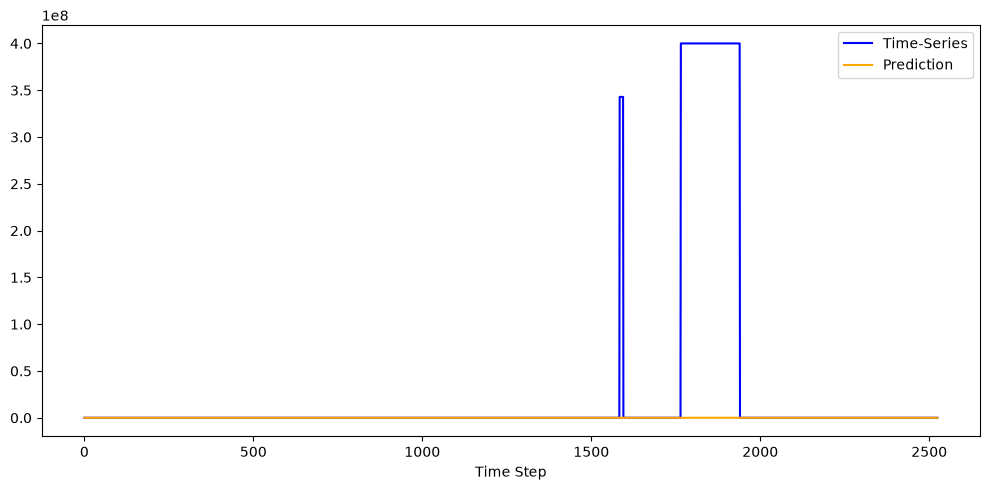

Channel D-15 Signal...
Epoch  25 | D Loss: 4.220263 | G Loss: -0.419690
Epoch  50 | D Loss: 0.985227 | G Loss: 0.747077
Epoch  75 | D Loss: 1.126891 | G Loss: 0.015015
Epoch 100 | D Loss: 0.118617 | G Loss: -0.037970
Epoch 125 | D Loss: -0.110957 | G Loss: -0.185264
Epoch 150 | D Loss: 0.042070 | G Loss: 0.107580
Epoch 175 | D Loss: -0.065370 | G Loss: 0.007753
Epoch 200 | D Loss: -0.103384 | G Loss: 0.102447
Epoch 225 | D Loss: -0.098461 | G Loss: 0.078247
Epoch 250 | D Loss: -0.173977 | G Loss: 0.119511
Epoch 275 | D Loss: -0.788563 | G Loss: -2.444334
Epoch 300 | D Loss: -1.813703 | G Loss: 2.046777
Epoch 325 | D Loss: 0.624316 | G Loss: -0.137017
Epoch 350 | D Loss: -0.022231 | G Loss: 0.080043
Epoch 375 | D Loss: -0.056331 | G Loss: 0.157498
Epoch 400 | D Loss: -0.119939 | G Loss: 0.209465
Epoch 425 | D Loss: -0.197529 | G Loss: 0.244702
Epoch 450 | D Loss: -0.282553 | G Loss: 0.250139
Epoch 475 | D Loss: -0.425910 | G Loss: 0.278510
Epoch 500 | D Loss: -0.459959 | G Loss: -0.0410

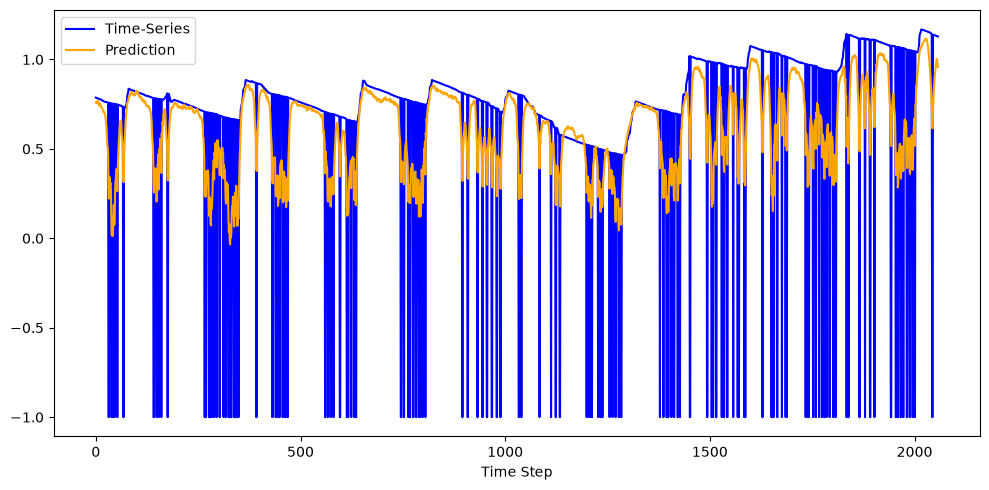

Channel D-16 Signal...
Epoch  25 | D Loss: 5.425078 | G Loss: -0.242615
Epoch  50 | D Loss: 3.704386 | G Loss: 0.188603
Epoch  75 | D Loss: 3.257653 | G Loss: -0.480263
Epoch 100 | D Loss: 4.707924 | G Loss: -2.824949
Epoch 125 | D Loss: 2.605298 | G Loss: -1.631686
Epoch 150 | D Loss: 0.378899 | G Loss: -0.398899
Epoch 175 | D Loss: -1.399630 | G Loss: 1.095028
Epoch 200 | D Loss: -0.488563 | G Loss: 0.196542
Epoch 225 | D Loss: 2.426939 | G Loss: -2.357354
Epoch 250 | D Loss: 4.308773 | G Loss: -3.986622
Epoch 275 | D Loss: 3.728235 | G Loss: -3.295556
Epoch 300 | D Loss: 2.848875 | G Loss: -2.504446
Epoch 325 | D Loss: 1.926984 | G Loss: -1.690607
Epoch 350 | D Loss: 1.119745 | G Loss: -0.927486
Epoch 375 | D Loss: 0.500076 | G Loss: -0.409433
Epoch 400 | D Loss: 1.784151 | G Loss: -1.720652
Epoch 425 | D Loss: 0.951080 | G Loss: -0.972913
Epoch 450 | D Loss: 0.475268 | G Loss: -0.542889
Epoch 475 | D Loss: 0.201631 | G Loss: -0.256898
Epoch 500 | D Loss: 0.056210 | G Loss: -0.08842

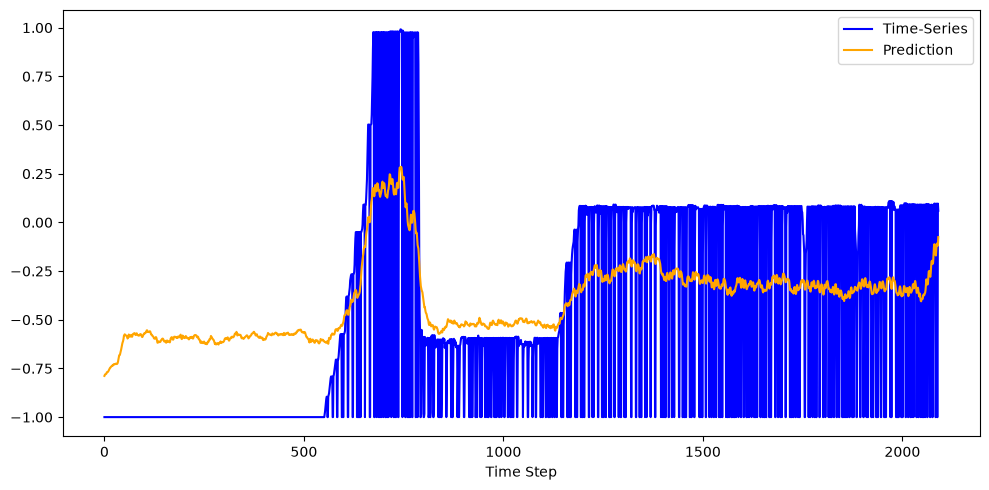

Channel F-4 Signal...
Epoch  25 | D Loss: 5.390368 | G Loss: -1.097774
Epoch  50 | D Loss: 1.597163 | G Loss: 0.864918
Epoch  75 | D Loss: 0.976994 | G Loss: -0.295001
Epoch 100 | D Loss: -0.169661 | G Loss: 0.200607
Epoch 125 | D Loss: -0.149850 | G Loss: -0.169236
Epoch 150 | D Loss: -0.863664 | G Loss: 0.899730
Epoch 175 | D Loss: 0.108990 | G Loss: -0.056663
Epoch 200 | D Loss: 0.001540 | G Loss: -0.072553
Epoch 225 | D Loss: 0.033734 | G Loss: -0.077280
Epoch 250 | D Loss: 0.046167 | G Loss: -0.021952
Epoch 275 | D Loss: 0.016942 | G Loss: -0.033484
Epoch 300 | D Loss: -0.037292 | G Loss: -0.071742
Epoch 325 | D Loss: -0.011384 | G Loss: -0.018982
Epoch 350 | D Loss: 0.047539 | G Loss: -0.019012
Epoch 375 | D Loss: -0.039133 | G Loss: 0.070336
Epoch 400 | D Loss: -0.047264 | G Loss: 0.107141
Epoch 425 | D Loss: -0.042853 | G Loss: 0.092677
Epoch 450 | D Loss: -0.021344 | G Loss: 0.061525
Epoch 475 | D Loss: 0.058845 | G Loss: -0.052412
Epoch 500 | D Loss: 0.073257 | G Loss: -0.062

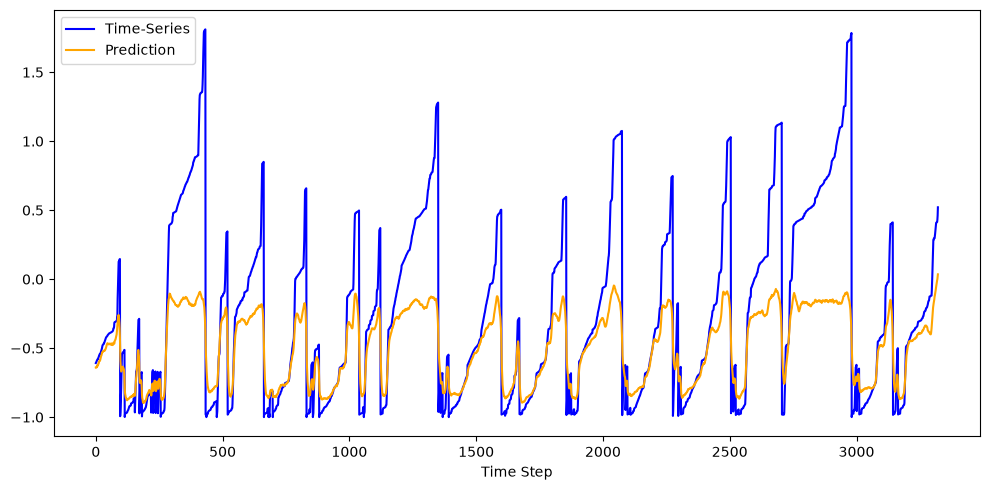

Channel F-5 Signal...
Epoch  25 | D Loss: 4.328875 | G Loss: -0.055270
Epoch  50 | D Loss: 1.520844 | G Loss: 0.263188
Epoch  75 | D Loss: 0.151750 | G Loss: -0.071461
Epoch 100 | D Loss: 0.444160 | G Loss: -0.243579
Epoch 125 | D Loss: 2.071883 | G Loss: -2.132633
Epoch 150 | D Loss: 1.270317 | G Loss: -1.259322
Epoch 175 | D Loss: -0.124581 | G Loss: 0.066479
Epoch 200 | D Loss: -0.220103 | G Loss: 0.212747
Epoch 225 | D Loss: -0.425224 | G Loss: 0.648761
Epoch 250 | D Loss: 0.372857 | G Loss: -0.468622
Epoch 275 | D Loss: 0.204606 | G Loss: -0.301436
Epoch 300 | D Loss: 0.202617 | G Loss: -0.279653
Epoch 325 | D Loss: 0.182332 | G Loss: -0.255333
Epoch 350 | D Loss: 0.129938 | G Loss: -0.188466
Epoch 375 | D Loss: 0.069130 | G Loss: -0.120830
Epoch 400 | D Loss: 0.049790 | G Loss: -0.116810
Epoch 425 | D Loss: 0.056787 | G Loss: -0.151922
Epoch 450 | D Loss: 0.015659 | G Loss: -0.067424
Epoch 475 | D Loss: 0.011036 | G Loss: -0.096089
Epoch 500 | D Loss: 0.005326 | G Loss: -0.074411

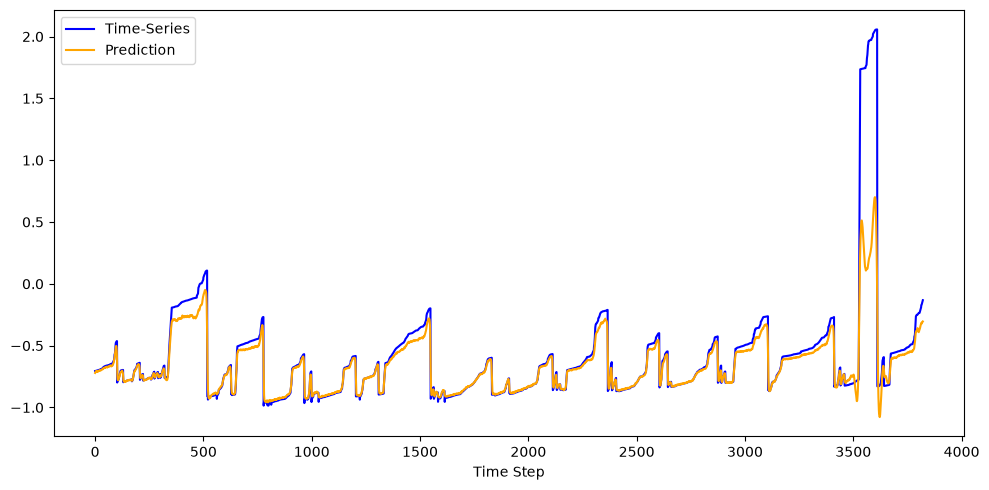

Channel F-7 Signal...
Epoch  25 | D Loss: 5.402982 | G Loss: -0.004517
Epoch  50 | D Loss: 2.454959 | G Loss: -0.240785
Epoch  75 | D Loss: 0.321597 | G Loss: 0.175629
Epoch 100 | D Loss: 0.035514 | G Loss: 0.093761
Epoch 125 | D Loss: 0.099471 | G Loss: -0.028210
Epoch 150 | D Loss: 0.152304 | G Loss: -0.042729
Epoch 175 | D Loss: 0.094983 | G Loss: 0.054660
Epoch 200 | D Loss: 0.196333 | G Loss: -0.073264
Epoch 225 | D Loss: 0.251309 | G Loss: -0.141216
Epoch 250 | D Loss: 0.278012 | G Loss: -0.174621
Epoch 275 | D Loss: 0.231298 | G Loss: -0.135852
Epoch 300 | D Loss: 0.318051 | G Loss: -0.216870
Epoch 325 | D Loss: 0.251901 | G Loss: -0.131905
Epoch 350 | D Loss: 0.219175 | G Loss: -0.187301
Epoch 375 | D Loss: 0.157023 | G Loss: -0.192363
Epoch 400 | D Loss: 0.295556 | G Loss: -0.252839
Epoch 425 | D Loss: 0.235386 | G Loss: -0.213382
Epoch 450 | D Loss: 0.184513 | G Loss: -0.171653
Epoch 475 | D Loss: 0.162185 | G Loss: -0.159339
Epoch 500 | D Loss: 0.123468 | G Loss: -0.211224
E

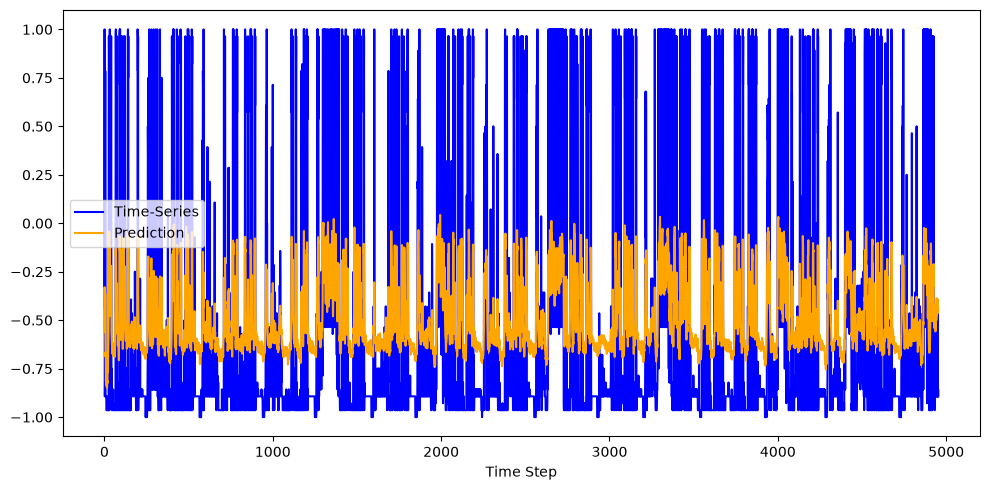

Channel F-8 Signal...
Epoch  25 | D Loss: 3.677872 | G Loss: -0.219818
Epoch  50 | D Loss: 5.344280 | G Loss: -3.016310
Epoch  75 | D Loss: 2.334892 | G Loss: -1.200735
Epoch 100 | D Loss: 0.301140 | G Loss: 0.237847
Epoch 125 | D Loss: 0.098292 | G Loss: 0.517528
Epoch 150 | D Loss: -0.218671 | G Loss: 0.780476
Epoch 175 | D Loss: 0.342827 | G Loss: -0.343262
Epoch 200 | D Loss: 0.228138 | G Loss: -0.339728
Epoch 225 | D Loss: 0.200062 | G Loss: -0.310951
Epoch 250 | D Loss: 0.127244 | G Loss: -0.223372
Epoch 275 | D Loss: 0.088143 | G Loss: -0.199579
Epoch 300 | D Loss: 0.060938 | G Loss: -0.199906
Epoch 325 | D Loss: 0.028584 | G Loss: -0.301818
Epoch 350 | D Loss: 0.052166 | G Loss: -0.347881
Epoch 375 | D Loss: 0.034379 | G Loss: -0.406711
Epoch 400 | D Loss: 0.040326 | G Loss: -0.272216
Epoch 425 | D Loss: 0.026587 | G Loss: -0.308287
Epoch 450 | D Loss: 0.066735 | G Loss: -0.374059
Epoch 475 | D Loss: 0.031009 | G Loss: -0.705631
Epoch 500 | D Loss: -0.016991 | G Loss: -0.478782

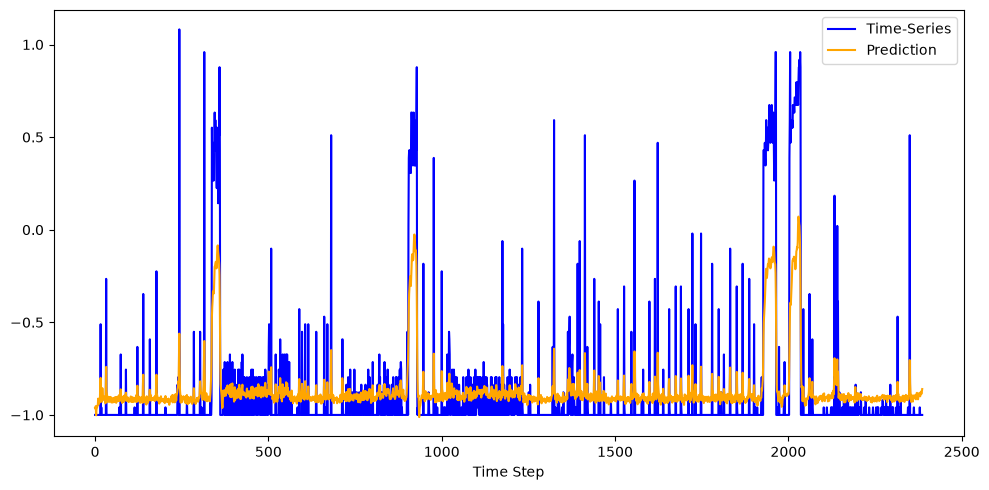

Channel M-1 Signal...
Epoch  25 | D Loss: 4.734881 | G Loss: 0.042937
Epoch  50 | D Loss: 2.072214 | G Loss: 0.014398
Epoch  75 | D Loss: 0.404399 | G Loss: -0.062038
Epoch 100 | D Loss: 0.075078 | G Loss: -0.045515
Epoch 125 | D Loss: 0.253018 | G Loss: -0.200802
Epoch 150 | D Loss: 0.004202 | G Loss: 0.061101
Epoch 175 | D Loss: 0.165594 | G Loss: -0.088192
Epoch 200 | D Loss: 0.119653 | G Loss: -0.044505
Epoch 225 | D Loss: 0.090671 | G Loss: -0.028755
Epoch 250 | D Loss: 0.080419 | G Loss: 0.006487
Epoch 275 | D Loss: 0.070781 | G Loss: 0.084222
Epoch 300 | D Loss: 0.081233 | G Loss: 0.121639
Epoch 325 | D Loss: 0.086575 | G Loss: 0.167279
Epoch 350 | D Loss: 0.067032 | G Loss: 0.068547
Epoch 375 | D Loss: 0.082557 | G Loss: 0.145690
Epoch 400 | D Loss: 0.059878 | G Loss: 0.138904
Epoch 425 | D Loss: 0.056790 | G Loss: 0.135872
Epoch 450 | D Loss: 0.085102 | G Loss: 0.090897
Epoch 475 | D Loss: 0.091843 | G Loss: 0.113693
Epoch 500 | D Loss: 0.095809 | G Loss: 0.146660
Epoch 525 | 

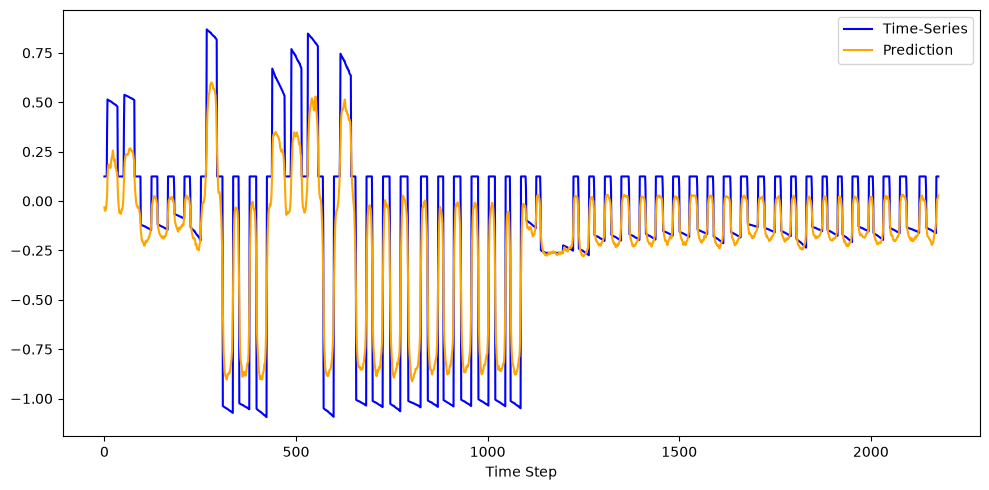

Channel M-2 Signal...
Epoch  25 | D Loss: 5.230768 | G Loss: -0.779971
Epoch  50 | D Loss: 2.645431 | G Loss: 0.184327
Epoch  75 | D Loss: 0.864327 | G Loss: -0.027573
Epoch 100 | D Loss: -0.083545 | G Loss: 0.582216
Epoch 125 | D Loss: 0.436061 | G Loss: -0.153132
Epoch 150 | D Loss: 0.508792 | G Loss: -0.930937
Epoch 175 | D Loss: 0.364139 | G Loss: -0.179046
Epoch 200 | D Loss: 0.950991 | G Loss: -0.828526
Epoch 225 | D Loss: 0.531036 | G Loss: -0.413717
Epoch 250 | D Loss: 0.335051 | G Loss: -0.146986
Epoch 275 | D Loss: 0.378435 | G Loss: -0.329283
Epoch 300 | D Loss: -0.089458 | G Loss: -0.423937
Epoch 325 | D Loss: 0.058209 | G Loss: -0.242367
Epoch 350 | D Loss: -0.147786 | G Loss: 0.061487
Epoch 375 | D Loss: -0.062658 | G Loss: 0.031247
Epoch 400 | D Loss: -0.023409 | G Loss: 0.004654
Epoch 425 | D Loss: 0.072990 | G Loss: -0.048858
Epoch 450 | D Loss: 0.112014 | G Loss: -0.127243
Epoch 475 | D Loss: 0.096702 | G Loss: -0.130043
Epoch 500 | D Loss: 0.103045 | G Loss: 0.019929

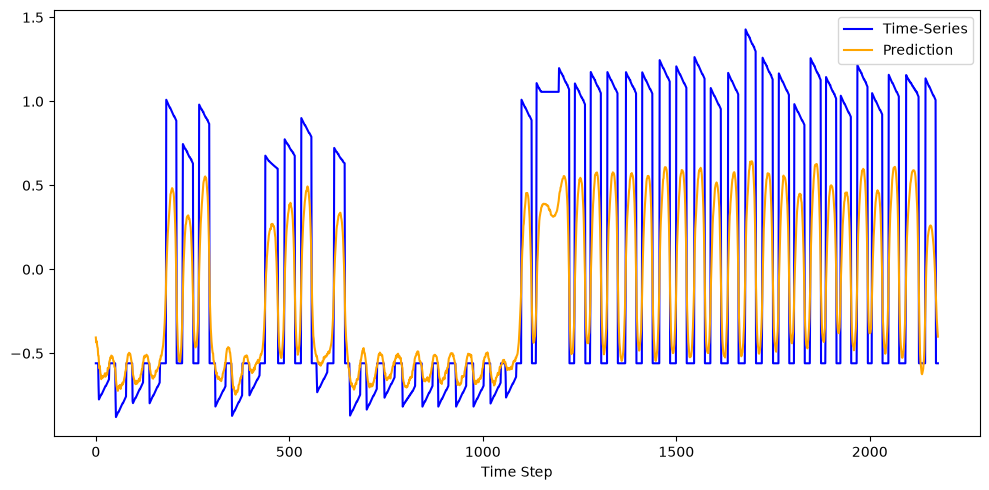

Channel M-3 Signal...
Epoch  25 | D Loss: 2.879587 | G Loss: -0.415707
Epoch  50 | D Loss: 0.351878 | G Loss: 0.373365
Epoch  75 | D Loss: 0.014344 | G Loss: -0.353353
Epoch 100 | D Loss: 0.495765 | G Loss: -0.505500
Epoch 125 | D Loss: -2.081750 | G Loss: 2.440994
Epoch 150 | D Loss: 1.946332 | G Loss: -1.559352
Epoch 175 | D Loss: -0.452580 | G Loss: 0.422505
Epoch 200 | D Loss: 0.043744 | G Loss: -0.160481
Epoch 225 | D Loss: 0.048039 | G Loss: -0.078585
Epoch 250 | D Loss: 0.152677 | G Loss: -0.243622
Epoch 275 | D Loss: 0.168217 | G Loss: -0.206991
Epoch 300 | D Loss: 0.171598 | G Loss: -0.261860
Epoch 325 | D Loss: 0.168984 | G Loss: -0.234809
Epoch 350 | D Loss: 0.150951 | G Loss: -0.222309
Epoch 375 | D Loss: 0.177314 | G Loss: -0.228920
Epoch 400 | D Loss: 0.070241 | G Loss: -0.079048
Epoch 425 | D Loss: 0.025791 | G Loss: -0.369720
Epoch 450 | D Loss: 0.126847 | G Loss: -0.111583
Epoch 475 | D Loss: 0.147898 | G Loss: -0.226559
Epoch 500 | D Loss: 0.089380 | G Loss: -0.110550

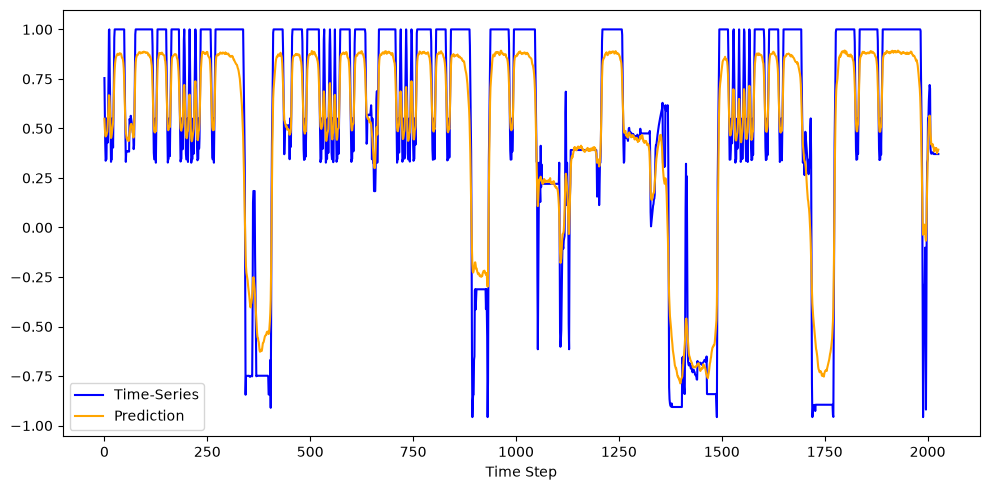

Channel M-4 Signal...
Epoch  25 | D Loss: 5.926065 | G Loss: -0.109150
Epoch  50 | D Loss: 4.584749 | G Loss: -0.298004
Epoch  75 | D Loss: 1.854207 | G Loss: 0.830499
Epoch 100 | D Loss: 1.354285 | G Loss: -0.918669
Epoch 125 | D Loss: 0.728079 | G Loss: -0.515501
Epoch 150 | D Loss: 0.865387 | G Loss: -0.653013
Epoch 175 | D Loss: 0.363708 | G Loss: -0.245024
Epoch 200 | D Loss: -0.084140 | G Loss: 0.026969
Epoch 225 | D Loss: 0.248987 | G Loss: -0.457498
Epoch 250 | D Loss: 0.504607 | G Loss: -0.620149
Epoch 275 | D Loss: 0.409411 | G Loss: -0.415356
Epoch 300 | D Loss: 0.357123 | G Loss: -0.235389
Epoch 325 | D Loss: 0.321794 | G Loss: -0.245842
Epoch 350 | D Loss: 0.297350 | G Loss: -0.164603
Epoch 375 | D Loss: 0.311139 | G Loss: -0.196880
Epoch 400 | D Loss: 0.295273 | G Loss: -0.220674
Epoch 425 | D Loss: 0.262885 | G Loss: -0.210740
Epoch 450 | D Loss: 0.196396 | G Loss: -0.184929
Epoch 475 | D Loss: 0.109658 | G Loss: -0.150823
Epoch 500 | D Loss: 0.172910 | G Loss: -0.274817

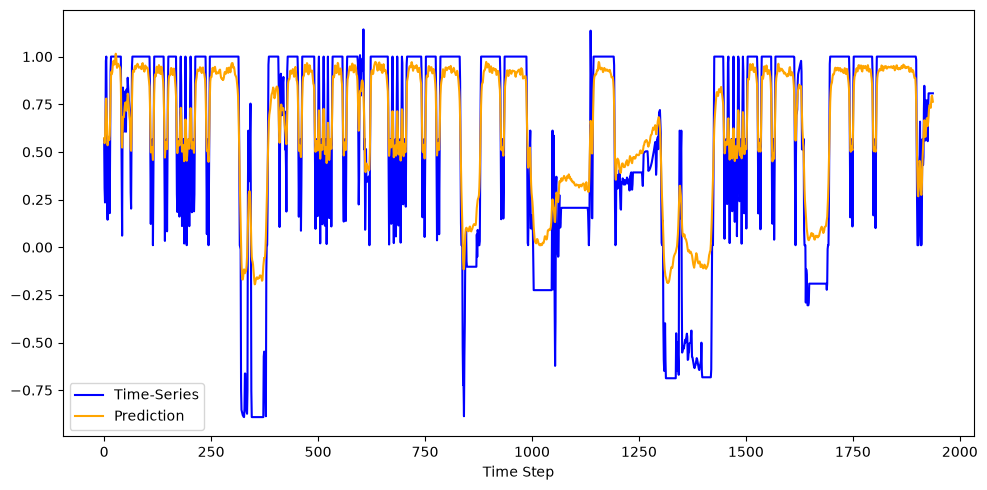

Channel M-5 Signal...
Epoch  25 | D Loss: 4.413778 | G Loss: -0.577550
Epoch  50 | D Loss: 1.029744 | G Loss: 0.607323
Epoch  75 | D Loss: 1.387500 | G Loss: -0.229802
Epoch 100 | D Loss: -0.059361 | G Loss: 0.546294
Epoch 125 | D Loss: 1.736146 | G Loss: -1.544519
Epoch 150 | D Loss: 1.259656 | G Loss: -1.361867
Epoch 175 | D Loss: 1.381872 | G Loss: -1.664312
Epoch 200 | D Loss: 0.536423 | G Loss: -0.513304
Epoch 225 | D Loss: 0.329986 | G Loss: -0.308145
Epoch 250 | D Loss: 0.558302 | G Loss: -0.558873
Epoch 275 | D Loss: 0.532489 | G Loss: -0.598593
Epoch 300 | D Loss: 0.480180 | G Loss: -0.561358
Epoch 325 | D Loss: 0.445211 | G Loss: -0.503197
Epoch 350 | D Loss: 0.427587 | G Loss: -0.449356
Epoch 375 | D Loss: 0.343055 | G Loss: -0.246558
Epoch 400 | D Loss: 0.338033 | G Loss: -0.202527
Epoch 425 | D Loss: 0.296836 | G Loss: -0.121077
Epoch 450 | D Loss: 0.288072 | G Loss: -0.139372
Epoch 475 | D Loss: 0.216103 | G Loss: -0.030571
Epoch 500 | D Loss: 0.131978 | G Loss: 0.098123


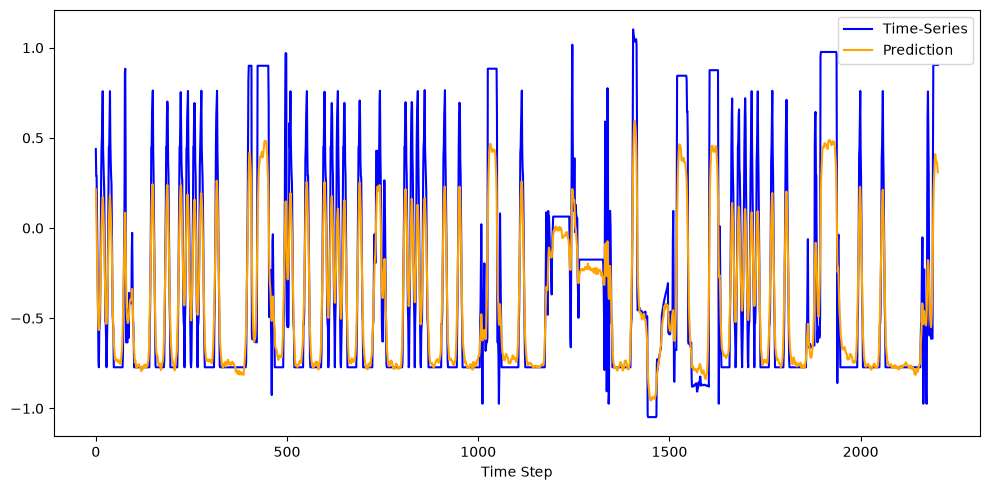

Channel M-6 Signal...
Epoch  25 | D Loss: 7.267796 | G Loss: -0.371042
Epoch  50 | D Loss: 3.880124 | G Loss: 0.417327
Epoch  75 | D Loss: 1.579253 | G Loss: -0.153794
Epoch 100 | D Loss: 2.632102 | G Loss: -1.189335
Epoch 125 | D Loss: -2.343764 | G Loss: 4.007569
Epoch 150 | D Loss: 0.400420 | G Loss: 1.726737
Epoch 175 | D Loss: 5.049793 | G Loss: -2.853622
Epoch 200 | D Loss: 5.489154 | G Loss: -3.624273
Epoch 225 | D Loss: 3.549210 | G Loss: -2.608481
Epoch 250 | D Loss: 1.513321 | G Loss: -1.870672
Epoch 275 | D Loss: 2.420259 | G Loss: -3.534618
Epoch 300 | D Loss: 4.120609 | G Loss: -4.344718
Epoch 325 | D Loss: 3.772398 | G Loss: -3.177226
Epoch 350 | D Loss: 2.867642 | G Loss: -2.176091
Epoch 375 | D Loss: 1.880150 | G Loss: -1.360711
Epoch 400 | D Loss: 1.016168 | G Loss: -0.784467
Epoch 425 | D Loss: 0.804849 | G Loss: -0.808099
Epoch 450 | D Loss: 0.382305 | G Loss: -0.271226
Epoch 475 | D Loss: 0.329178 | G Loss: -0.050066
Epoch 500 | D Loss: 0.142716 | G Loss: 0.318895
E

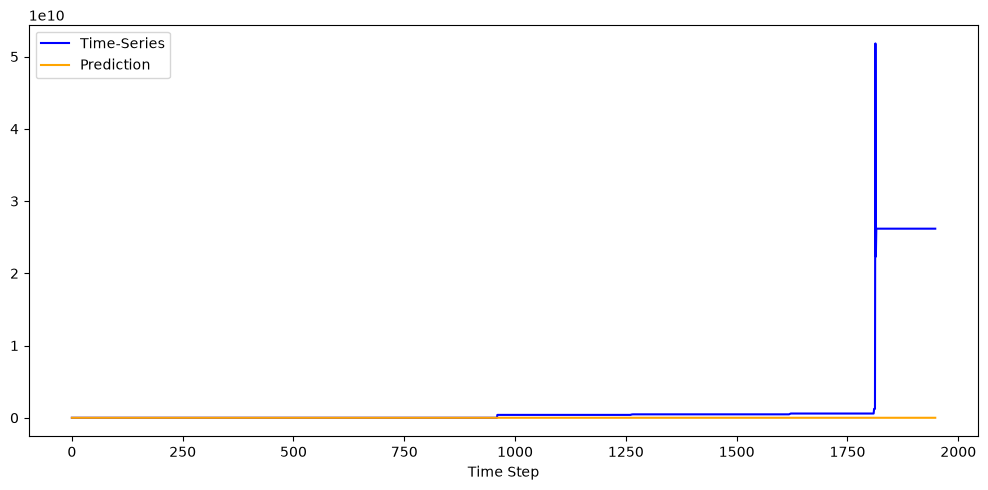

Channel M-7 Signal...
Epoch  25 | D Loss: 6.449943 | G Loss: -0.864047
Epoch  50 | D Loss: 5.751636 | G Loss: -1.412914
Epoch  75 | D Loss: 3.136683 | G Loss: -0.005174
Epoch 100 | D Loss: 0.710622 | G Loss: 1.533580
Epoch 125 | D Loss: 2.536235 | G Loss: -0.653062
Epoch 150 | D Loss: 1.501740 | G Loss: -0.534708
Epoch 175 | D Loss: 0.674165 | G Loss: -0.175723
Epoch 200 | D Loss: 0.286751 | G Loss: -0.042220
Epoch 225 | D Loss: 0.243912 | G Loss: -0.109052
Epoch 250 | D Loss: 0.292193 | G Loss: -0.150937
Epoch 275 | D Loss: 0.282321 | G Loss: -0.158200
Epoch 300 | D Loss: 0.300008 | G Loss: -0.157145
Epoch 325 | D Loss: 0.389139 | G Loss: -0.211737
Epoch 350 | D Loss: 0.389217 | G Loss: -0.383451
Epoch 375 | D Loss: 0.458038 | G Loss: -0.375763
Epoch 400 | D Loss: 0.515474 | G Loss: -0.433021
Epoch 425 | D Loss: 0.559760 | G Loss: -0.520515
Epoch 450 | D Loss: 0.612000 | G Loss: -0.596928
Epoch 475 | D Loss: 0.534665 | G Loss: -0.637194
Epoch 500 | D Loss: 0.521150 | G Loss: -0.715574

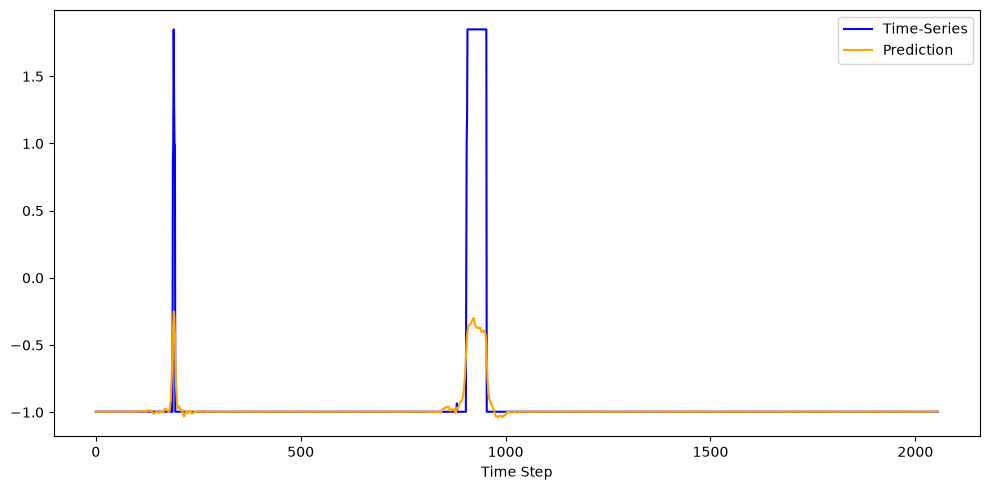

Channel P-10 Signal...
Epoch  25 | D Loss: 1.567079 | G Loss: 0.235178
Epoch  50 | D Loss: 0.123089 | G Loss: 0.283055
Epoch  75 | D Loss: 0.015285 | G Loss: -0.010806
Epoch 100 | D Loss: -0.063953 | G Loss: -0.078882
Epoch 125 | D Loss: 0.257181 | G Loss: -0.238033
Epoch 150 | D Loss: 0.051837 | G Loss: 0.164165
Epoch 175 | D Loss: 0.165053 | G Loss: -0.006869
Epoch 200 | D Loss: 0.162461 | G Loss: -0.091315
Epoch 225 | D Loss: 0.284941 | G Loss: -0.071129
Epoch 250 | D Loss: 0.718851 | G Loss: -0.531977
Epoch 275 | D Loss: 0.621941 | G Loss: -0.335884
Epoch 300 | D Loss: 2.042208 | G Loss: -1.570037
Epoch 325 | D Loss: 0.994806 | G Loss: -0.867391
Epoch 350 | D Loss: 0.447283 | G Loss: -0.604687
Epoch 375 | D Loss: 0.374357 | G Loss: -0.589364
Epoch 400 | D Loss: 0.358699 | G Loss: -0.524270
Epoch 425 | D Loss: 0.306611 | G Loss: -0.400518
Epoch 450 | D Loss: 0.311836 | G Loss: -0.371180
Epoch 475 | D Loss: 0.196922 | G Loss: -0.242867
Epoch 500 | D Loss: 0.158805 | G Loss: -0.194741

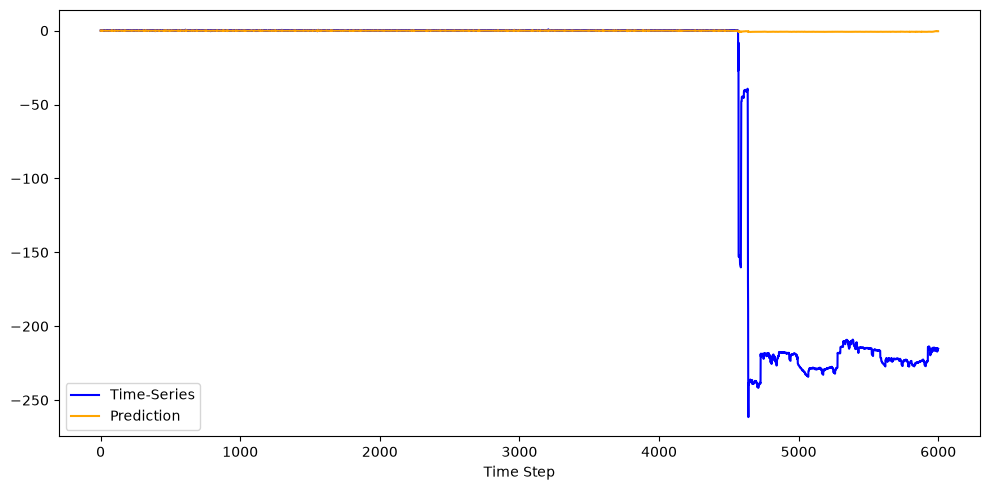

Channel P-11 Signal...
Epoch  25 | D Loss: 1.194670 | G Loss: 0.096974
Epoch  50 | D Loss: 0.103476 | G Loss: 0.081718
Epoch  75 | D Loss: 0.079779 | G Loss: 0.177591
Epoch 100 | D Loss: 0.098763 | G Loss: 0.186995
Epoch 125 | D Loss: 0.084887 | G Loss: 0.237494
Epoch 150 | D Loss: 0.123245 | G Loss: 0.161115
Epoch 175 | D Loss: 0.100305 | G Loss: 0.207939
Epoch 200 | D Loss: 0.081748 | G Loss: 0.273043
Epoch 225 | D Loss: 0.068329 | G Loss: 0.289849
Epoch 250 | D Loss: 0.068011 | G Loss: 0.277293
Epoch 275 | D Loss: 0.054016 | G Loss: 0.236233
Epoch 300 | D Loss: 0.057417 | G Loss: 0.283870
Epoch 325 | D Loss: -0.060096 | G Loss: 0.263925
Epoch 350 | D Loss: -0.033044 | G Loss: 0.623110
Epoch 375 | D Loss: 0.143872 | G Loss: 0.517847
Epoch 400 | D Loss: 0.151064 | G Loss: 0.415651
Epoch 425 | D Loss: 0.153966 | G Loss: 0.345750
Epoch 450 | D Loss: 0.147751 | G Loss: 0.255861
Epoch 475 | D Loss: 0.145210 | G Loss: 0.214364
Epoch 500 | D Loss: 0.168804 | G Loss: 0.175730
Epoch 525 | D L

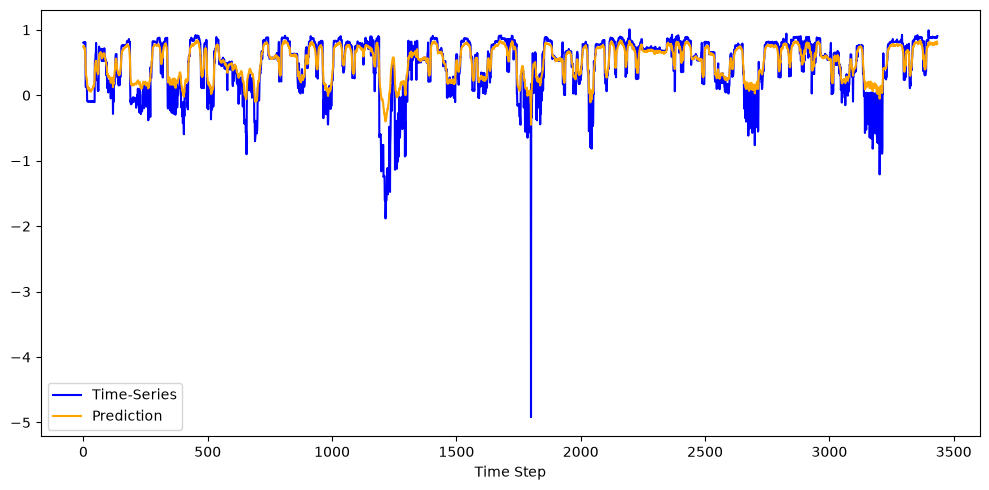

Channel P-14 Signal...
Epoch  25 | D Loss: 3.603589 | G Loss: 0.177358
Epoch  50 | D Loss: 1.724217 | G Loss: -0.485173
Epoch  75 | D Loss: 2.119913 | G Loss: -1.683288
Epoch 100 | D Loss: 1.339952 | G Loss: -1.115512
Epoch 125 | D Loss: 0.231962 | G Loss: -0.119753
Epoch 150 | D Loss: 0.172457 | G Loss: -0.063588
Epoch 175 | D Loss: 0.129338 | G Loss: -0.021081
Epoch 200 | D Loss: -0.005714 | G Loss: 0.130692
Epoch 225 | D Loss: 0.096573 | G Loss: -0.031439
Epoch 250 | D Loss: 0.027787 | G Loss: -0.060203
Epoch 275 | D Loss: 0.043864 | G Loss: -0.124357
Epoch 300 | D Loss: 0.043154 | G Loss: -0.162232
Epoch 325 | D Loss: 0.064099 | G Loss: -0.237926
Epoch 350 | D Loss: 0.059011 | G Loss: -0.291072
Epoch 375 | D Loss: 0.046198 | G Loss: -0.342116
Epoch 400 | D Loss: 0.002167 | G Loss: -0.250182
Epoch 425 | D Loss: 0.031251 | G Loss: -0.297754
Epoch 450 | D Loss: 0.029657 | G Loss: -0.309899
Epoch 475 | D Loss: 0.024953 | G Loss: -0.305315
Epoch 500 | D Loss: 0.019619 | G Loss: -0.30595

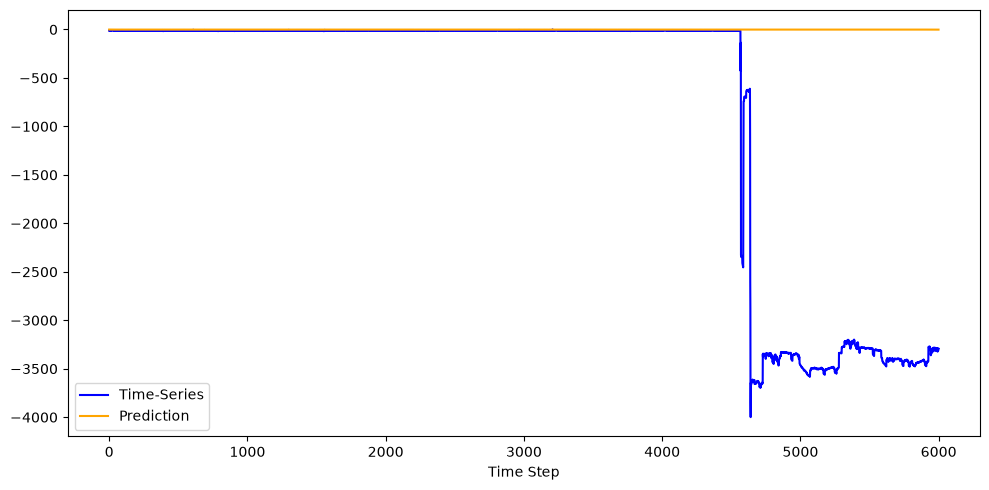

Channel P-15 Signal...
Epoch  25 | D Loss: 3.311599 | G Loss: -0.365945
Epoch  50 | D Loss: 2.891293 | G Loss: -1.704165
Epoch  75 | D Loss: 0.403691 | G Loss: -0.188625
Epoch 100 | D Loss: 0.822074 | G Loss: -0.831577
Epoch 125 | D Loss: 0.915075 | G Loss: -0.849518
Epoch 150 | D Loss: 0.851343 | G Loss: -0.807088
Epoch 175 | D Loss: 0.656694 | G Loss: -0.557744
Epoch 200 | D Loss: 0.426474 | G Loss: -0.348566
Epoch 225 | D Loss: 0.257790 | G Loss: -0.127316
Epoch 250 | D Loss: 0.276973 | G Loss: -0.185693
Epoch 275 | D Loss: 0.149770 | G Loss: -0.032381
Epoch 300 | D Loss: 0.112521 | G Loss: -0.016863
Epoch 325 | D Loss: 0.126601 | G Loss: -0.038270
Epoch 350 | D Loss: 0.128020 | G Loss: -0.003022
Epoch 375 | D Loss: 0.391686 | G Loss: -0.239905
Epoch 400 | D Loss: 0.330466 | G Loss: -0.144075
Epoch 425 | D Loss: 0.167308 | G Loss: 0.082642
Epoch 450 | D Loss: 0.124030 | G Loss: 0.076313
Epoch 475 | D Loss: 0.082197 | G Loss: 0.141713
Epoch 500 | D Loss: 0.138512 | G Loss: 0.076496
E

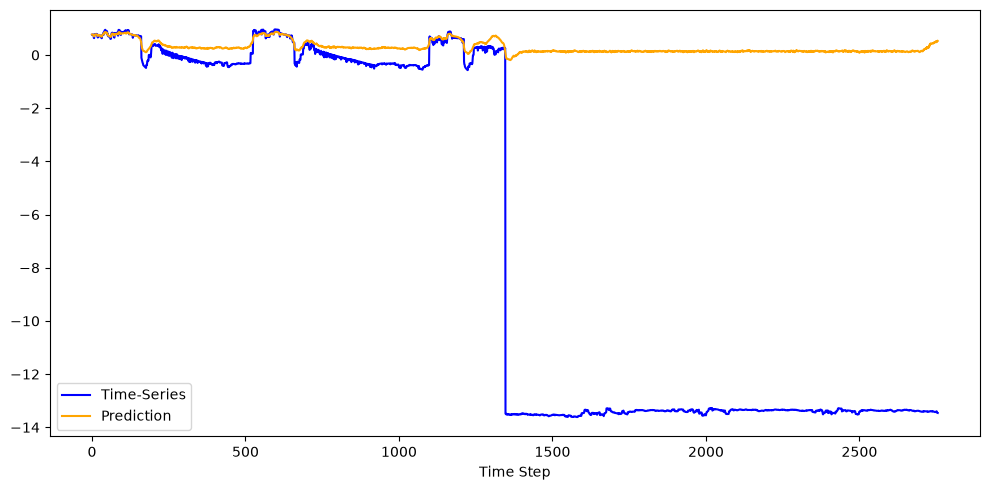

Channel S-2 Signal...
Epoch  25 | D Loss: 6.614755 | G Loss: 0.032104
Epoch  50 | D Loss: 5.565087 | G Loss: -0.182628
Epoch  75 | D Loss: 4.406720 | G Loss: 0.067575
Epoch 100 | D Loss: 3.775357 | G Loss: 0.134103
Epoch 125 | D Loss: 2.959348 | G Loss: 0.015314
Epoch 150 | D Loss: 2.073700 | G Loss: 0.025677
Epoch 175 | D Loss: 2.661937 | G Loss: -0.946705
Epoch 200 | D Loss: 2.140989 | G Loss: -1.466440
Epoch 225 | D Loss: 1.733003 | G Loss: -1.219906
Epoch 250 | D Loss: 1.060217 | G Loss: -0.392707
Epoch 275 | D Loss: 1.085676 | G Loss: -0.426465
Epoch 300 | D Loss: 1.305088 | G Loss: -1.038837
Epoch 325 | D Loss: 1.418270 | G Loss: -1.461485
Epoch 350 | D Loss: 1.745665 | G Loss: -1.721860
Epoch 375 | D Loss: 2.055482 | G Loss: -1.849682
Epoch 400 | D Loss: 1.969781 | G Loss: -1.657104
Epoch 425 | D Loss: 1.818264 | G Loss: -1.473732
Epoch 450 | D Loss: 1.623264 | G Loss: -1.259488
Epoch 475 | D Loss: 1.409645 | G Loss: -1.034558
Epoch 500 | D Loss: 1.218141 | G Loss: -0.834374
Epo

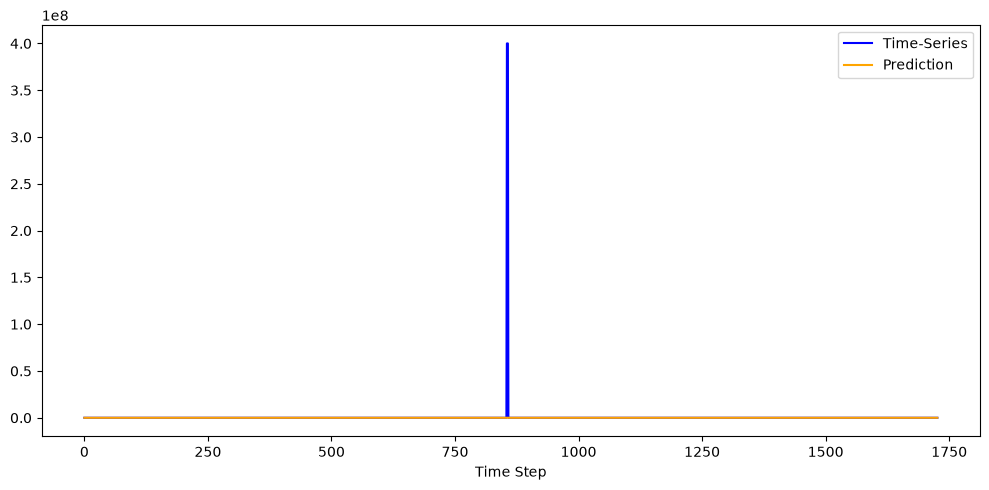

Channel T-12 Signal...
Epoch  25 | D Loss: 7.469166 | G Loss: -0.051090
Epoch  50 | D Loss: 5.605729 | G Loss: -0.053443
Epoch  75 | D Loss: 3.644789 | G Loss: -0.126507
Epoch 100 | D Loss: 2.155520 | G Loss: -0.083037
Epoch 125 | D Loss: 1.543663 | G Loss: -0.365526
Epoch 150 | D Loss: 1.028248 | G Loss: -0.503010
Epoch 175 | D Loss: 0.726872 | G Loss: -0.554413
Epoch 200 | D Loss: 0.609940 | G Loss: -0.581336
Epoch 225 | D Loss: 0.567056 | G Loss: -0.594761
Epoch 250 | D Loss: 0.511550 | G Loss: -0.553030
Epoch 275 | D Loss: 0.261619 | G Loss: -0.298737
Epoch 300 | D Loss: -0.288820 | G Loss: 0.266842
Epoch 325 | D Loss: 0.080927 | G Loss: -0.134029
Epoch 350 | D Loss: 0.344613 | G Loss: -0.371026
Epoch 375 | D Loss: 0.450867 | G Loss: -0.457474
Epoch 400 | D Loss: 0.320630 | G Loss: -0.307494
Epoch 425 | D Loss: 0.150899 | G Loss: -0.103873
Epoch 450 | D Loss: 0.209714 | G Loss: -0.140929
Epoch 475 | D Loss: 0.266872 | G Loss: -0.194597
Epoch 500 | D Loss: 0.251731 | G Loss: -0.1940

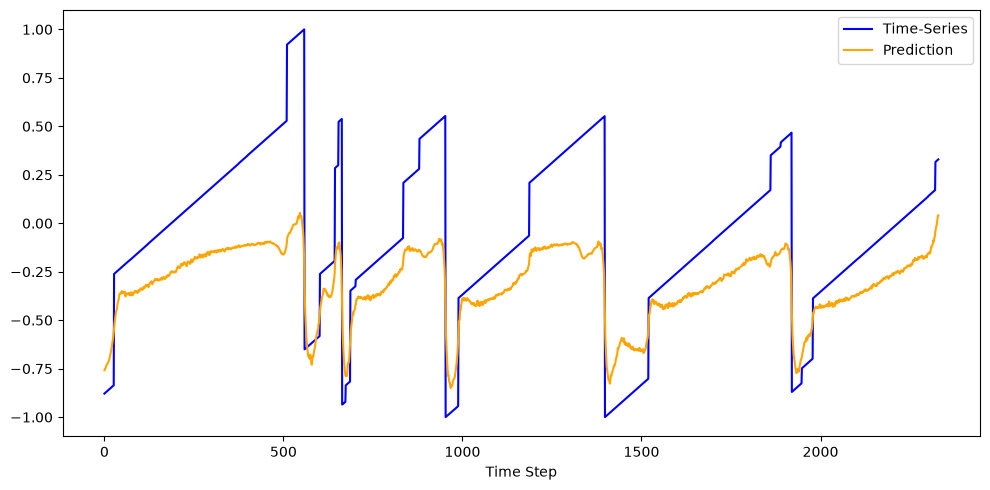

Channel T-13 Signal...
Epoch  25 | D Loss: 6.401164 | G Loss: 0.087947
Epoch  50 | D Loss: 4.412600 | G Loss: -0.022295
Epoch  75 | D Loss: 2.804029 | G Loss: -0.115745
Epoch 100 | D Loss: 1.638978 | G Loss: -0.069873
Epoch 125 | D Loss: 0.814274 | G Loss: 0.000729
Epoch 150 | D Loss: 0.416998 | G Loss: -0.179130
Epoch 175 | D Loss: 0.171964 | G Loss: -0.129417
Epoch 200 | D Loss: 0.248030 | G Loss: -0.274672
Epoch 225 | D Loss: 0.225702 | G Loss: -0.274100
Epoch 250 | D Loss: 0.191148 | G Loss: -0.256738
Epoch 275 | D Loss: 0.145222 | G Loss: -0.209254
Epoch 300 | D Loss: 0.026744 | G Loss: -0.016739
Epoch 325 | D Loss: -0.163354 | G Loss: 0.350610
Epoch 350 | D Loss: -0.243761 | G Loss: 0.533237
Epoch 375 | D Loss: 0.185759 | G Loss: 0.087749
Epoch 400 | D Loss: 0.129930 | G Loss: 0.105439
Epoch 425 | D Loss: 0.102496 | G Loss: 0.099546
Epoch 450 | D Loss: 0.077785 | G Loss: 0.103918
Epoch 475 | D Loss: 0.045675 | G Loss: 0.100170
Epoch 500 | D Loss: 0.036795 | G Loss: 0.056589
Epoch

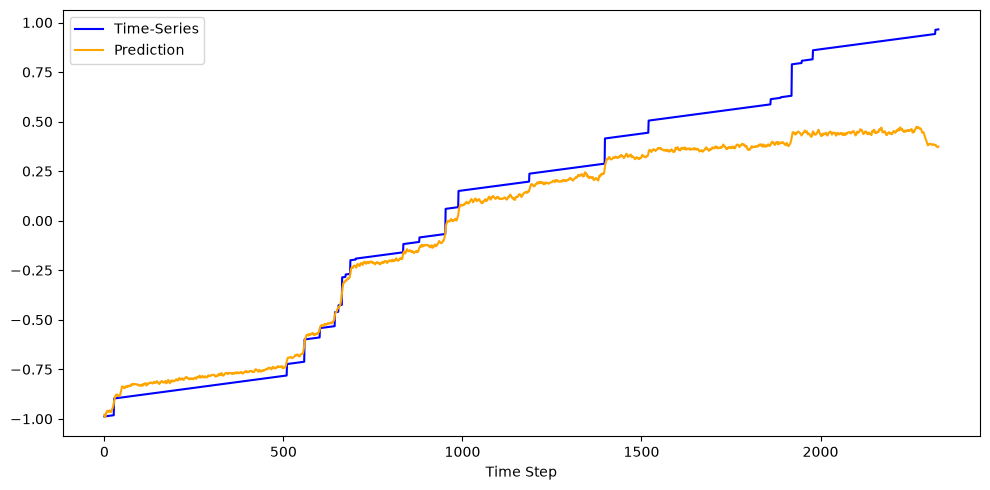

Channel T-4 Signal...
Epoch  25 | D Loss: 6.702048 | G Loss: -0.271867
Epoch  50 | D Loss: 2.975159 | G Loss: -0.242230
Epoch  75 | D Loss: -0.187272 | G Loss: 0.881438
Epoch 100 | D Loss: 1.948519 | G Loss: -0.915612
Epoch 125 | D Loss: 1.256255 | G Loss: -0.959776
Epoch 150 | D Loss: 1.189903 | G Loss: -1.236991
Epoch 175 | D Loss: 0.504745 | G Loss: -0.525270
Epoch 200 | D Loss: 0.329909 | G Loss: -0.344349
Epoch 225 | D Loss: 0.388079 | G Loss: -0.384038
Epoch 250 | D Loss: 0.426399 | G Loss: -0.483459
Epoch 275 | D Loss: 0.261593 | G Loss: -0.472633
Epoch 300 | D Loss: 0.304954 | G Loss: -0.424883
Epoch 325 | D Loss: 0.336098 | G Loss: -0.550932
Epoch 350 | D Loss: 0.275561 | G Loss: -0.376163
Epoch 375 | D Loss: 0.238539 | G Loss: -0.214676
Epoch 400 | D Loss: 0.264347 | G Loss: -0.283337
Epoch 425 | D Loss: 0.203817 | G Loss: -0.389895
Epoch 450 | D Loss: 0.280500 | G Loss: -0.360178
Epoch 475 | D Loss: -0.111797 | G Loss: -0.047013
Epoch 500 | D Loss: 0.113047 | G Loss: -0.2701

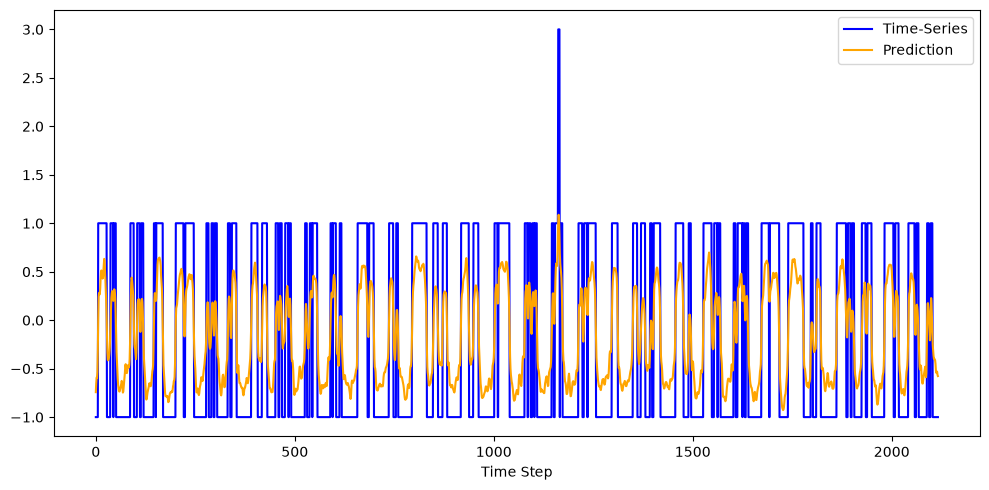

Channel T-5 Signal...
Epoch  25 | D Loss: 4.685721 | G Loss: -0.059290
Epoch  50 | D Loss: 2.440886 | G Loss: -0.593510
Epoch  75 | D Loss: 2.270695 | G Loss: -1.105683
Epoch 100 | D Loss: 0.640922 | G Loss: -0.348737
Epoch 125 | D Loss: 0.360960 | G Loss: -0.338417
Epoch 150 | D Loss: 0.264392 | G Loss: -0.212011
Epoch 175 | D Loss: 0.182415 | G Loss: -0.116671
Epoch 200 | D Loss: 0.236443 | G Loss: -0.299957
Epoch 225 | D Loss: 0.201953 | G Loss: -0.366584
Epoch 250 | D Loss: 0.254236 | G Loss: -0.440663
Epoch 275 | D Loss: 0.315218 | G Loss: -0.439355
Epoch 300 | D Loss: 0.303286 | G Loss: -0.414417
Epoch 325 | D Loss: 0.286611 | G Loss: -0.382512
Epoch 350 | D Loss: 0.281025 | G Loss: -0.361577
Epoch 375 | D Loss: 0.265671 | G Loss: -0.285833
Epoch 400 | D Loss: 0.284152 | G Loss: -0.353154
Epoch 425 | D Loss: 0.661940 | G Loss: -0.809619
Epoch 450 | D Loss: 0.427035 | G Loss: -0.438185
Epoch 475 | D Loss: 0.083704 | G Loss: -0.024646
Epoch 500 | D Loss: 0.211805 | G Loss: -0.43844

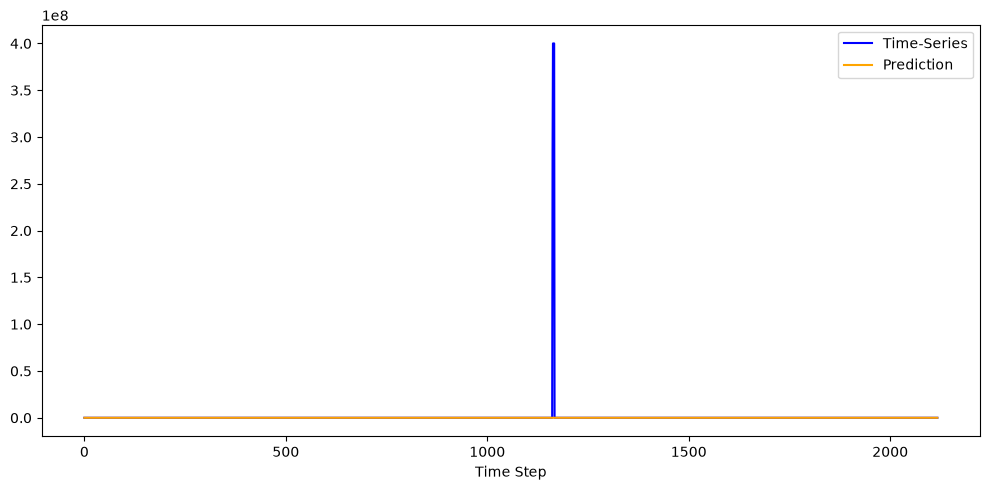

Channel T-8 Signal...
Epoch  25 | D Loss: 7.214992 | G Loss: 0.002421
Epoch  50 | D Loss: 5.934694 | G Loss: -0.002912
Epoch  75 | D Loss: 4.428672 | G Loss: -0.066703
Epoch 100 | D Loss: 2.779171 | G Loss: -0.336674
Epoch 125 | D Loss: 2.146925 | G Loss: -0.333400
Epoch 150 | D Loss: 0.944187 | G Loss: 0.624644
Epoch 175 | D Loss: 0.732222 | G Loss: 0.242926
Epoch 200 | D Loss: 0.291491 | G Loss: 0.011147
Epoch 225 | D Loss: -0.172300 | G Loss: -0.150640
Epoch 250 | D Loss: -0.265015 | G Loss: -0.538510
Epoch 275 | D Loss: 0.827399 | G Loss: -0.939798
Epoch 300 | D Loss: -0.218151 | G Loss: 0.881929
Epoch 325 | D Loss: -0.187077 | G Loss: 1.154026
Epoch 350 | D Loss: 0.788942 | G Loss: 0.127110
Epoch 375 | D Loss: 2.448246 | G Loss: -1.902842
Epoch 400 | D Loss: 3.263250 | G Loss: -2.909529
Epoch 425 | D Loss: 3.026869 | G Loss: -3.031488
Epoch 450 | D Loss: 2.693951 | G Loss: -3.013347
Epoch 475 | D Loss: 2.520008 | G Loss: -3.240270
Epoch 500 | D Loss: 8.409804 | G Loss: -7.983403
E

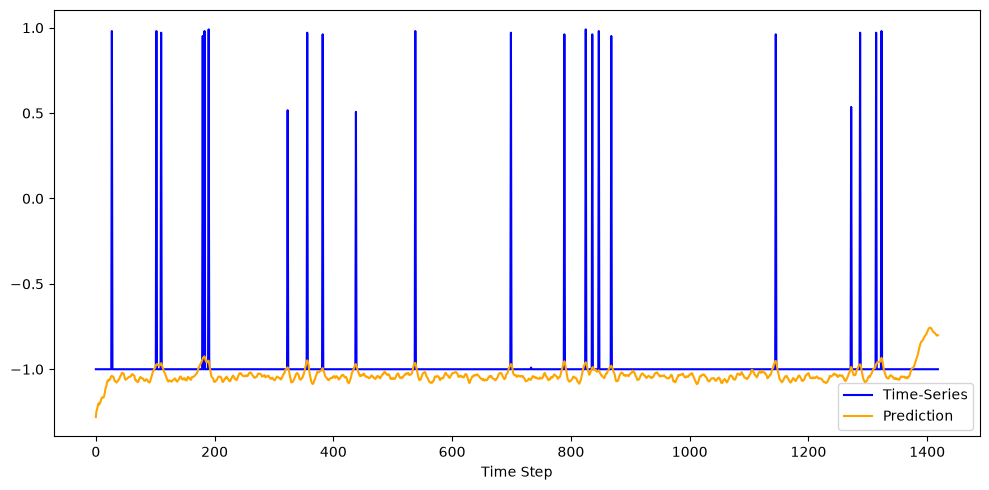

Channel T-9 Signal...
Epoch  25 | D Loss: 8.276563 | G Loss: 0.120931
Epoch  50 | D Loss: 7.662035 | G Loss: 0.109958
Epoch  75 | D Loss: 6.963878 | G Loss: 0.098579
Epoch 100 | D Loss: 6.273036 | G Loss: 0.091310
Epoch 125 | D Loss: 5.606729 | G Loss: 0.096331
Epoch 150 | D Loss: 4.941034 | G Loss: 0.108925
Epoch 175 | D Loss: 4.359868 | G Loss: 0.107563
Epoch 200 | D Loss: 3.722558 | G Loss: 0.098630
Epoch 225 | D Loss: 3.216684 | G Loss: 0.075488
Epoch 250 | D Loss: 3.180990 | G Loss: 0.040447
Epoch 275 | D Loss: 2.782115 | G Loss: 0.051346
Epoch 300 | D Loss: 2.287345 | G Loss: 0.075578
Epoch 325 | D Loss: 1.859639 | G Loss: 0.076757
Epoch 350 | D Loss: 1.252484 | G Loss: -0.052295
Epoch 375 | D Loss: 2.181584 | G Loss: -1.011810
Epoch 400 | D Loss: 2.208457 | G Loss: -1.173345
Epoch 425 | D Loss: 1.970673 | G Loss: -1.099112
Epoch 450 | D Loss: 1.705997 | G Loss: -0.991175
Epoch 475 | D Loss: 1.550368 | G Loss: -0.921991
Epoch 500 | D Loss: 1.256690 | G Loss: -0.721804
Epoch 525 |

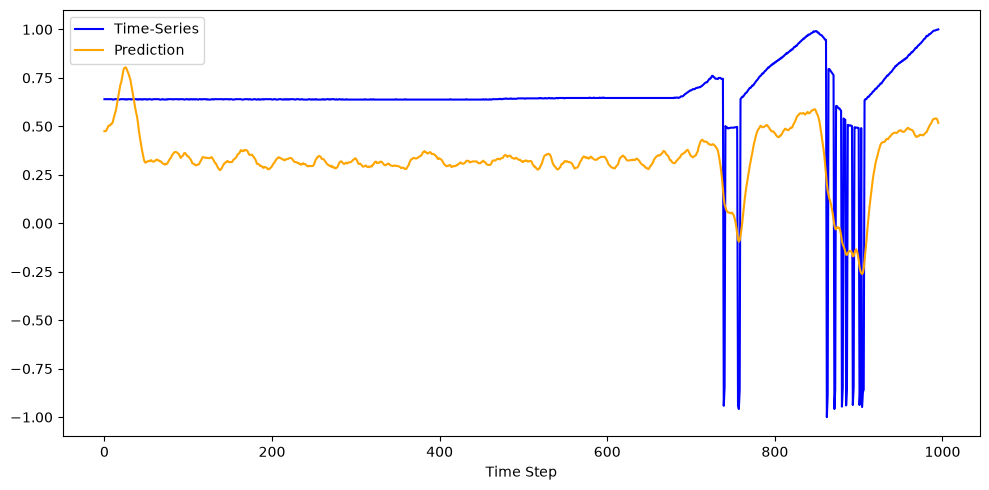

------------------
MSL Metrics
------------------
[point] Precision: 0.231 | Recall: 0.778 | F1: 0.347
[area] Precision: 0.226 | Recall: 0.802 | F1: 0.345


In [20]:
total_metrics = {name: np.zeros(3) for (name, _) in MSL_HYPERPARAMS["rec_error_funcs"]}
total_evaluated = 0

for msl_channel, X_train, X_test, y_test in zip(msl_channel_names, msl_train, msl_test, msl_test_y):
    # all data points are considered to be normal in the training tensor,
    # thus the labels consist of a tensor full of zeros
    y_train = torch.zeros(X_train.shape[0])

    print(f"Channel {msl_channel} Signal...")

    X_train = np.expand_dims(X_train[:, 0], axis=1)
    X_test = np.expand_dims(X_test[:, 0], axis=1)
    
    try:
        metrics = run_pipeline(
            X=X_train, y=y_train,
            X_test=X_test, y_test=y_test,
            **MSL_HYPERPARAMS
        )
        for key in total_metrics:
            total_metrics[key] += np.array(metrics[key])
        total_evaluated += 1
    except:
        continue

print("------------------")
print("MSL Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / total_evaluated
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")

### **SMAP**

In [21]:
SMAP_HYPERPARAMS = NASA_HYPERPARAMS.copy()
SMAP_HYPERPARAMS["verbose"] = False

In [22]:
smap_split_url = f"{NASA_SPLIT_REPO}{NASA_SMAP_SPLIT}"
smap_split = pd.read_csv(smap_split_url)

# extract the file names corresponding to the SMAP dataset
smap_channels_names = list(smap_split["chan_id"].values)
# add the .npy file extensions to the SMAP file names
smap_file_names = [f"{smap_file_name}.npy" for smap_file_name in smap_channels_names]
# sort them alphabetically
smap_file_names.sort()

In [23]:
smap_train: list[np.ndarray] = []
smap_test: list[np.ndarray] = []
smap_test_y: list[list] = []

for smap_file_name in smap_file_names:
    # load both the train and test time series for the same channel, concatenate
    # the time series and add them to the MSL dataset
    smap_train_ts = np.load(os.path.join(nasa_train_path, smap_file_name))
    smap_test_ts = np.load(os.path.join(nasa_test_path, smap_file_name))

    # extract the anomaly labels for the test time-series
    # -4 is needed to get rid of the file extension from the name
    row = nasa_labels[nasa_labels["chan_id"] == smap_file_name[:-4]]
    smap_test_interval_str = row["anomaly_sequences"].iloc[0]
    smap_test_interval = ast.literal_eval(smap_test_interval_str)
    smap_test_labels = intervals_to_points(smap_test_interval, len(smap_test_ts))

    smap_train.append(smap_train_ts)
    smap_test.append(smap_test_ts)

    smap_test_y.append(smap_test_labels)

Channel T-9 Signal...
Epoch  25 | D Loss: 4.893852 | G Loss: -0.558763
Epoch  50 | D Loss: 1.918738 | G Loss: 0.421535
Epoch  75 | D Loss: 0.776432 | G Loss: -0.654202
Epoch 100 | D Loss: 0.605360 | G Loss: -0.659319
Epoch 125 | D Loss: 0.228136 | G Loss: -0.288461
Epoch 150 | D Loss: 0.021173 | G Loss: -0.106934
Epoch 175 | D Loss: 0.029755 | G Loss: -0.156558
Epoch 200 | D Loss: 0.057479 | G Loss: -0.155175
Epoch 225 | D Loss: 0.091961 | G Loss: -0.086107
Epoch 250 | D Loss: 0.121091 | G Loss: -0.132239
Epoch 275 | D Loss: 0.090413 | G Loss: -0.203683
Epoch 300 | D Loss: 0.105541 | G Loss: -0.398333
Epoch 325 | D Loss: 0.090559 | G Loss: -0.625933
Epoch 350 | D Loss: 0.070051 | G Loss: -0.785884
Epoch 375 | D Loss: 0.031721 | G Loss: -1.086195
Epoch 400 | D Loss: 0.002562 | G Loss: -1.399465
Epoch 425 | D Loss: -0.011847 | G Loss: -1.572172
Epoch 450 | D Loss: -0.014064 | G Loss: -1.859986
Epoch 475 | D Loss: -0.015370 | G Loss: -2.166681
Epoch 500 | D Loss: -0.017450 | G Loss: -2.65

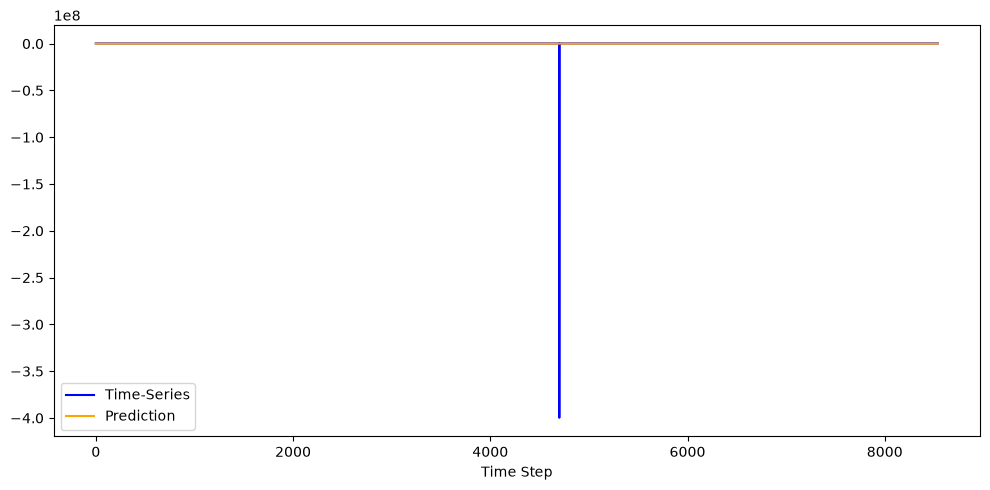

Channel T-9 Signal...
Epoch  25 | D Loss: 3.252825 | G Loss: -0.020524
Epoch  50 | D Loss: 1.375318 | G Loss: -0.466087
Epoch  75 | D Loss: 0.258597 | G Loss: -0.118064
Epoch 100 | D Loss: 0.313060 | G Loss: -0.256040
Epoch 125 | D Loss: 0.178027 | G Loss: -0.137167
Epoch 150 | D Loss: -0.020382 | G Loss: 0.091891
Epoch 175 | D Loss: -0.057768 | G Loss: 0.147269
Epoch 200 | D Loss: -0.018390 | G Loss: 0.063777
Epoch 225 | D Loss: -0.154278 | G Loss: 0.184355
Epoch 250 | D Loss: -0.169488 | G Loss: 0.231318
Epoch 275 | D Loss: -0.257592 | G Loss: 0.318632
Epoch 300 | D Loss: -0.155290 | G Loss: 0.210773
Epoch 325 | D Loss: 0.095006 | G Loss: -0.047746
Epoch 350 | D Loss: 0.084151 | G Loss: -0.050880
Epoch 375 | D Loss: 0.180027 | G Loss: -0.127424
Epoch 400 | D Loss: 0.283032 | G Loss: -0.250550
Epoch 425 | D Loss: 0.152060 | G Loss: -0.149410
Epoch 450 | D Loss: 0.059569 | G Loss: -0.021236
Epoch 475 | D Loss: 0.219948 | G Loss: -0.167886
Epoch 500 | D Loss: 0.784523 | G Loss: -0.77762

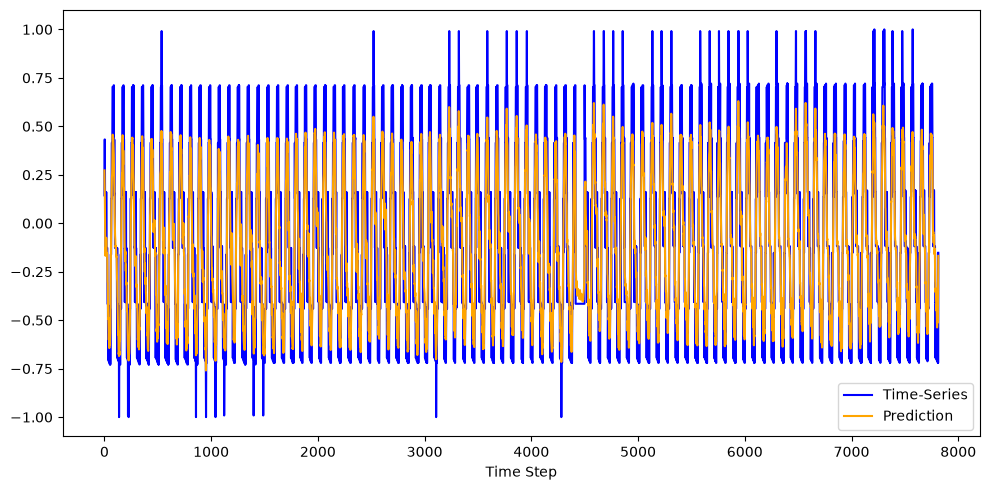

Channel T-9 Signal...
Epoch  25 | D Loss: 4.667287 | G Loss: 0.106908
Epoch  50 | D Loss: 1.216446 | G Loss: -0.325436
Epoch  75 | D Loss: -0.129137 | G Loss: 0.209720
Epoch 100 | D Loss: 0.010880 | G Loss: -0.179957
Epoch 125 | D Loss: -0.164206 | G Loss: 0.167760
Epoch 150 | D Loss: 3.426425 | G Loss: -3.869278
Epoch 175 | D Loss: 10.455751 | G Loss: -5.624526
Epoch 200 | D Loss: 4.576201 | G Loss: -0.145295
Epoch 225 | D Loss: 2.247213 | G Loss: -0.198473
Epoch 250 | D Loss: 0.850739 | G Loss: -0.441609
Epoch 275 | D Loss: 0.627773 | G Loss: -0.689031
Epoch 300 | D Loss: 0.497178 | G Loss: -0.573888
Epoch 325 | D Loss: 0.286822 | G Loss: -0.375950
Epoch 350 | D Loss: 0.035909 | G Loss: -0.128121
Epoch 375 | D Loss: -0.069762 | G Loss: 0.016903
Epoch 400 | D Loss: 0.088017 | G Loss: -0.083335
Epoch 425 | D Loss: 0.075654 | G Loss: -0.106590
Epoch 450 | D Loss: 0.134719 | G Loss: -0.316648
Epoch 475 | D Loss: 0.168449 | G Loss: -0.375016
Epoch 500 | D Loss: 0.172329 | G Loss: -0.29808

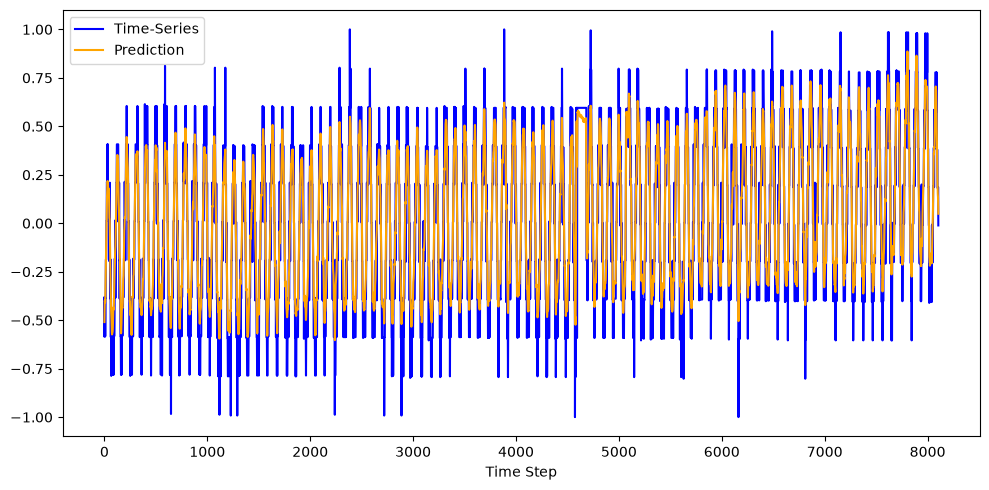

Channel T-9 Signal...
Epoch  25 | D Loss: 4.137653 | G Loss: 0.137768
Epoch  50 | D Loss: 1.106281 | G Loss: 0.092498
Epoch  75 | D Loss: 0.337722 | G Loss: -0.050664
Epoch 100 | D Loss: 0.481719 | G Loss: -0.418921
Epoch 125 | D Loss: 0.536172 | G Loss: -0.492628
Epoch 150 | D Loss: 0.153366 | G Loss: -0.055018
Epoch 175 | D Loss: 0.207542 | G Loss: -0.050296
Epoch 200 | D Loss: 0.369203 | G Loss: -0.209564
Epoch 225 | D Loss: 0.334942 | G Loss: -0.194508
Epoch 250 | D Loss: 0.276797 | G Loss: -0.154620
Epoch 275 | D Loss: 0.188091 | G Loss: -0.054865
Epoch 300 | D Loss: 0.121828 | G Loss: 0.057471
Epoch 325 | D Loss: 0.119341 | G Loss: 0.077131
Epoch 350 | D Loss: 0.150382 | G Loss: 0.029205
Epoch 375 | D Loss: 0.148465 | G Loss: 0.019751
Epoch 400 | D Loss: 0.166544 | G Loss: -0.029343
Epoch 425 | D Loss: 0.194561 | G Loss: -0.086295
Epoch 450 | D Loss: 0.172436 | G Loss: -0.059663
Epoch 475 | D Loss: 0.169103 | G Loss: -0.040212
Epoch 500 | D Loss: 0.169257 | G Loss: -0.044247
Epoc

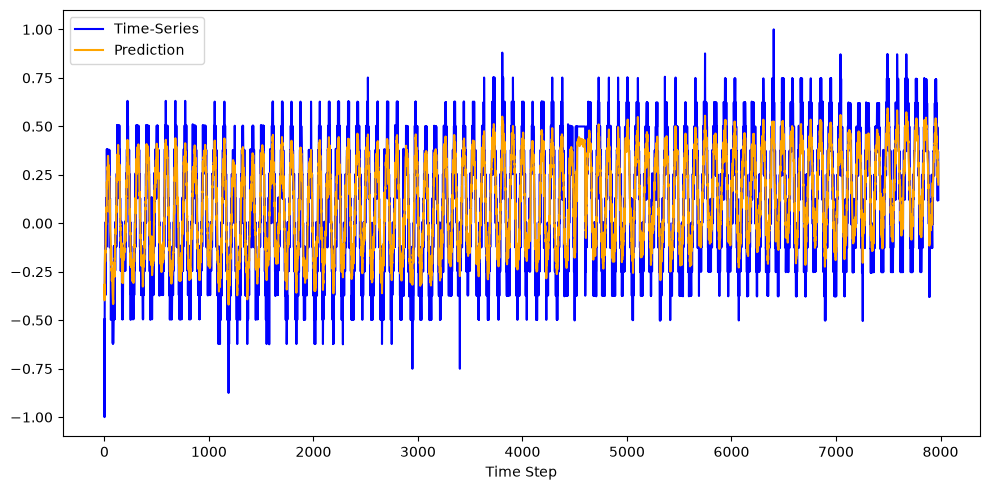

Channel T-9 Signal...
Epoch  25 | D Loss: 6.568934 | G Loss: 0.110242
Epoch  50 | D Loss: 6.237053 | G Loss: 0.092695
Epoch  75 | D Loss: 5.770113 | G Loss: 0.065128
Epoch 100 | D Loss: 4.757095 | G Loss: -0.049031
Epoch 125 | D Loss: 3.876355 | G Loss: -0.056012
Epoch 150 | D Loss: 2.956038 | G Loss: 0.077819
Epoch 175 | D Loss: 2.314295 | G Loss: 0.091399
Epoch 200 | D Loss: 2.256650 | G Loss: -0.505181
Epoch 225 | D Loss: 1.759102 | G Loss: -0.574683
Epoch 250 | D Loss: 1.226730 | G Loss: -0.397640
Epoch 275 | D Loss: 1.110973 | G Loss: -0.428930
Epoch 300 | D Loss: 1.146755 | G Loss: -0.559179
Epoch 325 | D Loss: 0.997318 | G Loss: -0.497500
Epoch 350 | D Loss: 0.802195 | G Loss: -0.416598
Epoch 375 | D Loss: 0.601146 | G Loss: -0.320812
Epoch 400 | D Loss: 0.444457 | G Loss: -0.218119
Epoch 425 | D Loss: 0.269224 | G Loss: -0.076084
Epoch 450 | D Loss: 0.048939 | G Loss: 0.145460
Epoch 475 | D Loss: -0.191149 | G Loss: 0.406723
Epoch 500 | D Loss: -0.360108 | G Loss: 0.619841
Epoc

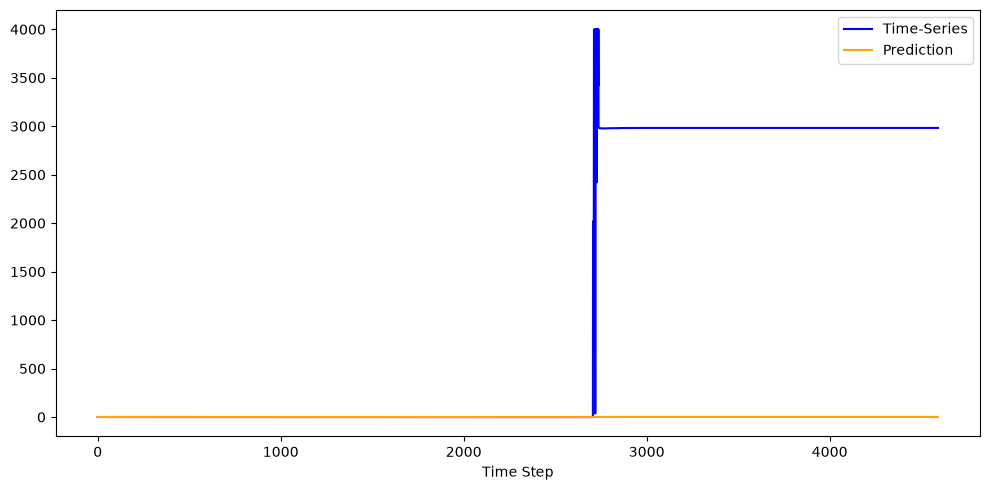

Channel T-9 Signal...
Epoch  25 | D Loss: 6.820295 | G Loss: -0.000332
Epoch  50 | D Loss: 5.744927 | G Loss: -0.024502
Epoch  75 | D Loss: 4.727537 | G Loss: -0.064056
Epoch 100 | D Loss: 4.045366 | G Loss: -0.187188
Epoch 125 | D Loss: 3.222561 | G Loss: -0.231960
Epoch 150 | D Loss: 2.300499 | G Loss: 0.100486
Epoch 175 | D Loss: 1.337062 | G Loss: 0.625637
Epoch 200 | D Loss: 0.806717 | G Loss: 0.841107
Epoch 225 | D Loss: 0.801132 | G Loss: 0.540963
Epoch 250 | D Loss: 0.802307 | G Loss: 0.143292
Epoch 275 | D Loss: 0.751951 | G Loss: -0.104460
Epoch 300 | D Loss: 0.652139 | G Loss: -0.298414
Epoch 325 | D Loss: 0.502157 | G Loss: -0.333047
Epoch 350 | D Loss: 0.411053 | G Loss: -0.365142
Epoch 375 | D Loss: 0.390765 | G Loss: -0.405692
Epoch 400 | D Loss: 0.387941 | G Loss: -0.425997
Epoch 425 | D Loss: 0.361444 | G Loss: -0.392592
Epoch 450 | D Loss: 0.333988 | G Loss: -0.349224
Epoch 475 | D Loss: 0.332869 | G Loss: -0.309205
Epoch 500 | D Loss: 0.265745 | G Loss: -0.213399
Epo

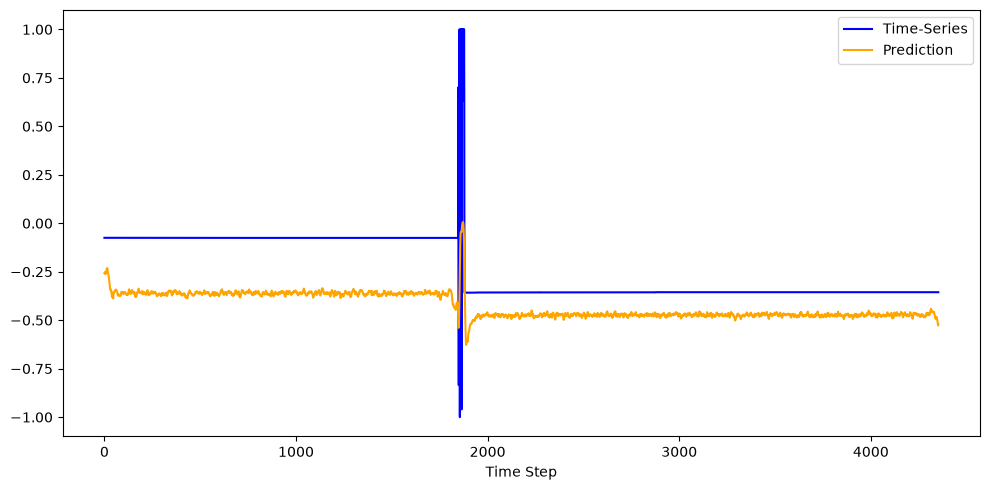

Channel T-9 Signal...
Epoch  25 | D Loss: 4.645838 | G Loss: -1.171375
Epoch  50 | D Loss: 7.018649 | G Loss: -3.779861
Epoch  75 | D Loss: 1.051773 | G Loss: 0.795652
Epoch 100 | D Loss: -5.017479 | G Loss: 5.508675
Epoch 125 | D Loss: -1.547136 | G Loss: 1.465343
Epoch 150 | D Loss: 2.211395 | G Loss: -2.669348
Epoch 175 | D Loss: 3.534358 | G Loss: -3.227235
Epoch 200 | D Loss: 1.421422 | G Loss: -1.202714
Epoch 225 | D Loss: 0.286756 | G Loss: -0.233576
Epoch 250 | D Loss: 0.061449 | G Loss: -0.063481
Epoch 275 | D Loss: 0.207495 | G Loss: -0.286461
Epoch 300 | D Loss: 0.127421 | G Loss: -0.141226
Epoch 325 | D Loss: 0.250385 | G Loss: -0.261712
Epoch 350 | D Loss: 0.214129 | G Loss: -0.241924
Epoch 375 | D Loss: 0.153801 | G Loss: -0.159070
Epoch 400 | D Loss: 0.211086 | G Loss: -0.219101
Epoch 425 | D Loss: 0.109808 | G Loss: -0.062606
Epoch 450 | D Loss: 0.153458 | G Loss: -0.120833
Epoch 475 | D Loss: 0.129659 | G Loss: -0.067297
Epoch 500 | D Loss: 0.094597 | G Loss: -0.030768

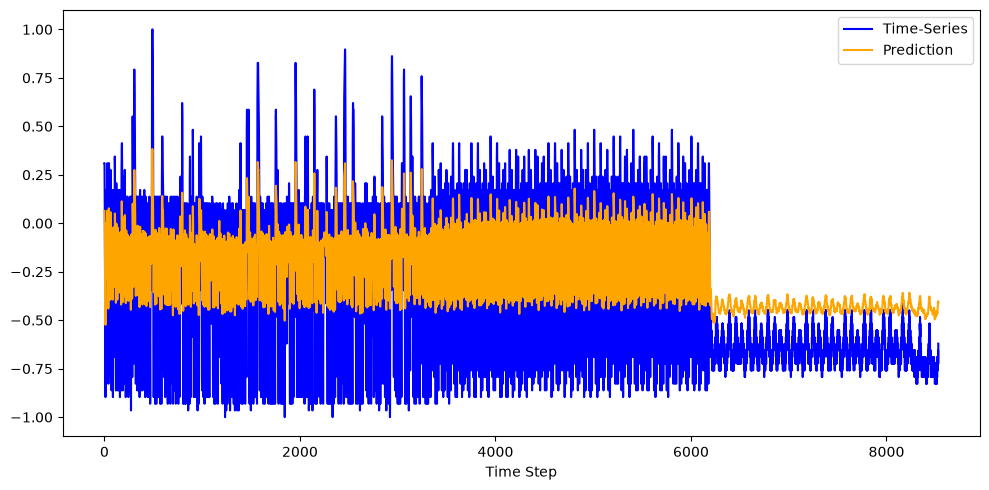

Channel T-9 Signal...
Epoch  25 | D Loss: 7.271649 | G Loss: 0.055177
Epoch  50 | D Loss: 6.165246 | G Loss: 0.052125
Epoch  75 | D Loss: 4.865482 | G Loss: 0.027155
Epoch 100 | D Loss: 3.642392 | G Loss: -0.073784
Epoch 125 | D Loss: 2.420931 | G Loss: -0.006809
Epoch 150 | D Loss: 1.436697 | G Loss: 0.109328
Epoch 175 | D Loss: 1.236514 | G Loss: -0.119938
Epoch 200 | D Loss: 0.823086 | G Loss: -0.186556
Epoch 225 | D Loss: 0.514509 | G Loss: -0.197356
Epoch 250 | D Loss: 0.312261 | G Loss: -0.114588
Epoch 275 | D Loss: 0.167825 | G Loss: -0.018989
Epoch 300 | D Loss: 0.161096 | G Loss: -0.038698
Epoch 325 | D Loss: 0.079559 | G Loss: 0.034054
Epoch 350 | D Loss: -0.091632 | G Loss: 0.203188
Epoch 375 | D Loss: 0.078709 | G Loss: 0.037253
Epoch 400 | D Loss: 0.114370 | G Loss: 0.017763
Epoch 425 | D Loss: 0.076415 | G Loss: 0.072947
Epoch 450 | D Loss: 0.289962 | G Loss: -0.149400
Epoch 475 | D Loss: 2.236034 | G Loss: -2.113551
Epoch 500 | D Loss: 2.952587 | G Loss: -2.753018
Epoch 

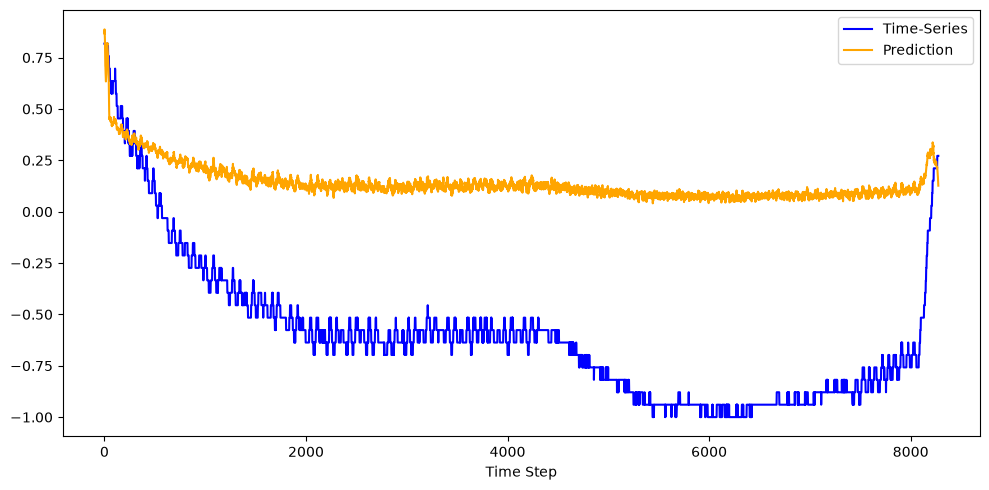

Channel T-9 Signal...
Epoch  25 | D Loss: 6.774686 | G Loss: 0.039261
Epoch  50 | D Loss: 5.901741 | G Loss: 0.029281
Epoch  75 | D Loss: 5.195824 | G Loss: 0.007685
Epoch 100 | D Loss: 4.387733 | G Loss: 0.105108
Epoch 125 | D Loss: 3.381606 | G Loss: 0.045472
Epoch 150 | D Loss: 2.866616 | G Loss: -0.073665
Epoch 175 | D Loss: 2.773258 | G Loss: -0.562030
Epoch 200 | D Loss: 2.549340 | G Loss: -0.864789
Epoch 225 | D Loss: 2.406063 | G Loss: -1.127955
Epoch 250 | D Loss: 2.439386 | G Loss: -1.474722
Epoch 275 | D Loss: 2.455111 | G Loss: -1.724797
Epoch 300 | D Loss: 1.989177 | G Loss: -1.424733
Epoch 325 | D Loss: 1.522662 | G Loss: -1.134874
Epoch 350 | D Loss: 1.133324 | G Loss: -0.881747
Epoch 375 | D Loss: 0.779921 | G Loss: -0.628283
Epoch 400 | D Loss: 0.520499 | G Loss: -0.433775
Epoch 425 | D Loss: 0.355864 | G Loss: -0.299241
Epoch 450 | D Loss: 0.258118 | G Loss: -0.211037
Epoch 475 | D Loss: 0.194926 | G Loss: -0.151268
Epoch 500 | D Loss: 0.150569 | G Loss: -0.104080
Epo

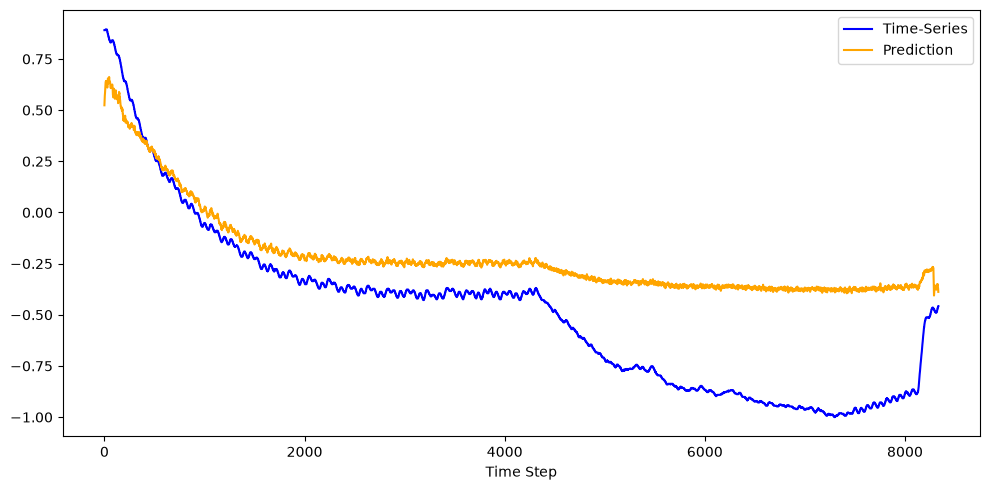

Channel T-9 Signal...
Epoch  25 | D Loss: 3.015640 | G Loss: -0.003549
Epoch  50 | D Loss: 1.546765 | G Loss: -0.249622
Epoch  75 | D Loss: 1.286959 | G Loss: -1.017653
Epoch 100 | D Loss: 1.025444 | G Loss: -0.893006
Epoch 125 | D Loss: 0.774177 | G Loss: -0.659018
Epoch 150 | D Loss: 0.625903 | G Loss: -0.494233
Epoch 175 | D Loss: 0.527897 | G Loss: -0.303415
Epoch 200 | D Loss: 0.387576 | G Loss: 0.062763
Epoch 225 | D Loss: 0.128529 | G Loss: 0.693295
Epoch 250 | D Loss: 0.251198 | G Loss: 0.618543
Epoch 275 | D Loss: 0.138709 | G Loss: 0.662216
Epoch 300 | D Loss: -0.084958 | G Loss: 1.122084
Epoch 325 | D Loss: -0.146249 | G Loss: 1.272192
Epoch 350 | D Loss: -0.133867 | G Loss: 1.459255
Epoch 375 | D Loss: -0.106135 | G Loss: 1.447328
Epoch 400 | D Loss: -0.104568 | G Loss: 1.483701
Epoch 425 | D Loss: -0.106885 | G Loss: 1.606405
Epoch 450 | D Loss: -0.110566 | G Loss: 1.824842
Epoch 475 | D Loss: -0.083703 | G Loss: 1.983349
Epoch 500 | D Loss: -0.060828 | G Loss: 2.048574
Ep

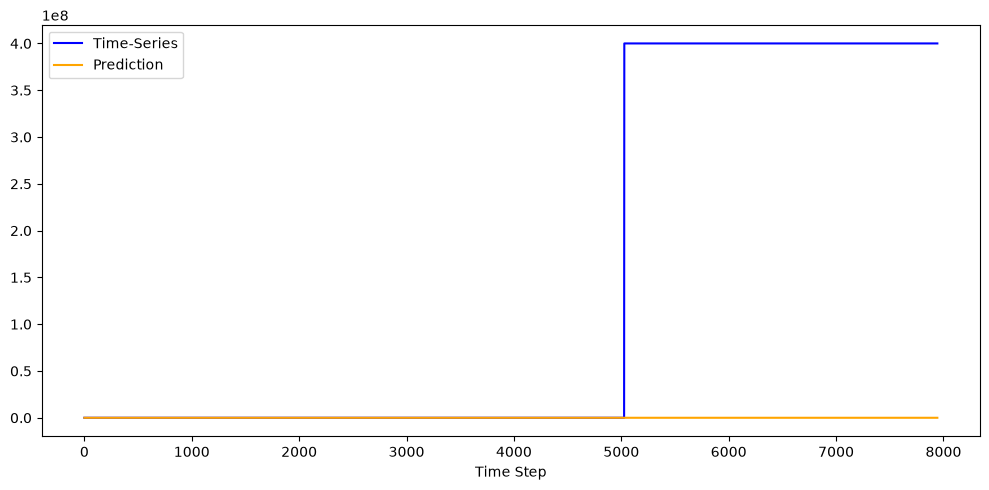

Channel T-9 Signal...
Epoch  25 | D Loss: 4.150479 | G Loss: -0.145275
Epoch  50 | D Loss: 2.360700 | G Loss: -0.546456
Epoch  75 | D Loss: 1.436326 | G Loss: -0.575688
Epoch 100 | D Loss: 3.611250 | G Loss: -3.545835
Epoch 125 | D Loss: 2.338810 | G Loss: -1.971546
Epoch 150 | D Loss: 1.145157 | G Loss: -0.925964
Epoch 175 | D Loss: 0.394533 | G Loss: -0.311708
Epoch 200 | D Loss: 0.161447 | G Loss: -0.272688
Epoch 225 | D Loss: -0.224805 | G Loss: -0.067368
Epoch 250 | D Loss: -0.078351 | G Loss: -0.266806
Epoch 275 | D Loss: 0.193035 | G Loss: -0.536612
Epoch 300 | D Loss: 0.323233 | G Loss: -0.712350
Epoch 325 | D Loss: 0.255607 | G Loss: -0.713030
Epoch 350 | D Loss: 0.116342 | G Loss: -0.571680
Epoch 375 | D Loss: 0.022615 | G Loss: -0.451474
Epoch 400 | D Loss: 0.071352 | G Loss: -0.434153
Epoch 425 | D Loss: 0.088230 | G Loss: -0.509501
Epoch 450 | D Loss: 0.095216 | G Loss: -0.505281
Epoch 475 | D Loss: 0.082196 | G Loss: -0.523261
Epoch 500 | D Loss: 0.067009 | G Loss: -0.498

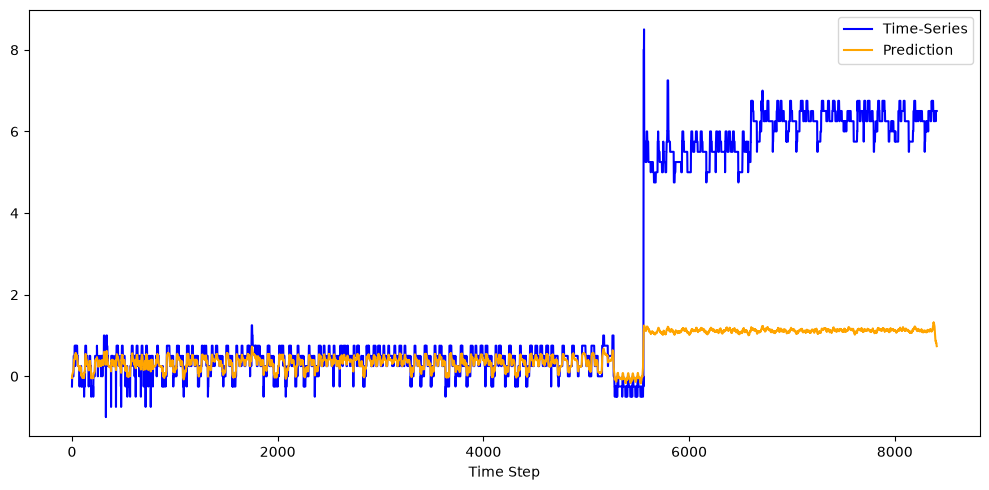

Channel T-9 Signal...
Epoch  25 | D Loss: 4.512478 | G Loss: -0.017500
Epoch  50 | D Loss: 0.904531 | G Loss: -0.091648
Epoch  75 | D Loss: 0.463365 | G Loss: -0.364356
Epoch 100 | D Loss: 0.233181 | G Loss: -0.238037
Epoch 125 | D Loss: 0.190302 | G Loss: -0.208603
Epoch 150 | D Loss: 0.121262 | G Loss: -0.126264
Epoch 175 | D Loss: 0.086753 | G Loss: -0.066460
Epoch 200 | D Loss: 0.032719 | G Loss: -0.014174
Epoch 225 | D Loss: 0.001189 | G Loss: -0.008930
Epoch 250 | D Loss: 0.008836 | G Loss: -0.049500
Epoch 275 | D Loss: -0.005414 | G Loss: -0.051094
Epoch 300 | D Loss: 0.008483 | G Loss: -0.096333
Epoch 325 | D Loss: 0.105461 | G Loss: -0.231697
Epoch 350 | D Loss: 0.074563 | G Loss: -0.259789
Epoch 375 | D Loss: 0.009154 | G Loss: -0.210036
Epoch 400 | D Loss: 0.095040 | G Loss: -0.145031
Epoch 425 | D Loss: 0.187121 | G Loss: -0.171072
Epoch 450 | D Loss: 0.092414 | G Loss: -0.096859
Epoch 475 | D Loss: 0.055673 | G Loss: 0.018492
Epoch 500 | D Loss: 0.019556 | G Loss: 0.058713

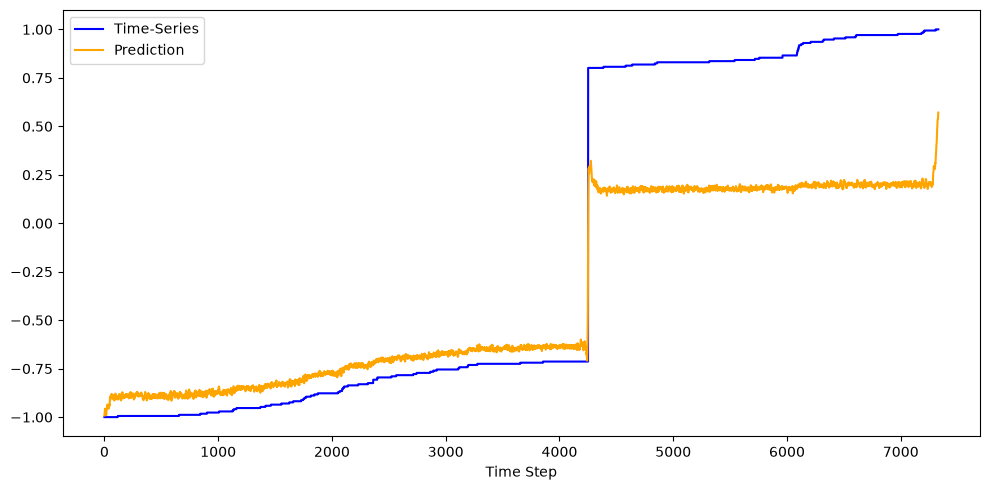

Channel T-9 Signal...
Epoch  25 | D Loss: 8.015800 | G Loss: -0.105046
Epoch  50 | D Loss: 7.646225 | G Loss: -0.099978
Epoch  75 | D Loss: 7.225141 | G Loss: -0.095392
Epoch 100 | D Loss: 6.775869 | G Loss: -0.090862
Epoch 125 | D Loss: 6.300722 | G Loss: -0.087011
Epoch 150 | D Loss: 5.838093 | G Loss: -0.083843
Epoch 175 | D Loss: 5.328809 | G Loss: -0.080261
Epoch 200 | D Loss: 4.876894 | G Loss: -0.077414
Epoch 225 | D Loss: 4.377128 | G Loss: -0.076128
Epoch 250 | D Loss: 3.980038 | G Loss: -0.076773
Epoch 275 | D Loss: 3.304556 | G Loss: -0.085739
Epoch 300 | D Loss: 2.954147 | G Loss: -0.098404
Epoch 325 | D Loss: 2.561038 | G Loss: -0.120463
Epoch 350 | D Loss: 2.362011 | G Loss: -0.138564
Epoch 375 | D Loss: 2.033309 | G Loss: -0.153429
Epoch 400 | D Loss: 1.644932 | G Loss: -0.159720
Epoch 425 | D Loss: 1.365240 | G Loss: -0.164807
Epoch 450 | D Loss: 1.053675 | G Loss: -0.164650
Epoch 475 | D Loss: 1.032822 | G Loss: -0.177582
Epoch 500 | D Loss: 0.854514 | G Loss: -0.19541

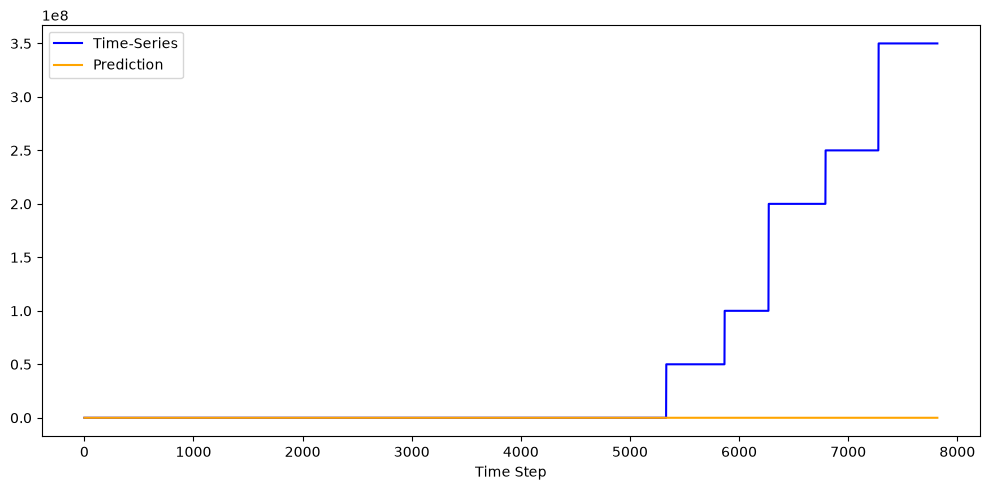

Channel T-9 Signal...
Epoch  25 | D Loss: 5.438797 | G Loss: -0.282522
Epoch  50 | D Loss: 2.934187 | G Loss: 0.532327
Epoch  75 | D Loss: 2.019296 | G Loss: 0.060889
Epoch 100 | D Loss: 1.627665 | G Loss: -1.213547
Epoch 125 | D Loss: 4.767736 | G Loss: -5.177919
Epoch 150 | D Loss: 5.204648 | G Loss: -5.138340
Epoch 175 | D Loss: 5.305866 | G Loss: -4.767946
Epoch 200 | D Loss: 5.097323 | G Loss: -4.312089
Epoch 225 | D Loss: 4.932189 | G Loss: -3.764256
Epoch 250 | D Loss: 5.402705 | G Loss: -4.003991
Epoch 275 | D Loss: 4.171936 | G Loss: -2.564594
Epoch 300 | D Loss: 1.723141 | G Loss: -0.578999
Epoch 325 | D Loss: 0.719344 | G Loss: -0.243451
Epoch 350 | D Loss: 0.472595 | G Loss: -0.370137
Epoch 375 | D Loss: 0.384679 | G Loss: -0.379904
Epoch 400 | D Loss: 0.357189 | G Loss: -0.364347
Epoch 425 | D Loss: 0.271433 | G Loss: -0.238213
Epoch 450 | D Loss: 0.041389 | G Loss: 0.184719
Epoch 475 | D Loss: -0.003180 | G Loss: 0.197336
Epoch 500 | D Loss: -0.161695 | G Loss: 0.354457
E

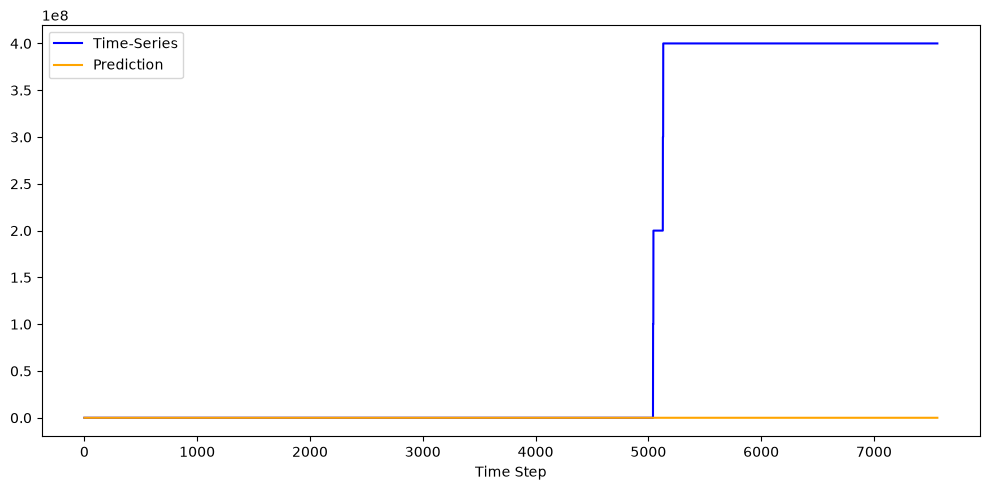

Channel T-9 Signal...
Epoch  25 | D Loss: 2.742914 | G Loss: 0.034748
Epoch  50 | D Loss: 0.433618 | G Loss: -0.028688
Epoch  75 | D Loss: 0.068620 | G Loss: 0.056589
Epoch 100 | D Loss: 0.066192 | G Loss: -0.022598
Epoch 125 | D Loss: -0.113068 | G Loss: 0.164446
Epoch 150 | D Loss: -0.064140 | G Loss: -0.013477
Epoch 175 | D Loss: -0.071888 | G Loss: -0.060703
Epoch 200 | D Loss: 0.017190 | G Loss: -0.256021
Epoch 225 | D Loss: -0.000752 | G Loss: -0.287611
Epoch 250 | D Loss: -0.029759 | G Loss: -0.279398
Epoch 275 | D Loss: -0.033665 | G Loss: -0.285646
Epoch 300 | D Loss: 0.004316 | G Loss: -0.317687
Epoch 325 | D Loss: 0.017901 | G Loss: -0.275166
Epoch 350 | D Loss: 0.017949 | G Loss: -0.370458
Epoch 375 | D Loss: 0.017884 | G Loss: -0.425121
Epoch 400 | D Loss: 0.013282 | G Loss: -0.484373
Epoch 425 | D Loss: 0.004141 | G Loss: -0.476744
Epoch 450 | D Loss: -0.002207 | G Loss: -0.493498
Epoch 475 | D Loss: -0.004686 | G Loss: -0.552765
Epoch 500 | D Loss: -0.005350 | G Loss: -0

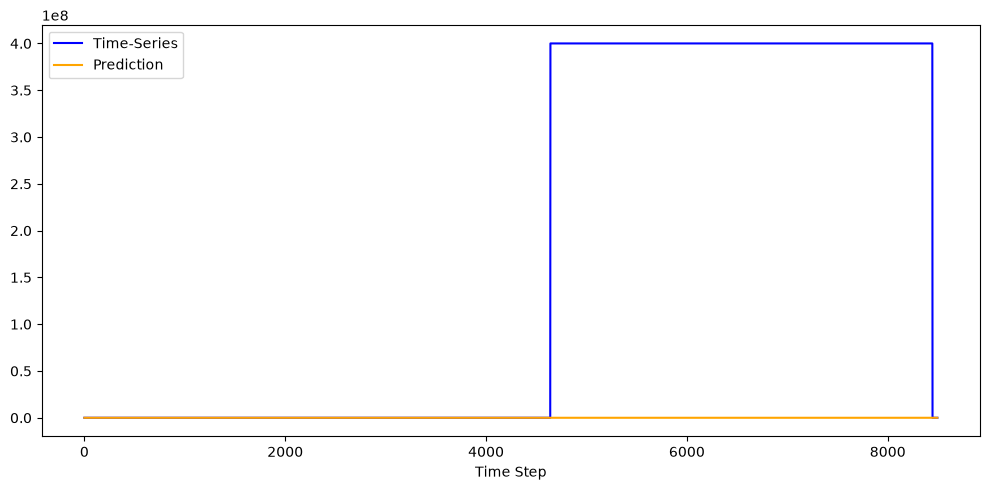

Channel T-9 Signal...
Epoch  25 | D Loss: 2.684102 | G Loss: 0.701340
Epoch  50 | D Loss: 1.271167 | G Loss: 0.038372
Epoch  75 | D Loss: -0.499305 | G Loss: 0.493188
Epoch 100 | D Loss: 1.470348 | G Loss: -1.326179
Epoch 125 | D Loss: 3.379063 | G Loss: -3.176622
Epoch 150 | D Loss: 1.206509 | G Loss: -0.853045
Epoch 175 | D Loss: 0.819552 | G Loss: -0.622860
Epoch 200 | D Loss: 0.297862 | G Loss: -0.078189
Epoch 225 | D Loss: 0.316074 | G Loss: 0.004790
Epoch 250 | D Loss: -0.011908 | G Loss: 0.597921
Epoch 275 | D Loss: 0.344936 | G Loss: 0.478097
Epoch 300 | D Loss: 0.195683 | G Loss: 0.516424
Epoch 325 | D Loss: 0.127435 | G Loss: 0.551897
Epoch 350 | D Loss: 0.135983 | G Loss: 0.557323
Epoch 375 | D Loss: 0.142668 | G Loss: 0.552081
Epoch 400 | D Loss: 0.134757 | G Loss: 0.565638
Epoch 425 | D Loss: 0.132355 | G Loss: 0.575855
Epoch 450 | D Loss: 0.145086 | G Loss: 0.696157
Epoch 475 | D Loss: 0.148226 | G Loss: 0.719818
Epoch 500 | D Loss: 0.115490 | G Loss: 0.791362
Epoch 525 |

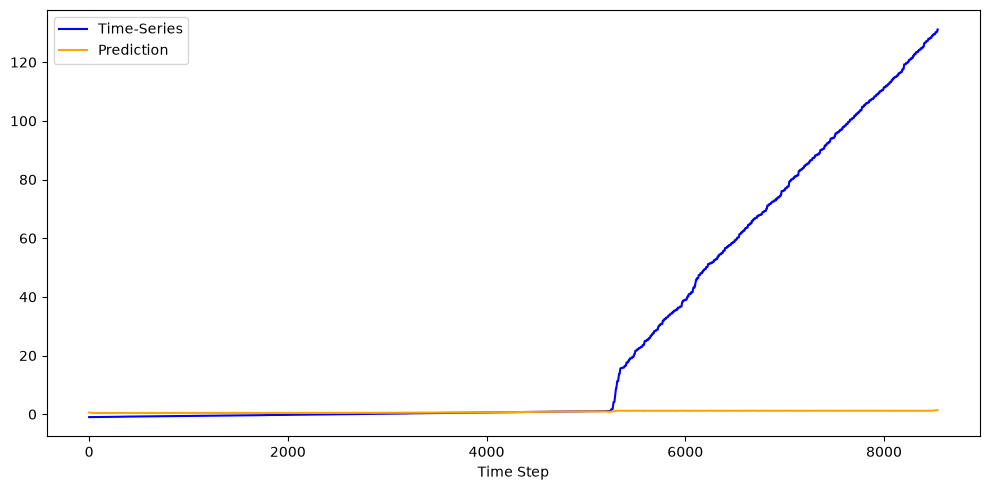

Channel T-9 Signal...
Epoch  25 | D Loss: 4.728812 | G Loss: -0.388788
Epoch  50 | D Loss: 1.976677 | G Loss: -0.322097
Epoch  75 | D Loss: 1.019949 | G Loss: -0.508341
Epoch 100 | D Loss: 0.140598 | G Loss: -0.056057
Epoch 125 | D Loss: 1.593053 | G Loss: -1.697212
Epoch 150 | D Loss: 0.961059 | G Loss: -1.016288
Epoch 175 | D Loss: 0.504375 | G Loss: -0.576254
Epoch 200 | D Loss: 0.635922 | G Loss: -0.719147
Epoch 225 | D Loss: 0.326948 | G Loss: -0.422557
Epoch 250 | D Loss: 0.193696 | G Loss: -0.300589
Epoch 275 | D Loss: 0.226650 | G Loss: -0.326695
Epoch 300 | D Loss: 0.246470 | G Loss: -0.333322
Epoch 325 | D Loss: 0.436876 | G Loss: -0.496394
Epoch 350 | D Loss: 0.458134 | G Loss: -0.516290
Epoch 375 | D Loss: 0.287864 | G Loss: -0.362945
Epoch 400 | D Loss: 0.197767 | G Loss: -0.272972
Epoch 425 | D Loss: 0.197575 | G Loss: -0.278781
Epoch 450 | D Loss: 0.138578 | G Loss: -0.210868
Epoch 475 | D Loss: 0.159074 | G Loss: -0.233160
Epoch 500 | D Loss: 0.138747 | G Loss: -0.21571

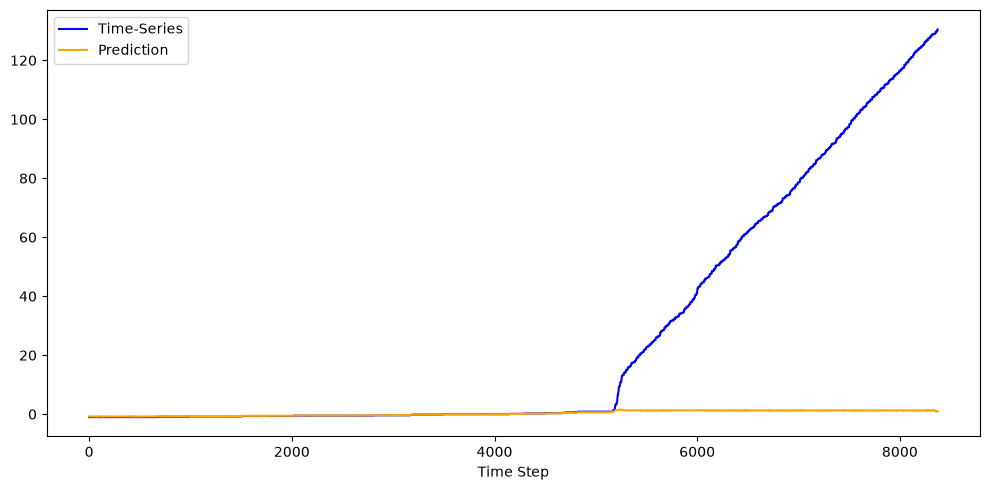

Channel T-9 Signal...
Epoch  25 | D Loss: 3.015371 | G Loss: -0.288570
Epoch  50 | D Loss: 0.305201 | G Loss: 0.077385
Epoch  75 | D Loss: 0.041422 | G Loss: -0.015375
Epoch 100 | D Loss: 0.016285 | G Loss: -0.006568
Epoch 125 | D Loss: 0.146811 | G Loss: -0.147666
Epoch 150 | D Loss: 0.062708 | G Loss: -0.106257
Epoch 175 | D Loss: 0.059515 | G Loss: -0.120094
Epoch 200 | D Loss: 0.044077 | G Loss: -0.140950
Epoch 225 | D Loss: 0.050656 | G Loss: -0.143750
Epoch 250 | D Loss: 0.533577 | G Loss: -0.435592
Epoch 275 | D Loss: -0.051909 | G Loss: -0.019612
Epoch 300 | D Loss: 0.044476 | G Loss: -0.162886
Epoch 325 | D Loss: 0.052055 | G Loss: -0.161573
Epoch 350 | D Loss: 0.055344 | G Loss: -0.165737
Epoch 375 | D Loss: 0.061960 | G Loss: -0.175144
Epoch 400 | D Loss: 0.102168 | G Loss: -0.222283
Epoch 425 | D Loss: 0.409459 | G Loss: -0.493039
Epoch 450 | D Loss: 0.349387 | G Loss: -0.402709
Epoch 475 | D Loss: 0.237932 | G Loss: -0.302322
Epoch 500 | D Loss: 0.164483 | G Loss: -0.23746

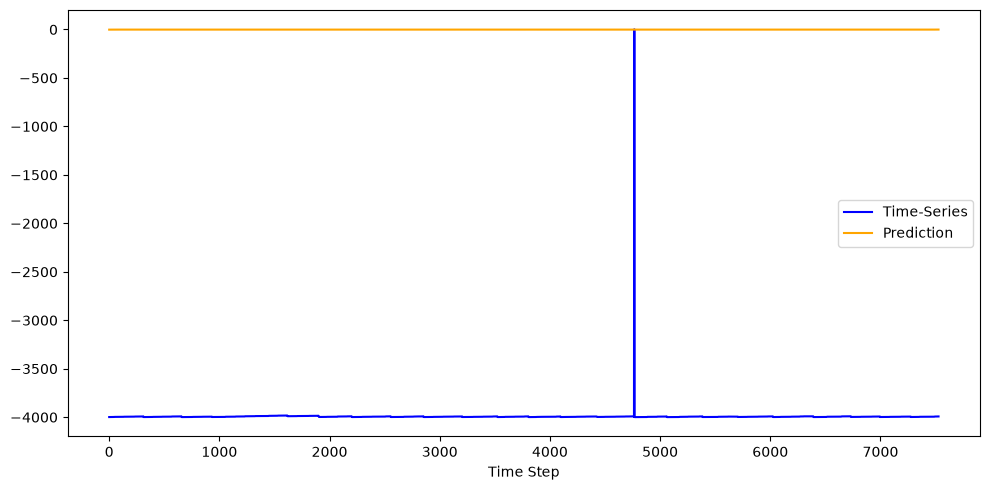

Channel T-9 Signal...
Epoch  25 | D Loss: 4.466450 | G Loss: -0.364914
Epoch  50 | D Loss: 5.619795 | G Loss: -3.007790
Epoch  75 | D Loss: 3.368465 | G Loss: -2.145218
Epoch 100 | D Loss: 5.297391 | G Loss: -4.144849
Epoch 125 | D Loss: 6.060006 | G Loss: -4.367903
Epoch 150 | D Loss: 3.995977 | G Loss: -2.523499
Epoch 175 | D Loss: 2.468638 | G Loss: -1.823271
Epoch 200 | D Loss: 1.238659 | G Loss: -1.395744
Epoch 225 | D Loss: 0.565703 | G Loss: -1.016666
Epoch 250 | D Loss: 0.427358 | G Loss: -0.917636
Epoch 275 | D Loss: 1.154408 | G Loss: -1.730250
Epoch 300 | D Loss: 0.750142 | G Loss: -1.441481
Epoch 325 | D Loss: 0.503105 | G Loss: -1.251247
Epoch 350 | D Loss: 0.314441 | G Loss: -1.151225
Epoch 375 | D Loss: 0.213116 | G Loss: -1.145553
Epoch 400 | D Loss: 0.162285 | G Loss: -1.175954
Epoch 425 | D Loss: 0.159996 | G Loss: -1.186218
Epoch 450 | D Loss: 0.121747 | G Loss: -1.170632
Epoch 475 | D Loss: 0.086839 | G Loss: -1.138462
Epoch 500 | D Loss: 0.065224 | G Loss: -1.16158

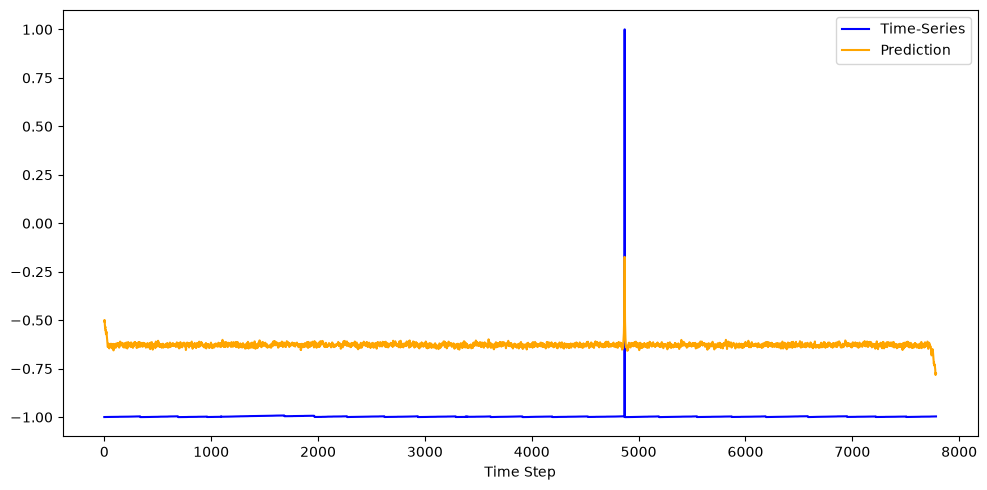

Channel T-9 Signal...
Epoch  25 | D Loss: 3.984523 | G Loss: -0.240500
Epoch  50 | D Loss: 1.395563 | G Loss: -0.038539
Epoch  75 | D Loss: 0.688094 | G Loss: -0.399915
Epoch 100 | D Loss: 0.219015 | G Loss: -0.224238
Epoch 125 | D Loss: 0.133590 | G Loss: -0.235395
Epoch 150 | D Loss: 0.100446 | G Loss: -0.201799
Epoch 175 | D Loss: 0.079639 | G Loss: -0.234612
Epoch 200 | D Loss: 0.057229 | G Loss: -0.245467
Epoch 225 | D Loss: 0.054519 | G Loss: -0.270427
Epoch 250 | D Loss: 0.051984 | G Loss: -0.305277
Epoch 275 | D Loss: 0.038794 | G Loss: -0.306009
Epoch 300 | D Loss: 0.021472 | G Loss: -0.374200
Epoch 325 | D Loss: 0.005465 | G Loss: -0.439602
Epoch 350 | D Loss: 0.002596 | G Loss: -0.427050
Epoch 375 | D Loss: 0.003023 | G Loss: -0.428078
Epoch 400 | D Loss: 0.001371 | G Loss: -0.496712
Epoch 425 | D Loss: -0.001225 | G Loss: -0.508746
Epoch 450 | D Loss: 0.000438 | G Loss: -0.414953
Epoch 475 | D Loss: -0.002971 | G Loss: -0.579264
Epoch 500 | D Loss: -0.004293 | G Loss: -0.64

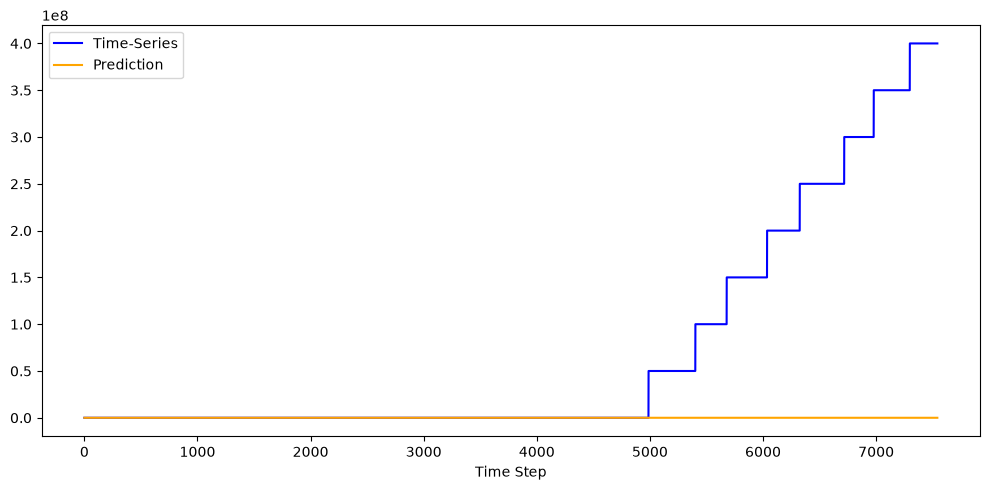

Channel T-9 Signal...
Epoch  25 | D Loss: 4.264690 | G Loss: -0.158956
Epoch  50 | D Loss: 0.941775 | G Loss: -0.143342
Epoch  75 | D Loss: 0.373738 | G Loss: -0.120174
Epoch 100 | D Loss: 0.177249 | G Loss: -0.078910
Epoch 125 | D Loss: 0.158790 | G Loss: -0.166528
Epoch 150 | D Loss: 0.099655 | G Loss: -0.221115
Epoch 175 | D Loss: 0.067177 | G Loss: -0.249570
Epoch 200 | D Loss: -0.000822 | G Loss: -0.298187
Epoch 225 | D Loss: 0.018176 | G Loss: -0.306712
Epoch 250 | D Loss: 0.019766 | G Loss: -0.346374
Epoch 275 | D Loss: 0.002788 | G Loss: -0.424008
Epoch 300 | D Loss: -0.005778 | G Loss: -0.551245
Epoch 325 | D Loss: -0.006959 | G Loss: -0.598730
Epoch 350 | D Loss: 0.006228 | G Loss: -0.722202
Epoch 375 | D Loss: 0.012581 | G Loss: -0.779770
Epoch 400 | D Loss: 0.014682 | G Loss: -0.877053
Epoch 425 | D Loss: 0.014263 | G Loss: -0.925604
Epoch 450 | D Loss: 0.015063 | G Loss: -0.894831
Epoch 475 | D Loss: 0.012467 | G Loss: -0.997583
Epoch 500 | D Loss: 0.008059 | G Loss: -1.17

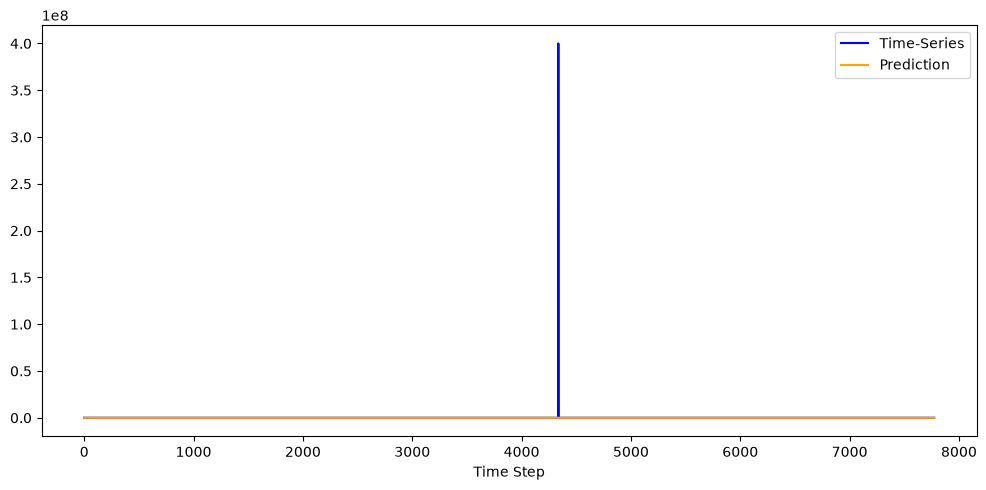

Channel T-9 Signal...
Epoch  25 | D Loss: 6.155545 | G Loss: -1.179083
Epoch  50 | D Loss: 0.917365 | G Loss: 2.009919
Epoch  75 | D Loss: 1.644315 | G Loss: -0.407466
Epoch 100 | D Loss: 1.087858 | G Loss: -0.788224
Epoch 125 | D Loss: 0.115071 | G Loss: -0.124399
Epoch 150 | D Loss: 0.196976 | G Loss: -0.262935
Epoch 175 | D Loss: 0.133757 | G Loss: -0.151179
Epoch 200 | D Loss: 0.094450 | G Loss: -0.099794
Epoch 225 | D Loss: 0.081917 | G Loss: -0.074124
Epoch 250 | D Loss: 0.118070 | G Loss: -0.065314
Epoch 275 | D Loss: 0.138073 | G Loss: -0.156174
Epoch 300 | D Loss: 0.131149 | G Loss: -0.413626
Epoch 325 | D Loss: 0.112229 | G Loss: -0.317649
Epoch 350 | D Loss: 0.070232 | G Loss: -0.307623
Epoch 375 | D Loss: 0.067346 | G Loss: -0.220138
Epoch 400 | D Loss: 0.051159 | G Loss: 0.035942
Epoch 425 | D Loss: 0.027882 | G Loss: 0.010033
Epoch 450 | D Loss: 0.003408 | G Loss: 0.081664
Epoch 475 | D Loss: -0.023781 | G Loss: 0.091931
Epoch 500 | D Loss: -0.042685 | G Loss: 0.091967
Ep

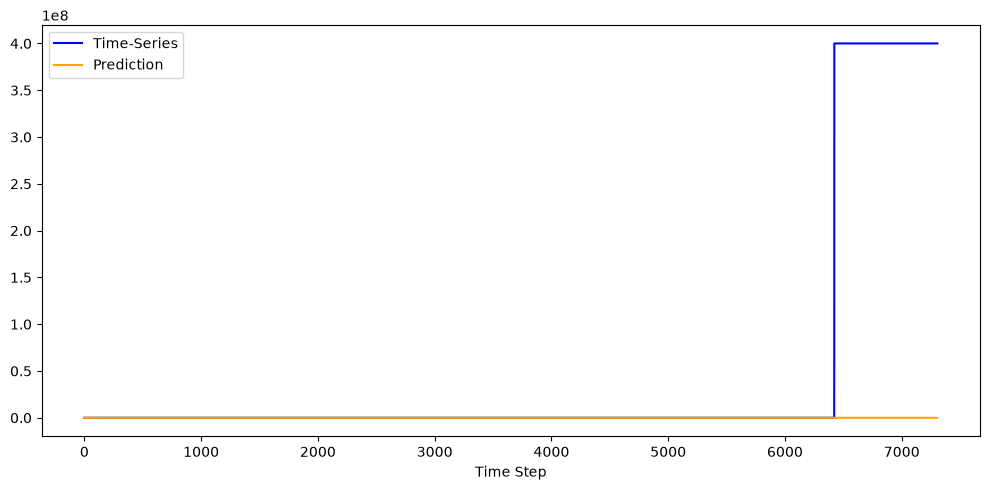

Channel T-9 Signal...
Epoch  25 | D Loss: 4.605120 | G Loss: -0.005710
Epoch  50 | D Loss: 2.412805 | G Loss: -0.981778
Epoch  75 | D Loss: 1.608159 | G Loss: -1.382284
Epoch 100 | D Loss: 1.851692 | G Loss: -1.652496
Epoch 125 | D Loss: 2.425290 | G Loss: -2.275931
Epoch 150 | D Loss: 0.868167 | G Loss: -0.700474
Epoch 175 | D Loss: 0.368542 | G Loss: -0.387176
Epoch 200 | D Loss: 0.191307 | G Loss: -0.198234
Epoch 225 | D Loss: -0.285813 | G Loss: 0.317222
Epoch 250 | D Loss: -0.027956 | G Loss: 0.296750
Epoch 275 | D Loss: 0.076324 | G Loss: 0.054663
Epoch 300 | D Loss: 0.003013 | G Loss: 0.319593
Epoch 325 | D Loss: -0.054039 | G Loss: 0.374146
Epoch 350 | D Loss: -0.072106 | G Loss: 0.280769
Epoch 375 | D Loss: -0.203265 | G Loss: 0.592085
Epoch 400 | D Loss: 0.004651 | G Loss: 0.310374
Epoch 425 | D Loss: 0.001314 | G Loss: 0.433630
Epoch 450 | D Loss: -0.211750 | G Loss: 0.649281
Epoch 475 | D Loss: 0.009753 | G Loss: 0.341515
Epoch 500 | D Loss: -0.250666 | G Loss: 0.781995
Epo

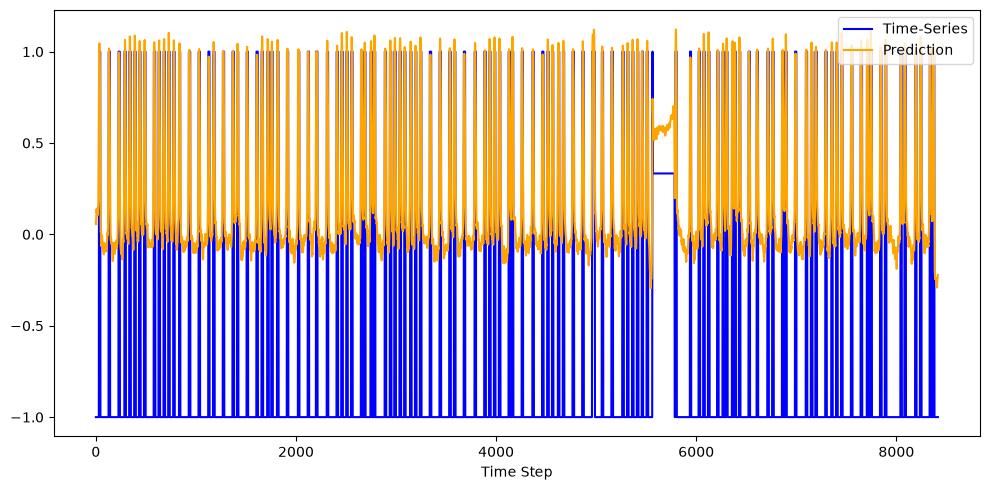

Channel T-9 Signal...
Epoch  25 | D Loss: 3.457295 | G Loss: -0.104605
Epoch  50 | D Loss: 0.893804 | G Loss: -0.055759
Epoch  75 | D Loss: -0.032720 | G Loss: -0.019487
Epoch 100 | D Loss: -0.468335 | G Loss: 0.008461
Epoch 125 | D Loss: -0.450034 | G Loss: 0.574601
Epoch 150 | D Loss: 0.035224 | G Loss: -0.127032
Epoch 175 | D Loss: 0.009986 | G Loss: -0.059318
Epoch 200 | D Loss: -0.018276 | G Loss: -0.016031
Epoch 225 | D Loss: -0.011592 | G Loss: -0.122121
Epoch 250 | D Loss: -0.005345 | G Loss: -0.060943
Epoch 275 | D Loss: -0.014262 | G Loss: -0.164482
Epoch 300 | D Loss: -0.025542 | G Loss: -0.093576
Epoch 325 | D Loss: -0.117165 | G Loss: -0.059069
Epoch 350 | D Loss: -0.140098 | G Loss: 0.219314
Epoch 375 | D Loss: -0.034126 | G Loss: -0.080380
Epoch 400 | D Loss: -0.160616 | G Loss: 0.347678
Epoch 425 | D Loss: 0.120369 | G Loss: -0.292781
Epoch 450 | D Loss: 0.041427 | G Loss: 0.065894
Epoch 475 | D Loss: 0.053104 | G Loss: 0.161800
Epoch 500 | D Loss: -0.993816 | G Loss: 0

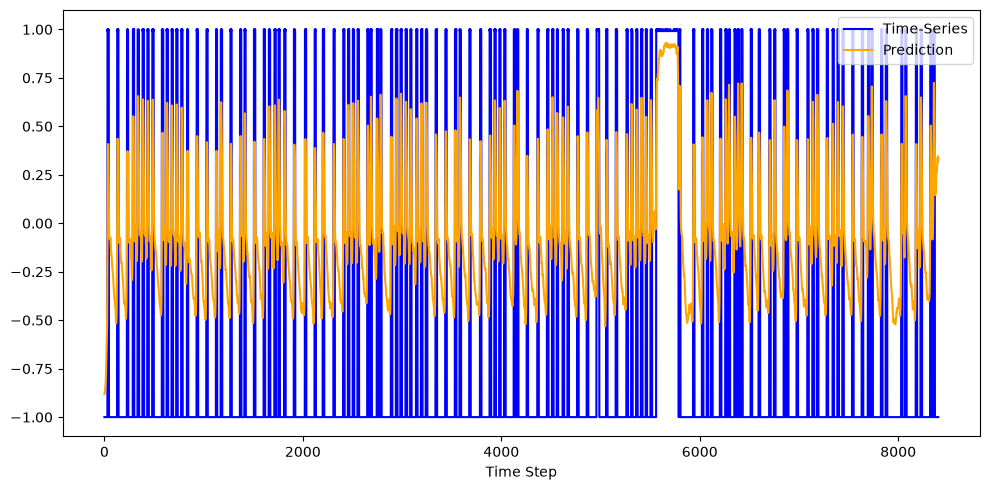

Channel T-9 Signal...
Epoch  25 | D Loss: 3.738515 | G Loss: -0.171301
Epoch  50 | D Loss: 2.209054 | G Loss: -0.895179
Epoch  75 | D Loss: 1.021933 | G Loss: -0.631279
Epoch 100 | D Loss: 0.403072 | G Loss: -0.379048
Epoch 125 | D Loss: -0.709133 | G Loss: 0.782762
Epoch 150 | D Loss: 2.169124 | G Loss: -2.028991
Epoch 175 | D Loss: 0.962255 | G Loss: -0.970526
Epoch 200 | D Loss: 0.595921 | G Loss: -0.641391
Epoch 225 | D Loss: 0.508065 | G Loss: -0.583565
Epoch 250 | D Loss: 0.335394 | G Loss: -0.449723
Epoch 275 | D Loss: 0.178896 | G Loss: -0.322240
Epoch 300 | D Loss: 0.186272 | G Loss: -0.346858
Epoch 325 | D Loss: 0.145781 | G Loss: -0.267159
Epoch 350 | D Loss: 0.159588 | G Loss: -0.271188
Epoch 375 | D Loss: 0.146766 | G Loss: -0.242939
Epoch 400 | D Loss: 0.115772 | G Loss: -0.216365
Epoch 425 | D Loss: 0.149536 | G Loss: -0.299359
Epoch 450 | D Loss: 0.141559 | G Loss: -0.478388
Epoch 475 | D Loss: 0.146213 | G Loss: -0.282227
Epoch 500 | D Loss: 0.117795 | G Loss: -0.28593

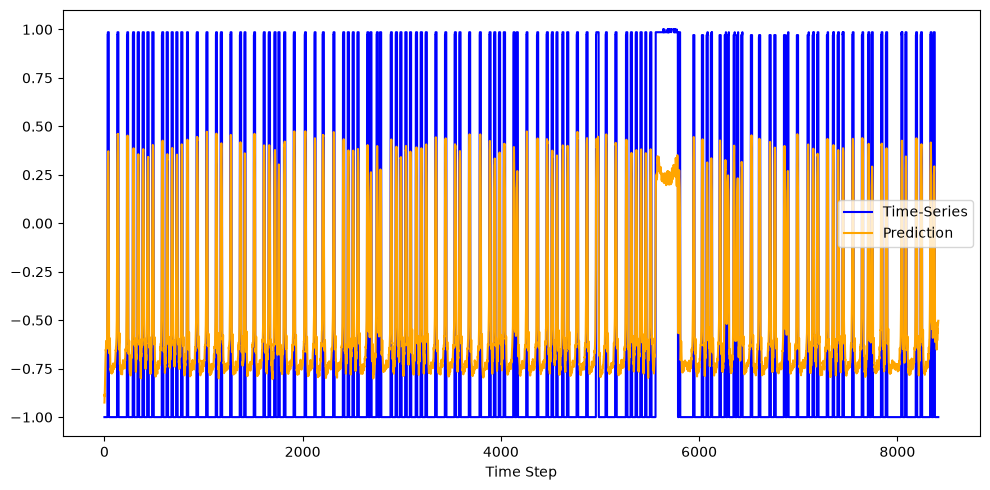

Channel T-9 Signal...
Epoch  25 | D Loss: 4.527247 | G Loss: 0.069860
Epoch  50 | D Loss: 1.394994 | G Loss: 0.031305
Epoch  75 | D Loss: 0.218232 | G Loss: -0.023615
Epoch 100 | D Loss: 0.066049 | G Loss: 0.058301
Epoch 125 | D Loss: 0.588626 | G Loss: -0.520181
Epoch 150 | D Loss: 0.174829 | G Loss: -0.062157
Epoch 175 | D Loss: 0.254018 | G Loss: -0.162670
Epoch 200 | D Loss: 0.143199 | G Loss: 0.004479
Epoch 225 | D Loss: 0.010126 | G Loss: 0.433245
Epoch 250 | D Loss: 0.083537 | G Loss: 0.176152
Epoch 275 | D Loss: -0.003155 | G Loss: -0.113882
Epoch 300 | D Loss: 0.043064 | G Loss: 0.031108
Epoch 325 | D Loss: -0.096055 | G Loss: -0.071616
Epoch 350 | D Loss: -0.126161 | G Loss: 0.355347
Epoch 375 | D Loss: -0.097530 | G Loss: 0.199640
Epoch 400 | D Loss: 0.021804 | G Loss: 0.290897
Epoch 425 | D Loss: -0.015217 | G Loss: 0.223246
Epoch 450 | D Loss: -0.077493 | G Loss: 0.400163
Epoch 475 | D Loss: -0.053008 | G Loss: 0.269349
Epoch 500 | D Loss: -0.201896 | G Loss: 0.500228
Epoc

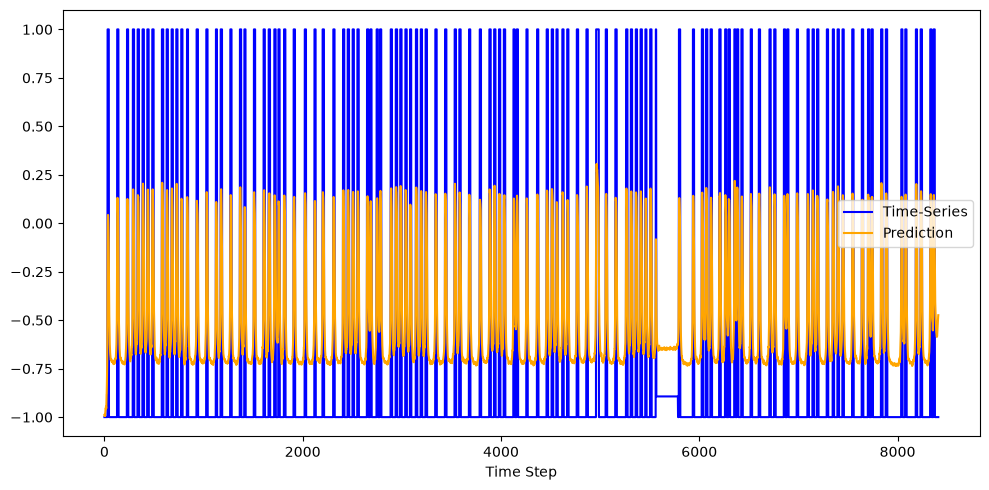

Channel T-9 Signal...
Epoch  25 | D Loss: 3.584639 | G Loss: -0.032890
Epoch  50 | D Loss: 1.172979 | G Loss: -0.274204
Epoch  75 | D Loss: 0.170727 | G Loss: -0.040045
Epoch 100 | D Loss: 0.119822 | G Loss: -0.024076
Epoch 125 | D Loss: -0.021429 | G Loss: 0.060438
Epoch 150 | D Loss: -0.007170 | G Loss: 0.029188
Epoch 175 | D Loss: 0.139375 | G Loss: -0.141717
Epoch 200 | D Loss: 0.294394 | G Loss: -0.424308
Epoch 225 | D Loss: -0.010376 | G Loss: -0.034548
Epoch 250 | D Loss: -0.073535 | G Loss: 0.036877
Epoch 275 | D Loss: -0.028765 | G Loss: -0.047697
Epoch 300 | D Loss: -0.204590 | G Loss: -0.109447
Epoch 325 | D Loss: -0.280849 | G Loss: 0.199123
Epoch 350 | D Loss: -0.655489 | G Loss: 0.330040
Epoch 375 | D Loss: 0.056886 | G Loss: -0.256955
Epoch 400 | D Loss: 0.197405 | G Loss: -0.376183
Epoch 425 | D Loss: 0.161161 | G Loss: -0.391975
Epoch 450 | D Loss: 0.207863 | G Loss: -0.568137
Epoch 475 | D Loss: 0.116580 | G Loss: -0.370898
Epoch 500 | D Loss: 0.033062 | G Loss: -0.39

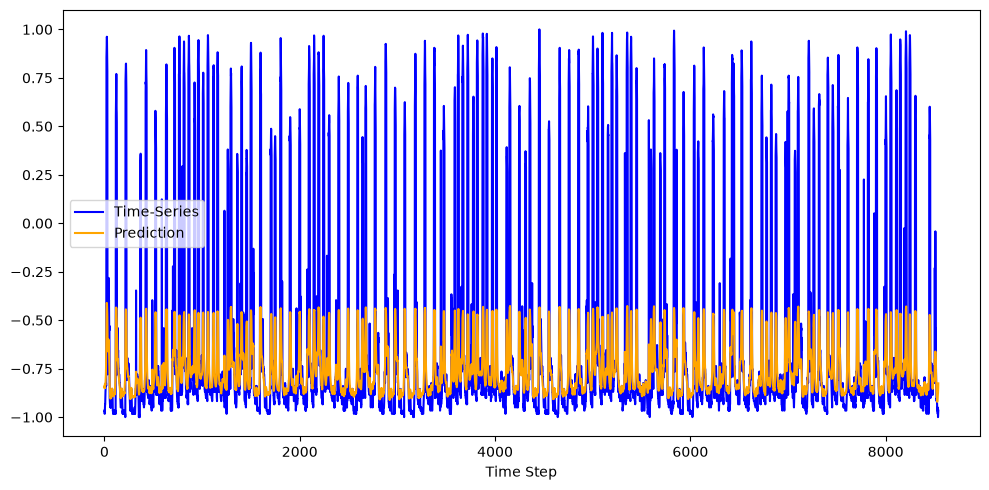

Channel T-9 Signal...
Epoch  25 | D Loss: 3.509929 | G Loss: -0.104452
Epoch  50 | D Loss: 2.993635 | G Loss: -2.270414
Epoch  75 | D Loss: 3.955871 | G Loss: -3.331767
Epoch 100 | D Loss: 2.233772 | G Loss: -1.944188
Epoch 125 | D Loss: 1.491104 | G Loss: -1.365635
Epoch 150 | D Loss: 1.340969 | G Loss: -1.208030
Epoch 175 | D Loss: 1.764184 | G Loss: -1.711671
Epoch 200 | D Loss: 0.410716 | G Loss: -0.329843
Epoch 225 | D Loss: 0.017031 | G Loss: -0.129107
Epoch 250 | D Loss: 2.248786 | G Loss: -2.290854
Epoch 275 | D Loss: 1.095306 | G Loss: -1.059486
Epoch 300 | D Loss: 1.481757 | G Loss: -1.140507
Epoch 325 | D Loss: 0.783377 | G Loss: -0.490920
Epoch 350 | D Loss: 0.452615 | G Loss: 0.021738
Epoch 375 | D Loss: -0.188783 | G Loss: 1.196960
Epoch 400 | D Loss: 0.230626 | G Loss: 0.944371
Epoch 425 | D Loss: 0.206736 | G Loss: 0.732782
Epoch 450 | D Loss: 0.154424 | G Loss: 0.641466
Epoch 475 | D Loss: 0.129871 | G Loss: 0.581389
Epoch 500 | D Loss: 0.129973 | G Loss: 0.577644
Epoc

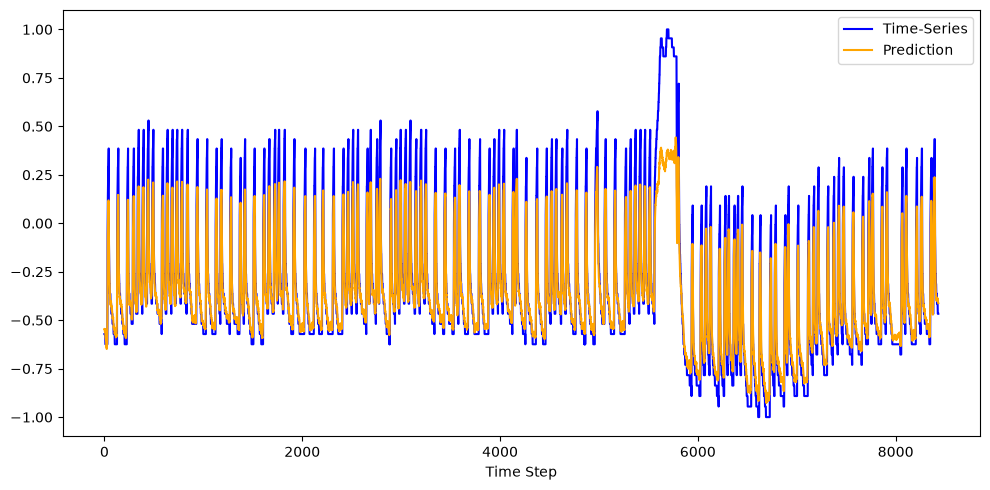

Channel T-9 Signal...
Epoch  25 | D Loss: 3.592687 | G Loss: -0.098186
Epoch  50 | D Loss: 1.464100 | G Loss: -0.189383
Epoch  75 | D Loss: 0.419803 | G Loss: -0.275293
Epoch 100 | D Loss: 0.300638 | G Loss: -0.298438
Epoch 125 | D Loss: 0.140404 | G Loss: -0.199445
Epoch 150 | D Loss: 0.127870 | G Loss: -0.167281
Epoch 175 | D Loss: 0.049628 | G Loss: -0.043716
Epoch 200 | D Loss: 0.034046 | G Loss: -0.001574
Epoch 225 | D Loss: 0.076512 | G Loss: -0.078966
Epoch 250 | D Loss: 0.083918 | G Loss: -0.166290
Epoch 275 | D Loss: 0.120253 | G Loss: -0.202597
Epoch 300 | D Loss: 0.152490 | G Loss: -0.245713
Epoch 325 | D Loss: 0.138329 | G Loss: -0.267399
Epoch 350 | D Loss: 0.108566 | G Loss: -0.188376
Epoch 375 | D Loss: 0.125106 | G Loss: -0.071915
Epoch 400 | D Loss: 0.122821 | G Loss: -0.082937
Epoch 425 | D Loss: 0.097256 | G Loss: -0.125734
Epoch 450 | D Loss: 0.073182 | G Loss: -0.132487
Epoch 475 | D Loss: 0.102478 | G Loss: -0.144060
Epoch 500 | D Loss: 0.121569 | G Loss: -0.13575

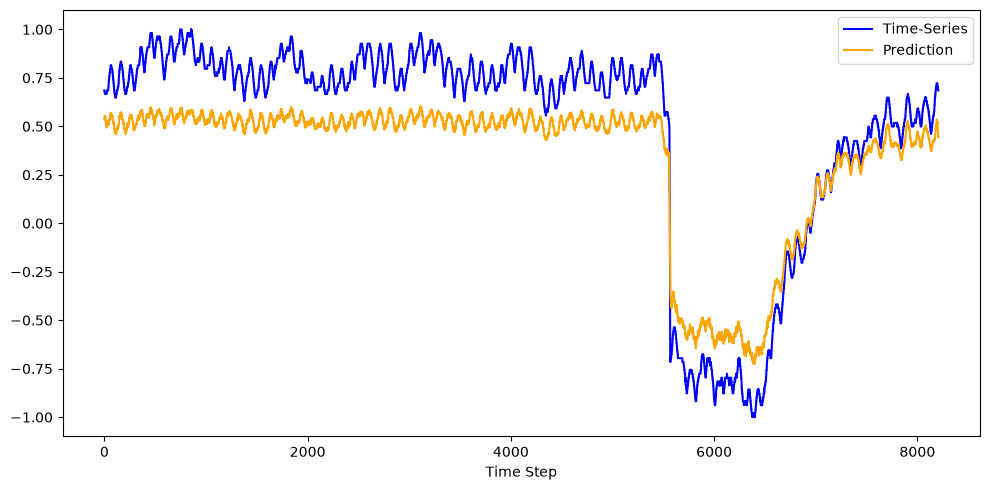

Channel T-9 Signal...
Epoch  25 | D Loss: 4.133330 | G Loss: 0.043666
Epoch  50 | D Loss: 0.603516 | G Loss: 0.214052
Epoch  75 | D Loss: 0.596682 | G Loss: -0.161057
Epoch 100 | D Loss: -0.016042 | G Loss: -0.479967
Epoch 125 | D Loss: 0.296332 | G Loss: -0.350256
Epoch 150 | D Loss: -0.433372 | G Loss: 0.399781
Epoch 175 | D Loss: 0.993392 | G Loss: -1.033873
Epoch 200 | D Loss: 0.495714 | G Loss: -0.556156
Epoch 225 | D Loss: 0.453916 | G Loss: -0.521207
Epoch 250 | D Loss: 0.341682 | G Loss: -0.449748
Epoch 275 | D Loss: 0.543247 | G Loss: -0.645857
Epoch 300 | D Loss: 0.342923 | G Loss: -0.442001
Epoch 325 | D Loss: 0.290906 | G Loss: -0.374045
Epoch 350 | D Loss: 0.162211 | G Loss: -0.240233
Epoch 375 | D Loss: 0.142851 | G Loss: -0.208357
Epoch 400 | D Loss: -0.001917 | G Loss: -0.050295
Epoch 425 | D Loss: 0.109439 | G Loss: -0.182888
Epoch 450 | D Loss: 0.112251 | G Loss: -0.190996
Epoch 475 | D Loss: 0.099464 | G Loss: -0.169301
Epoch 500 | D Loss: 0.072994 | G Loss: -0.15319

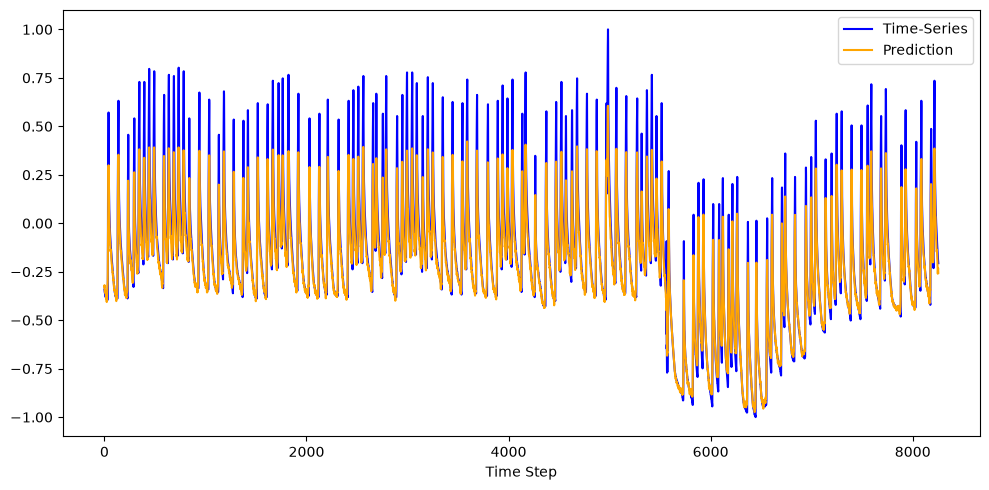

Channel T-9 Signal...
Epoch  25 | D Loss: 4.769235 | G Loss: -0.180857
Epoch  50 | D Loss: 2.297278 | G Loss: -0.921452
Epoch  75 | D Loss: 0.908816 | G Loss: -0.775213
Epoch 100 | D Loss: 0.567215 | G Loss: -0.680642
Epoch 125 | D Loss: -0.855214 | G Loss: 0.725481
Epoch 150 | D Loss: 1.260021 | G Loss: -1.623325
Epoch 175 | D Loss: 1.336830 | G Loss: -1.439078
Epoch 200 | D Loss: 0.879111 | G Loss: -0.940573
Epoch 225 | D Loss: 1.104329 | G Loss: -1.341302
Epoch 250 | D Loss: 0.806368 | G Loss: -0.945559
Epoch 275 | D Loss: 0.440124 | G Loss: -0.556393
Epoch 300 | D Loss: 0.339601 | G Loss: -0.435108
Epoch 325 | D Loss: 0.138419 | G Loss: -0.206268
Epoch 350 | D Loss: 0.067483 | G Loss: -0.131608
Epoch 375 | D Loss: 0.085587 | G Loss: -0.181630
Epoch 400 | D Loss: 0.057702 | G Loss: -0.230674
Epoch 425 | D Loss: 0.040221 | G Loss: -0.202626
Epoch 450 | D Loss: 0.109411 | G Loss: -0.339342
Epoch 475 | D Loss: 0.063313 | G Loss: -0.342564
Epoch 500 | D Loss: 0.012893 | G Loss: -0.29190

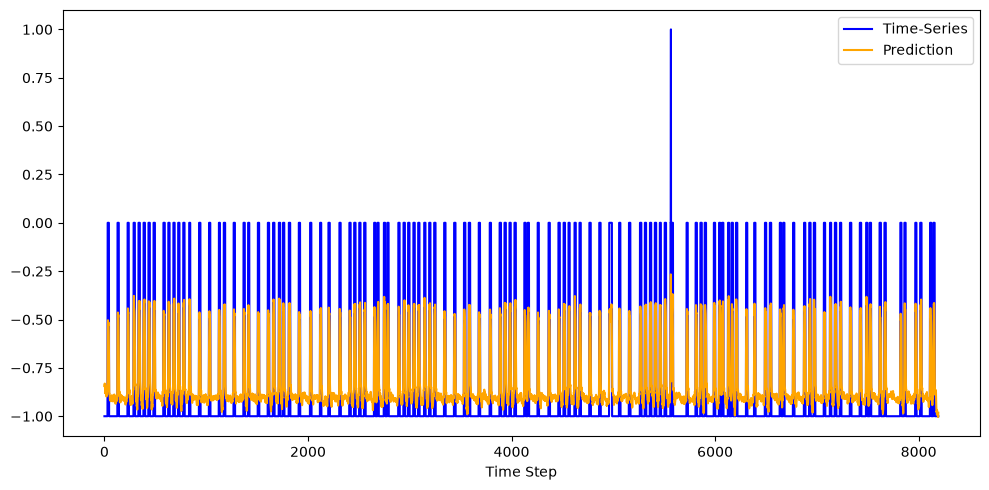

Channel T-9 Signal...
Epoch  25 | D Loss: 2.588058 | G Loss: -0.322617
Epoch  50 | D Loss: 0.231298 | G Loss: -0.041906
Epoch  75 | D Loss: 0.449546 | G Loss: -0.283214
Epoch 100 | D Loss: 0.050468 | G Loss: 0.182287
Epoch 125 | D Loss: -0.057374 | G Loss: -0.012584
Epoch 150 | D Loss: 0.075314 | G Loss: -0.024902
Epoch 175 | D Loss: 0.145431 | G Loss: -0.083817
Epoch 200 | D Loss: 0.105041 | G Loss: -0.055128
Epoch 225 | D Loss: 0.244279 | G Loss: -0.230175
Epoch 250 | D Loss: 0.396903 | G Loss: -0.359027
Epoch 275 | D Loss: -0.019369 | G Loss: -0.044440
Epoch 300 | D Loss: 0.461969 | G Loss: -0.240393
Epoch 325 | D Loss: 0.331799 | G Loss: -0.107957
Epoch 350 | D Loss: 0.219851 | G Loss: -0.104150
Epoch 375 | D Loss: 0.084076 | G Loss: -0.053115
Epoch 400 | D Loss: -0.032594 | G Loss: 0.037706
Epoch 425 | D Loss: 0.072624 | G Loss: -0.061967
Epoch 450 | D Loss: 1.411265 | G Loss: -1.307603
Epoch 475 | D Loss: 0.319428 | G Loss: -0.309192
Epoch 500 | D Loss: 0.253277 | G Loss: -0.2462

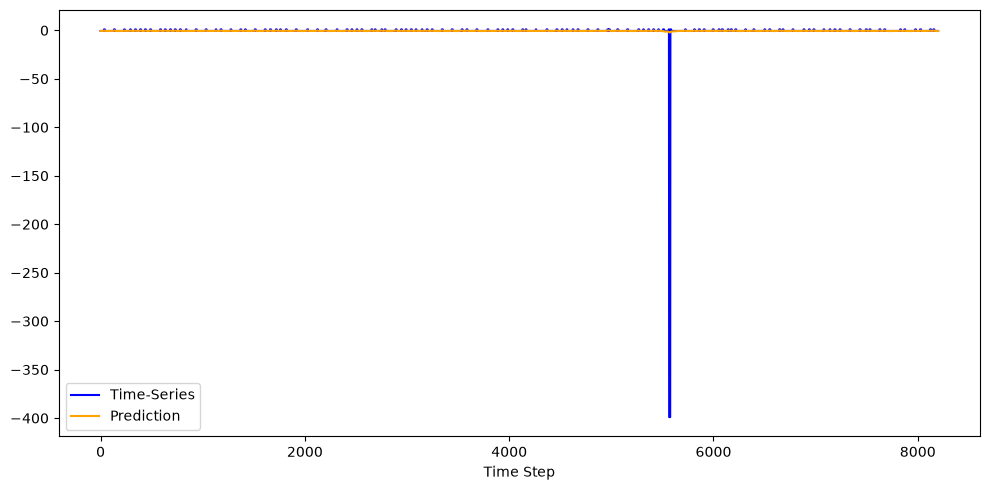

Channel T-9 Signal...
Epoch  25 | D Loss: 3.191504 | G Loss: -0.026762
Epoch  50 | D Loss: 2.398492 | G Loss: -1.463836
Epoch  75 | D Loss: 1.097440 | G Loss: -0.806884
Epoch 100 | D Loss: -0.540485 | G Loss: 0.702906
Epoch 125 | D Loss: 0.086849 | G Loss: -0.125033
Epoch 150 | D Loss: 0.667183 | G Loss: -0.600295
Epoch 175 | D Loss: 0.311108 | G Loss: -0.314779
Epoch 200 | D Loss: 0.304715 | G Loss: -0.387022
Epoch 225 | D Loss: 0.289770 | G Loss: -0.258260
Epoch 250 | D Loss: -0.012073 | G Loss: 0.098327
Epoch 275 | D Loss: 0.573615 | G Loss: -0.523869
Epoch 300 | D Loss: 0.430112 | G Loss: -0.446929
Epoch 325 | D Loss: 0.340537 | G Loss: -0.455221
Epoch 350 | D Loss: 0.350115 | G Loss: -0.297510
Epoch 375 | D Loss: 0.261027 | G Loss: -0.135931
Epoch 400 | D Loss: 0.402092 | G Loss: -0.432867
Epoch 425 | D Loss: 0.393660 | G Loss: -0.591859
Epoch 450 | D Loss: 0.375049 | G Loss: -0.654765
Epoch 475 | D Loss: 0.350880 | G Loss: -0.713285
Epoch 500 | D Loss: 0.345177 | G Loss: -0.80507

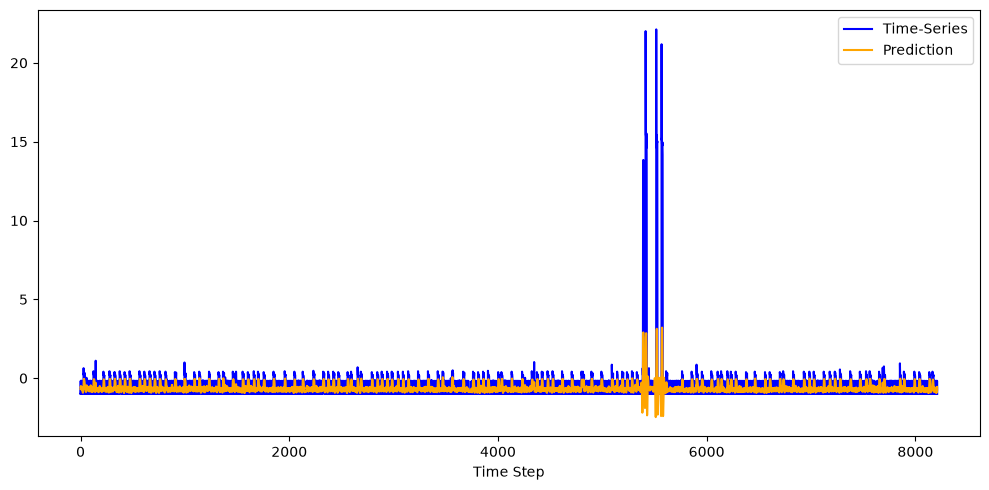

Channel T-9 Signal...
Epoch  25 | D Loss: 3.073428 | G Loss: -0.180476
Epoch  50 | D Loss: 1.388719 | G Loss: -0.123243
Epoch  75 | D Loss: -0.152269 | G Loss: 0.250966
Epoch 100 | D Loss: 0.826015 | G Loss: -0.807650
Epoch 125 | D Loss: 0.270821 | G Loss: -0.423095
Epoch 150 | D Loss: 0.321958 | G Loss: -0.519075
Epoch 175 | D Loss: 0.350682 | G Loss: -0.527910
Epoch 200 | D Loss: 0.378393 | G Loss: -0.520013
Epoch 225 | D Loss: 0.366625 | G Loss: -0.540848
Epoch 250 | D Loss: 0.259468 | G Loss: -0.449621
Epoch 275 | D Loss: 0.231485 | G Loss: -0.394456
Epoch 300 | D Loss: 0.265635 | G Loss: -0.402573
Epoch 325 | D Loss: 0.248427 | G Loss: -0.393736
Epoch 350 | D Loss: 0.261613 | G Loss: -0.486085
Epoch 375 | D Loss: 0.272033 | G Loss: -0.546885
Epoch 400 | D Loss: 0.294561 | G Loss: -0.627673
Epoch 425 | D Loss: 0.283533 | G Loss: -0.645794
Epoch 450 | D Loss: 0.241693 | G Loss: -0.596197
Epoch 475 | D Loss: 0.216393 | G Loss: -0.615303
Epoch 500 | D Loss: 0.197028 | G Loss: -0.61968

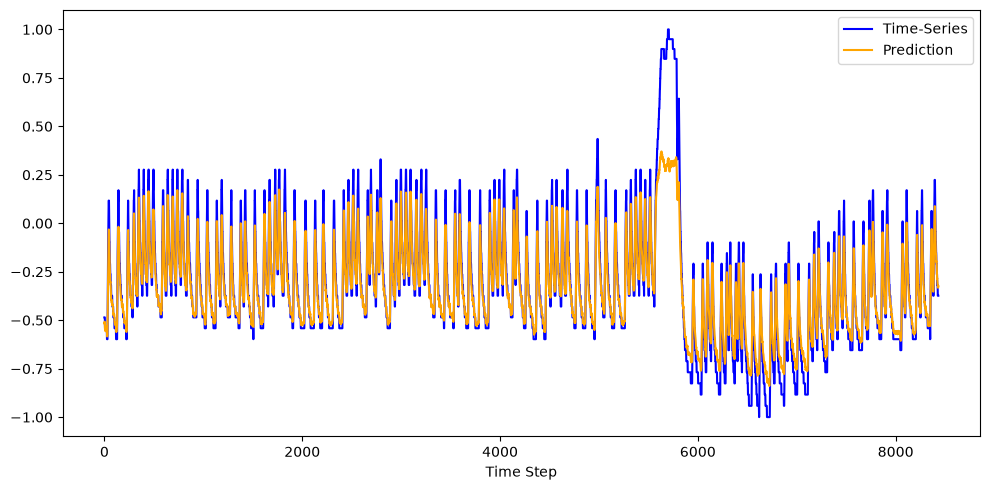

Channel T-9 Signal...
Epoch  25 | D Loss: 3.844709 | G Loss: 0.421847
Epoch  50 | D Loss: 1.214381 | G Loss: -0.301732
Epoch  75 | D Loss: 1.115386 | G Loss: -0.617297
Epoch 100 | D Loss: 3.136197 | G Loss: -2.826353
Epoch 125 | D Loss: 1.538020 | G Loss: -1.267441
Epoch 150 | D Loss: 1.034053 | G Loss: -0.784869
Epoch 175 | D Loss: 0.562688 | G Loss: -0.555264
Epoch 200 | D Loss: 0.559206 | G Loss: -0.214073
Epoch 225 | D Loss: 0.760718 | G Loss: -0.717058
Epoch 250 | D Loss: 0.345370 | G Loss: -0.311330
Epoch 275 | D Loss: 0.209202 | G Loss: -0.177870
Epoch 300 | D Loss: 0.207916 | G Loss: -0.141721
Epoch 325 | D Loss: 0.431254 | G Loss: -0.322418
Epoch 350 | D Loss: 0.269295 | G Loss: -0.164027
Epoch 375 | D Loss: 0.410328 | G Loss: -0.318982
Epoch 400 | D Loss: 0.389070 | G Loss: -0.377423
Epoch 425 | D Loss: 0.263293 | G Loss: -0.332091
Epoch 450 | D Loss: 0.181289 | G Loss: -0.306042
Epoch 475 | D Loss: 0.110418 | G Loss: -0.241287
Epoch 500 | D Loss: 0.067222 | G Loss: -0.257457

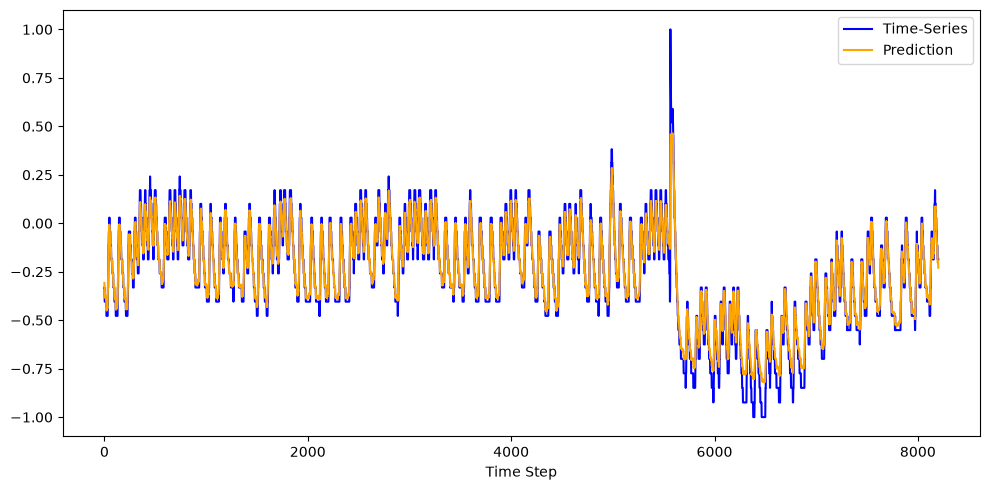

Channel T-9 Signal...
Epoch  25 | D Loss: 3.484545 | G Loss: -0.082821
Epoch  50 | D Loss: 0.877653 | G Loss: -0.393014
Epoch  75 | D Loss: 0.332184 | G Loss: -0.377114
Epoch 100 | D Loss: 0.176590 | G Loss: -0.227012
Epoch 125 | D Loss: 0.128187 | G Loss: -0.200708
Epoch 150 | D Loss: 0.317908 | G Loss: -0.432566
Epoch 175 | D Loss: 0.404207 | G Loss: -0.639965
Epoch 200 | D Loss: 0.374681 | G Loss: -0.509982
Epoch 225 | D Loss: 0.271392 | G Loss: -0.245930
Epoch 250 | D Loss: 0.150491 | G Loss: -0.150240
Epoch 275 | D Loss: 0.132818 | G Loss: -0.213244
Epoch 300 | D Loss: 0.074482 | G Loss: -0.065683
Epoch 325 | D Loss: 0.062536 | G Loss: -0.062927
Epoch 350 | D Loss: 0.052171 | G Loss: -0.096038
Epoch 375 | D Loss: 0.018856 | G Loss: -0.032532
Epoch 400 | D Loss: 0.035577 | G Loss: -0.163146
Epoch 425 | D Loss: 0.651715 | G Loss: -0.488484
Epoch 450 | D Loss: 0.301217 | G Loss: -0.318203
Epoch 475 | D Loss: 0.155703 | G Loss: -0.088668
Epoch 500 | D Loss: 0.096479 | G Loss: 0.082849

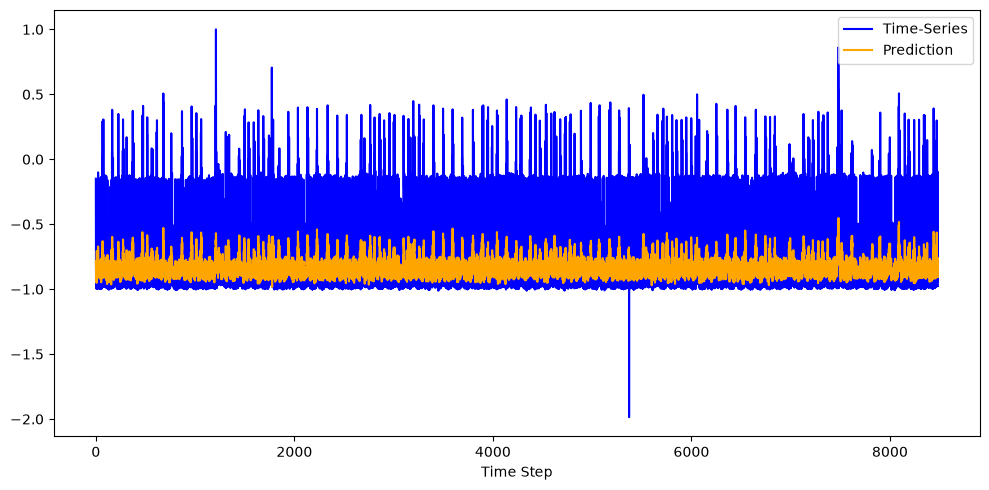

Channel T-9 Signal...
Epoch  25 | D Loss: 4.129429 | G Loss: 0.006819
Epoch  50 | D Loss: 0.691097 | G Loss: -0.061774
Epoch  75 | D Loss: 0.859733 | G Loss: -0.459866
Epoch 100 | D Loss: 0.322195 | G Loss: -0.141733
Epoch 125 | D Loss: 0.300014 | G Loss: -0.183284
Epoch 150 | D Loss: -0.806585 | G Loss: 1.020988
Epoch 175 | D Loss: 0.681263 | G Loss: -1.148552
Epoch 200 | D Loss: 0.564725 | G Loss: -0.441375
Epoch 225 | D Loss: 0.123159 | G Loss: -0.146919
Epoch 250 | D Loss: -0.088074 | G Loss: 0.162083
Epoch 275 | D Loss: 0.811901 | G Loss: -0.399722
Epoch 300 | D Loss: -0.228529 | G Loss: 0.182105
Epoch 325 | D Loss: 0.059651 | G Loss: 0.093929
Epoch 350 | D Loss: 0.019507 | G Loss: 0.313001
Epoch 375 | D Loss: -0.108333 | G Loss: 0.364981
Epoch 400 | D Loss: -0.063146 | G Loss: 0.375769
Epoch 425 | D Loss: -0.040800 | G Loss: 0.432867
Epoch 450 | D Loss: -0.018852 | G Loss: 0.502562
Epoch 475 | D Loss: -0.028652 | G Loss: 0.636109
Epoch 500 | D Loss: -0.089827 | G Loss: 0.832002
E

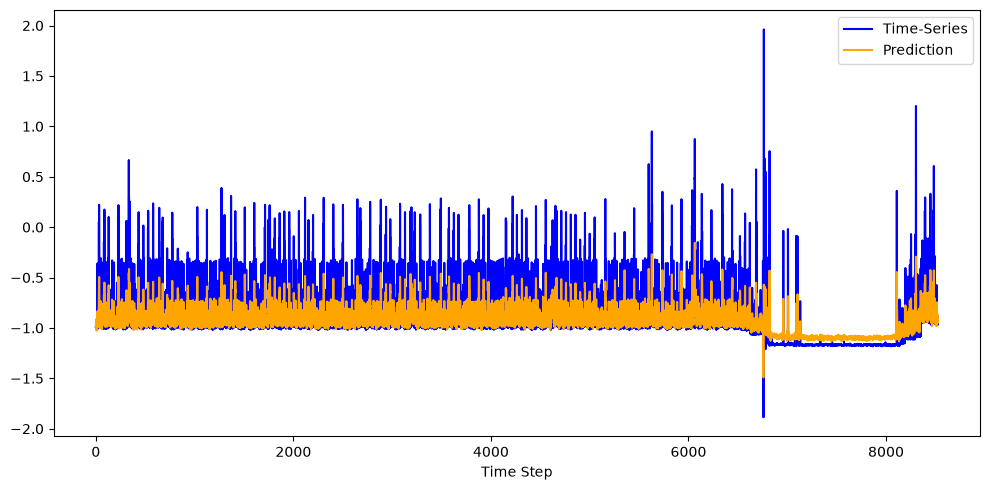

Channel T-9 Signal...
Epoch  25 | D Loss: 2.979815 | G Loss: 0.124166
Epoch  50 | D Loss: 0.418671 | G Loss: 0.078900
Epoch  75 | D Loss: 0.087791 | G Loss: 0.035876
Epoch 100 | D Loss: 0.061890 | G Loss: 0.075078
Epoch 125 | D Loss: 0.259133 | G Loss: -0.296357
Epoch 150 | D Loss: 0.024953 | G Loss: 0.047851
Epoch 175 | D Loss: 0.291317 | G Loss: -0.309639
Epoch 200 | D Loss: 0.071108 | G Loss: -0.105513
Epoch 225 | D Loss: 0.006960 | G Loss: 0.016846
Epoch 250 | D Loss: 0.019948 | G Loss: 0.117694
Epoch 275 | D Loss: 0.011549 | G Loss: 0.132045
Epoch 300 | D Loss: 0.007378 | G Loss: 0.133029
Epoch 325 | D Loss: 0.008528 | G Loss: 0.122560
Epoch 350 | D Loss: 0.017013 | G Loss: 0.021808
Epoch 375 | D Loss: -0.084452 | G Loss: -0.073066
Epoch 400 | D Loss: 0.311480 | G Loss: -0.347355
Epoch 425 | D Loss: 0.057768 | G Loss: -0.101876
Epoch 450 | D Loss: 0.039991 | G Loss: -0.086400
Epoch 475 | D Loss: 0.010164 | G Loss: -0.104825
Epoch 500 | D Loss: 0.089796 | G Loss: -0.379373
Epoch 52

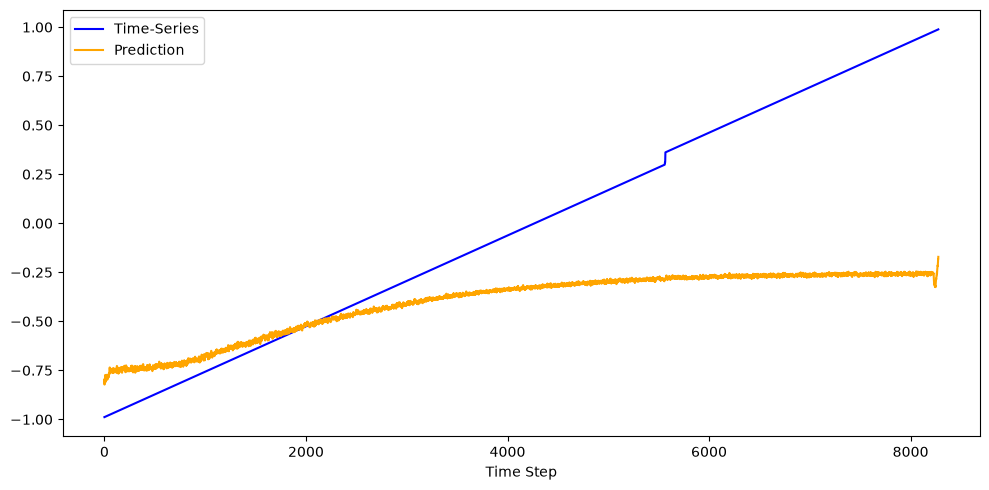

Channel T-9 Signal...
Epoch  25 | D Loss: 2.932171 | G Loss: 0.177567
Epoch  50 | D Loss: 1.610644 | G Loss: -0.242624
Epoch  75 | D Loss: 3.547027 | G Loss: -3.129638
Epoch 100 | D Loss: 1.727624 | G Loss: -1.287927
Epoch 125 | D Loss: -0.076403 | G Loss: 0.357362
Epoch 150 | D Loss: 0.515432 | G Loss: -0.421307
Epoch 175 | D Loss: 0.445872 | G Loss: -0.320950
Epoch 200 | D Loss: 0.196531 | G Loss: 0.077086
Epoch 225 | D Loss: 0.265146 | G Loss: 0.081841
Epoch 250 | D Loss: 0.283156 | G Loss: -0.038547
Epoch 275 | D Loss: 0.227302 | G Loss: -0.072613
Epoch 300 | D Loss: 0.192597 | G Loss: -0.080688
Epoch 325 | D Loss: 0.151981 | G Loss: -0.090342
Epoch 350 | D Loss: 0.124483 | G Loss: -0.092973
Epoch 375 | D Loss: 0.096766 | G Loss: -0.091697
Epoch 400 | D Loss: 0.073201 | G Loss: -0.105782
Epoch 425 | D Loss: 0.045172 | G Loss: -0.075425
Epoch 450 | D Loss: 0.033056 | G Loss: -0.075730
Epoch 475 | D Loss: 0.044188 | G Loss: -0.075817
Epoch 500 | D Loss: 0.031326 | G Loss: -0.074618
E

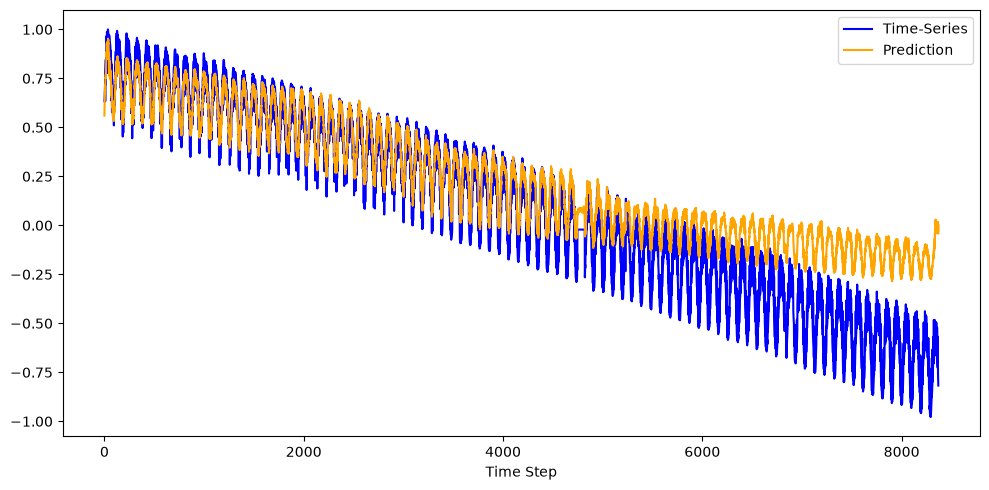

Channel T-9 Signal...
Epoch  25 | D Loss: 4.434917 | G Loss: -0.428244
Epoch  50 | D Loss: 1.821794 | G Loss: -0.320408
Epoch  75 | D Loss: -0.883788 | G Loss: 1.402779
Epoch 100 | D Loss: 1.288925 | G Loss: -1.025133
Epoch 125 | D Loss: 0.215604 | G Loss: -0.607703
Epoch 150 | D Loss: 0.395737 | G Loss: -1.059899
Epoch 175 | D Loss: 0.239816 | G Loss: -0.766213
Epoch 200 | D Loss: 0.093335 | G Loss: -0.643105
Epoch 225 | D Loss: 0.001892 | G Loss: -0.575690
Epoch 250 | D Loss: -0.153472 | G Loss: -0.451028
Epoch 275 | D Loss: 0.031927 | G Loss: -1.120935
Epoch 300 | D Loss: 0.026728 | G Loss: -1.142058
Epoch 325 | D Loss: 0.023255 | G Loss: -1.128295
Epoch 350 | D Loss: 0.026363 | G Loss: -1.099144
Epoch 375 | D Loss: 0.023911 | G Loss: -1.172946
Epoch 400 | D Loss: 0.016713 | G Loss: -1.385663
Epoch 425 | D Loss: 0.009099 | G Loss: -1.494196
Epoch 450 | D Loss: 0.002963 | G Loss: -1.599297
Epoch 475 | D Loss: -0.000099 | G Loss: -1.763015
Epoch 500 | D Loss: -0.002295 | G Loss: -1.83

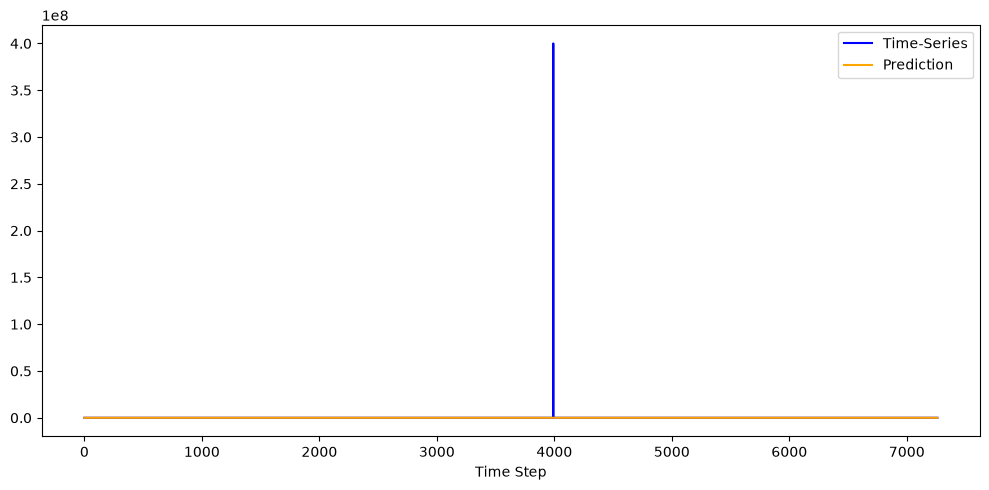

Channel T-9 Signal...
Epoch  25 | D Loss: 4.374495 | G Loss: -1.109614
Epoch  50 | D Loss: 1.437790 | G Loss: 0.174146
Epoch  75 | D Loss: 2.784460 | G Loss: -2.427755
Epoch 100 | D Loss: 1.553785 | G Loss: -1.303671
Epoch 125 | D Loss: 0.381471 | G Loss: -0.362075
Epoch 150 | D Loss: 0.197402 | G Loss: -0.249769
Epoch 175 | D Loss: -0.028462 | G Loss: -0.222515
Epoch 200 | D Loss: 0.385874 | G Loss: -0.423384
Epoch 225 | D Loss: 0.317166 | G Loss: -0.354175
Epoch 250 | D Loss: 0.209518 | G Loss: -0.254537
Epoch 275 | D Loss: 0.113176 | G Loss: -0.133201
Epoch 300 | D Loss: 0.127698 | G Loss: -0.101949
Epoch 325 | D Loss: 0.119619 | G Loss: -0.107182
Epoch 350 | D Loss: 0.085618 | G Loss: -0.103247
Epoch 375 | D Loss: 0.039925 | G Loss: -0.090302
Epoch 400 | D Loss: -0.012887 | G Loss: -0.042259
Epoch 425 | D Loss: -0.035964 | G Loss: 0.026645
Epoch 450 | D Loss: -0.051780 | G Loss: -0.014726
Epoch 475 | D Loss: -0.080946 | G Loss: 0.113296
Epoch 500 | D Loss: -0.113612 | G Loss: 0.249

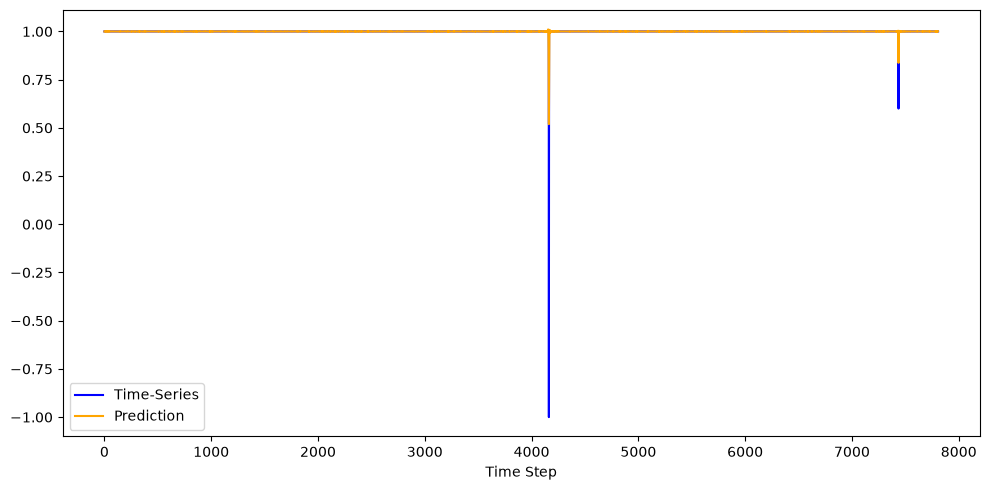

Channel T-9 Signal...
Epoch  25 | D Loss: 4.312599 | G Loss: -0.128994
Epoch  50 | D Loss: 1.415402 | G Loss: -0.059852
Epoch  75 | D Loss: 0.729210 | G Loss: -0.275442
Epoch 100 | D Loss: 0.006522 | G Loss: -0.095922
Epoch 125 | D Loss: 0.170291 | G Loss: -0.165720
Epoch 150 | D Loss: 0.293318 | G Loss: -0.362586
Epoch 175 | D Loss: 0.608355 | G Loss: -0.660091
Epoch 200 | D Loss: 0.438379 | G Loss: -0.405808
Epoch 225 | D Loss: 0.186250 | G Loss: -0.330926
Epoch 250 | D Loss: 0.266748 | G Loss: -0.416133
Epoch 275 | D Loss: 0.270001 | G Loss: -0.352243
Epoch 300 | D Loss: 0.202546 | G Loss: -0.299002
Epoch 325 | D Loss: 0.380353 | G Loss: -0.526200
Epoch 350 | D Loss: 0.410622 | G Loss: -0.603904
Epoch 375 | D Loss: 0.317079 | G Loss: -0.335846
Epoch 400 | D Loss: 0.350682 | G Loss: -0.453228
Epoch 425 | D Loss: 0.302715 | G Loss: -0.432051
Epoch 450 | D Loss: 0.326275 | G Loss: -0.557856
Epoch 475 | D Loss: 0.337717 | G Loss: -0.951967
Epoch 500 | D Loss: 0.299471 | G Loss: -0.64783

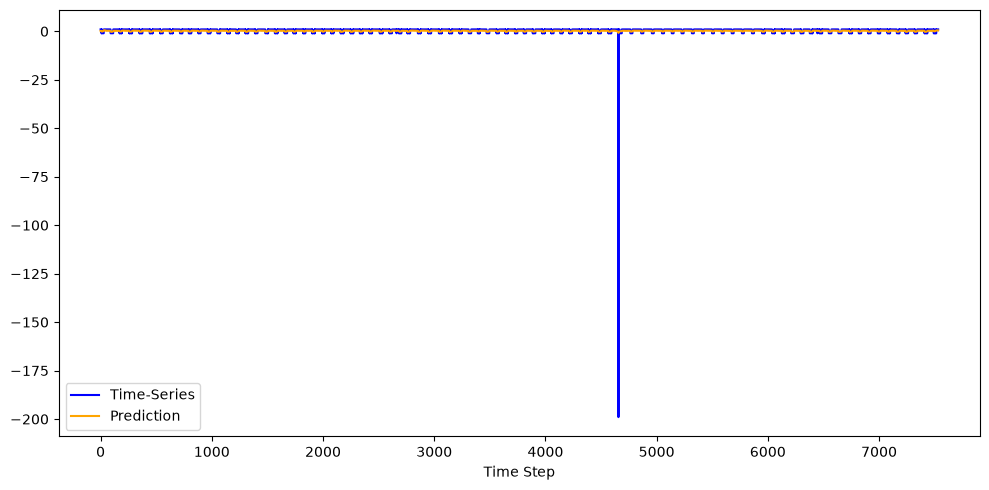

Channel T-9 Signal...
Epoch  25 | D Loss: 3.447192 | G Loss: 0.588335
Epoch  50 | D Loss: 2.133028 | G Loss: -0.198052
Epoch  75 | D Loss: 0.145524 | G Loss: 0.189636
Epoch 100 | D Loss: 0.638101 | G Loss: -0.774469
Epoch 125 | D Loss: -0.051378 | G Loss: 0.153756
Epoch 150 | D Loss: 3.707630 | G Loss: -3.492639
Epoch 175 | D Loss: 4.067713 | G Loss: -3.607664
Epoch 200 | D Loss: 3.361509 | G Loss: -2.957081
Epoch 225 | D Loss: 2.914713 | G Loss: -2.392273
Epoch 250 | D Loss: 1.329509 | G Loss: -1.043281
Epoch 275 | D Loss: 0.799936 | G Loss: -0.749404
Epoch 300 | D Loss: 0.467057 | G Loss: -0.445035
Epoch 325 | D Loss: 0.213425 | G Loss: -0.223597
Epoch 350 | D Loss: 0.544063 | G Loss: -0.543774
Epoch 375 | D Loss: 0.103980 | G Loss: -0.162639
Epoch 400 | D Loss: 0.153571 | G Loss: -0.219385
Epoch 425 | D Loss: 0.055740 | G Loss: -0.158711
Epoch 450 | D Loss: 0.135139 | G Loss: -0.212206
Epoch 475 | D Loss: 0.050950 | G Loss: -0.105269
Epoch 500 | D Loss: 0.160868 | G Loss: -0.224445


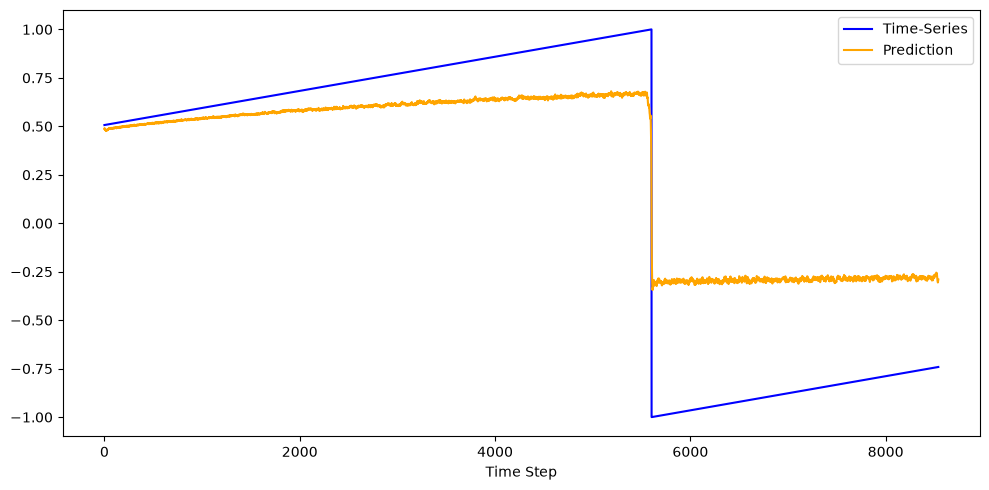

Channel T-9 Signal...
Epoch  25 | D Loss: 4.969245 | G Loss: -0.146472
Epoch  50 | D Loss: 2.636809 | G Loss: -0.422549
Epoch  75 | D Loss: 0.317221 | G Loss: 0.082119
Epoch 100 | D Loss: -0.713903 | G Loss: 0.796466
Epoch 125 | D Loss: 0.931590 | G Loss: -1.435062
Epoch 150 | D Loss: 0.360631 | G Loss: -0.454988
Epoch 175 | D Loss: 0.022048 | G Loss: 0.186203
Epoch 200 | D Loss: 0.239121 | G Loss: -0.168982
Epoch 225 | D Loss: 0.016057 | G Loss: -0.117229
Epoch 250 | D Loss: 0.039178 | G Loss: -0.146233
Epoch 275 | D Loss: 0.060509 | G Loss: -0.117890
Epoch 300 | D Loss: 0.063815 | G Loss: -0.176099
Epoch 325 | D Loss: 0.061761 | G Loss: -0.170321
Epoch 350 | D Loss: 0.065748 | G Loss: -0.230955
Epoch 375 | D Loss: 0.063137 | G Loss: -0.234756
Epoch 400 | D Loss: 0.040636 | G Loss: -0.233538
Epoch 425 | D Loss: 0.025515 | G Loss: -0.200226
Epoch 450 | D Loss: 0.012690 | G Loss: -0.227432
Epoch 475 | D Loss: 0.008679 | G Loss: -0.146722
Epoch 500 | D Loss: -0.000063 | G Loss: -0.094495

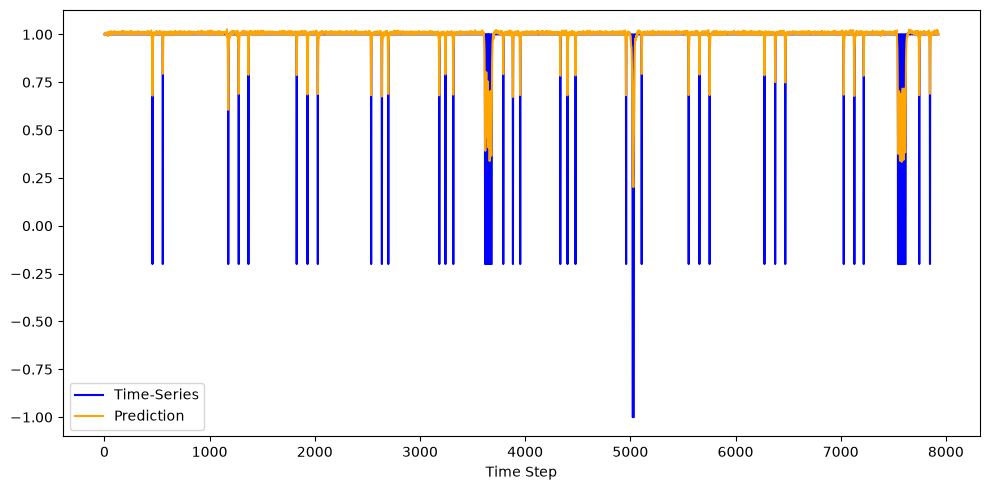

Channel T-9 Signal...
Epoch  25 | D Loss: 3.993434 | G Loss: -0.025146
Epoch  50 | D Loss: 1.929466 | G Loss: -0.812323
Epoch  75 | D Loss: -0.967776 | G Loss: 1.130352
Epoch 100 | D Loss: 0.315051 | G Loss: -0.227977
Epoch 125 | D Loss: 0.135964 | G Loss: -0.058265
Epoch 150 | D Loss: 0.160509 | G Loss: -0.083889
Epoch 175 | D Loss: 0.116185 | G Loss: -0.055540
Epoch 200 | D Loss: 0.055205 | G Loss: -0.011442
Epoch 225 | D Loss: 0.027394 | G Loss: 0.018982
Epoch 250 | D Loss: 0.057669 | G Loss: -0.063786
Epoch 275 | D Loss: 0.055132 | G Loss: -0.089381
Epoch 300 | D Loss: 0.044403 | G Loss: -0.057099
Epoch 325 | D Loss: 0.038918 | G Loss: -0.047163
Epoch 350 | D Loss: 0.042606 | G Loss: -0.051212
Epoch 375 | D Loss: 0.039084 | G Loss: -0.001071
Epoch 400 | D Loss: 0.032435 | G Loss: 0.011218
Epoch 425 | D Loss: 0.023093 | G Loss: -0.014651
Epoch 450 | D Loss: -0.005018 | G Loss: -0.022474
Epoch 475 | D Loss: -0.000076 | G Loss: -0.042907
Epoch 500 | D Loss: -0.022604 | G Loss: -0.0091

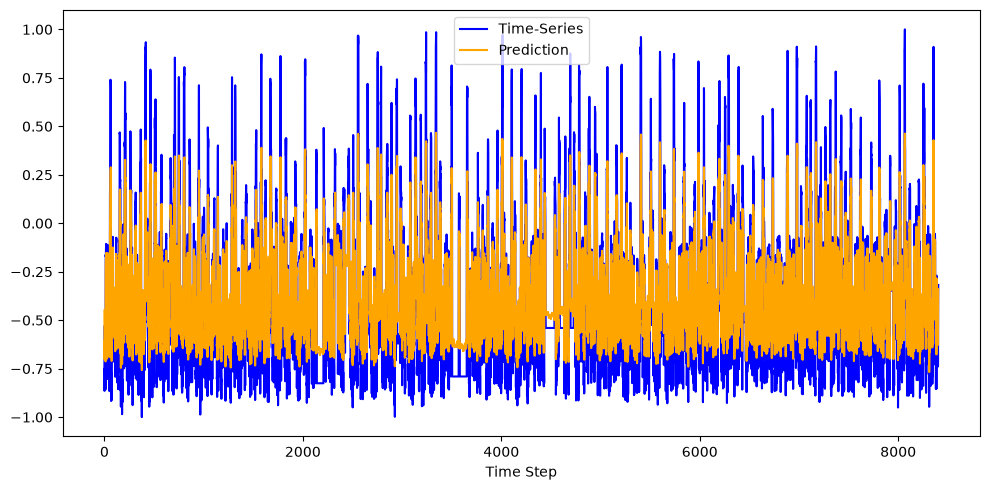

Channel T-9 Signal...
Epoch  25 | D Loss: 8.202200 | G Loss: -3.696565
Epoch  50 | D Loss: 8.124097 | G Loss: -4.402895
Epoch  75 | D Loss: 5.491352 | G Loss: -1.173330
Epoch 100 | D Loss: 3.092044 | G Loss: 0.460615
Epoch 125 | D Loss: 1.533411 | G Loss: 0.161937
Epoch 150 | D Loss: 0.466485 | G Loss: 0.147176
Epoch 175 | D Loss: 0.220751 | G Loss: -0.185228
Epoch 200 | D Loss: 1.057866 | G Loss: -1.163320
Epoch 225 | D Loss: 0.308866 | G Loss: -0.420562
Epoch 250 | D Loss: 0.002003 | G Loss: 0.071423
Epoch 275 | D Loss: 1.332449 | G Loss: -1.121045
Epoch 300 | D Loss: 0.551312 | G Loss: -0.394367
Epoch 325 | D Loss: 0.156243 | G Loss: -0.018215
Epoch 350 | D Loss: 0.047096 | G Loss: 0.039746
Epoch 375 | D Loss: 0.266092 | G Loss: -0.220098
Epoch 400 | D Loss: 0.275771 | G Loss: -0.208604
Epoch 425 | D Loss: 0.129497 | G Loss: -0.047322
Epoch 450 | D Loss: 0.172393 | G Loss: -0.097843
Epoch 475 | D Loss: 0.187342 | G Loss: -0.193455
Epoch 500 | D Loss: 0.176464 | G Loss: -0.207645
Epo

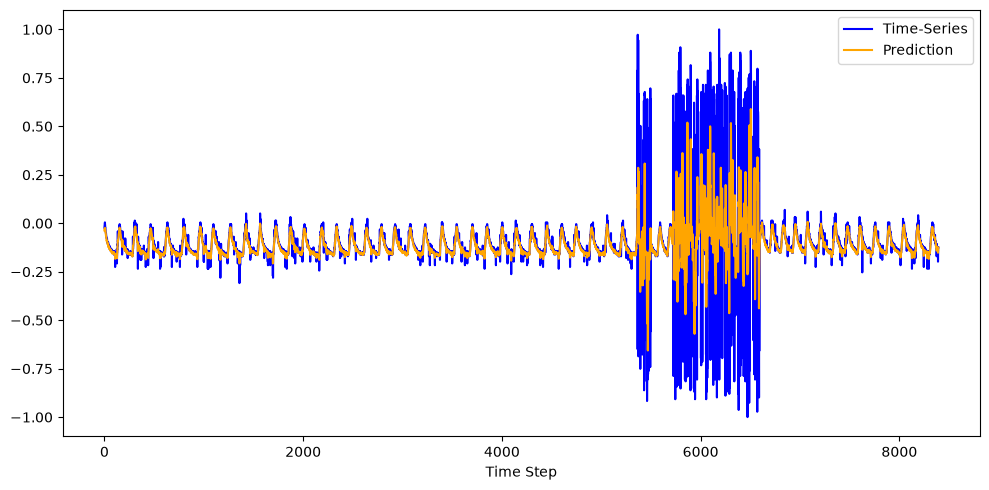

Channel T-9 Signal...
Epoch  25 | D Loss: 3.674705 | G Loss: 0.042338
Epoch  50 | D Loss: 3.872135 | G Loss: -2.683111
Epoch  75 | D Loss: 6.550942 | G Loss: -4.454958
Epoch 100 | D Loss: 5.839530 | G Loss: -3.570258
Epoch 125 | D Loss: 2.593282 | G Loss: -1.179635
Epoch 150 | D Loss: 0.802185 | G Loss: -0.539142
Epoch 175 | D Loss: 0.371412 | G Loss: -0.303455
Epoch 200 | D Loss: 0.077664 | G Loss: -0.017744
Epoch 225 | D Loss: 0.211005 | G Loss: -0.069362
Epoch 250 | D Loss: 0.273341 | G Loss: -0.108488
Epoch 275 | D Loss: -0.088424 | G Loss: 0.218567
Epoch 300 | D Loss: 0.125959 | G Loss: -0.111862
Epoch 325 | D Loss: 0.169823 | G Loss: -0.162785
Epoch 350 | D Loss: 0.327862 | G Loss: -0.303704
Epoch 375 | D Loss: 0.252196 | G Loss: -0.260819
Epoch 400 | D Loss: 0.230499 | G Loss: -0.235784
Epoch 425 | D Loss: 0.200808 | G Loss: -0.344233
Epoch 450 | D Loss: 0.182301 | G Loss: -0.398306
Epoch 475 | D Loss: 0.108012 | G Loss: -0.505825
Epoch 500 | D Loss: 0.022712 | G Loss: -0.788302

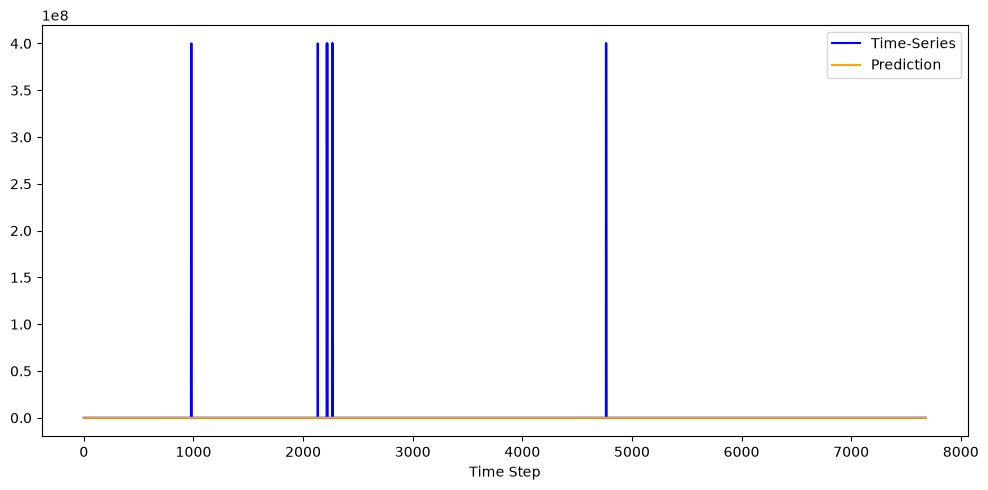

Channel T-9 Signal...
Epoch  25 | D Loss: 3.434285 | G Loss: 0.164601
Epoch  50 | D Loss: 0.541622 | G Loss: 0.193248
Epoch  75 | D Loss: 0.021815 | G Loss: 0.228057
Epoch 100 | D Loss: 0.022286 | G Loss: 0.214908
Epoch 125 | D Loss: 0.024872 | G Loss: 0.208530
Epoch 150 | D Loss: 0.026324 | G Loss: 0.207688
Epoch 175 | D Loss: 0.084950 | G Loss: 0.196399
Epoch 200 | D Loss: 0.021519 | G Loss: 0.338342
Epoch 225 | D Loss: 0.005836 | G Loss: 0.323766
Epoch 250 | D Loss: -0.008205 | G Loss: 0.348717
Epoch 275 | D Loss: 0.030198 | G Loss: 0.330921
Epoch 300 | D Loss: -0.088881 | G Loss: 0.503437
Epoch 325 | D Loss: -0.043605 | G Loss: 0.471850
Epoch 350 | D Loss: 0.101537 | G Loss: 0.326476
Epoch 375 | D Loss: 0.094492 | G Loss: 0.323681
Epoch 400 | D Loss: 0.010500 | G Loss: 0.364099
Epoch 425 | D Loss: 0.014493 | G Loss: 0.352851
Epoch 450 | D Loss: 0.024241 | G Loss: 0.347912
Epoch 475 | D Loss: -0.010277 | G Loss: 0.373523
Epoch 500 | D Loss: 0.012365 | G Loss: 0.326517
Epoch 525 | D 

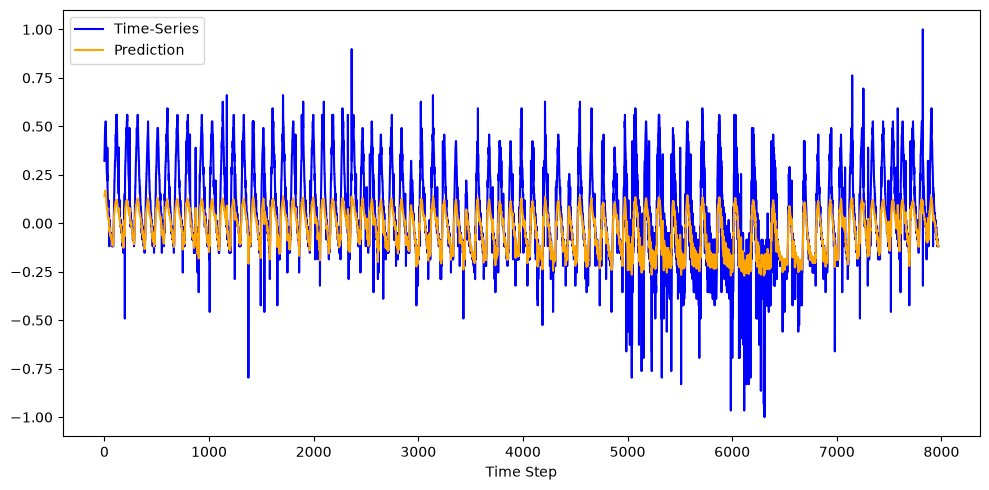

Channel T-9 Signal...
Epoch  25 | D Loss: 4.681538 | G Loss: -0.476696
Epoch  50 | D Loss: 1.400291 | G Loss: 1.224997
Epoch  75 | D Loss: -1.085708 | G Loss: 0.466002
Epoch 100 | D Loss: 2.656834 | G Loss: -2.384924
Epoch 125 | D Loss: 5.453832 | G Loss: -4.813589
Epoch 150 | D Loss: 2.820420 | G Loss: -2.170008
Epoch 175 | D Loss: 0.985945 | G Loss: -0.459661
Epoch 200 | D Loss: -0.106624 | G Loss: 0.233169
Epoch 225 | D Loss: 0.656251 | G Loss: -0.670016
Epoch 250 | D Loss: 0.404494 | G Loss: -0.242437
Epoch 275 | D Loss: 0.406725 | G Loss: -0.546248
Epoch 300 | D Loss: -0.012334 | G Loss: 0.092061
Epoch 325 | D Loss: 0.271517 | G Loss: -0.128830
Epoch 350 | D Loss: 0.245832 | G Loss: -0.194520
Epoch 375 | D Loss: 0.208124 | G Loss: -0.191591
Epoch 400 | D Loss: 0.142982 | G Loss: -0.067987
Epoch 425 | D Loss: 0.146807 | G Loss: -0.039915
Epoch 450 | D Loss: 0.146044 | G Loss: -0.010937
Epoch 475 | D Loss: 0.129723 | G Loss: 0.013132
Epoch 500 | D Loss: 0.108068 | G Loss: 0.042588
E

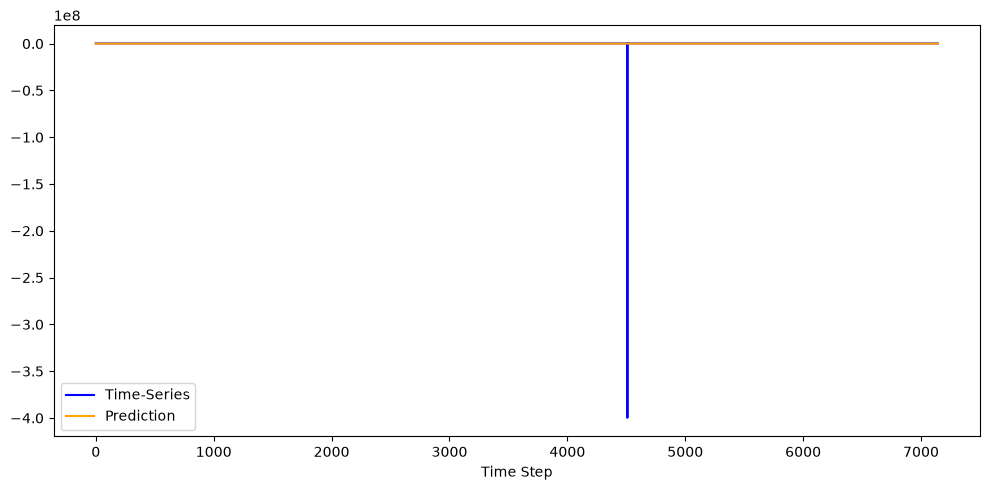

Channel T-9 Signal...
Epoch  25 | D Loss: 4.292674 | G Loss: -0.134592
Epoch  50 | D Loss: 2.472749 | G Loss: -1.242079
Epoch  75 | D Loss: 0.692436 | G Loss: -0.434840
Epoch 100 | D Loss: 0.827186 | G Loss: -0.629494
Epoch 125 | D Loss: -0.048521 | G Loss: -0.060569
Epoch 150 | D Loss: 0.831431 | G Loss: -0.921933
Epoch 175 | D Loss: 0.324572 | G Loss: -0.124071
Epoch 200 | D Loss: 0.291377 | G Loss: -0.265579
Epoch 225 | D Loss: 1.039574 | G Loss: -1.246801
Epoch 250 | D Loss: 0.323066 | G Loss: -0.198349
Epoch 275 | D Loss: 0.352395 | G Loss: -0.332998
Epoch 300 | D Loss: 0.367673 | G Loss: -0.300051
Epoch 325 | D Loss: 1.778291 | G Loss: -1.802487
Epoch 350 | D Loss: 0.260181 | G Loss: -0.259823
Epoch 375 | D Loss: 1.589278 | G Loss: -1.776989
Epoch 400 | D Loss: 0.225185 | G Loss: -0.079166
Epoch 425 | D Loss: -0.022646 | G Loss: 0.016404
Epoch 450 | D Loss: 0.067805 | G Loss: 0.025579
Epoch 475 | D Loss: 0.415550 | G Loss: -0.453476
Epoch 500 | D Loss: 0.765187 | G Loss: -0.77708

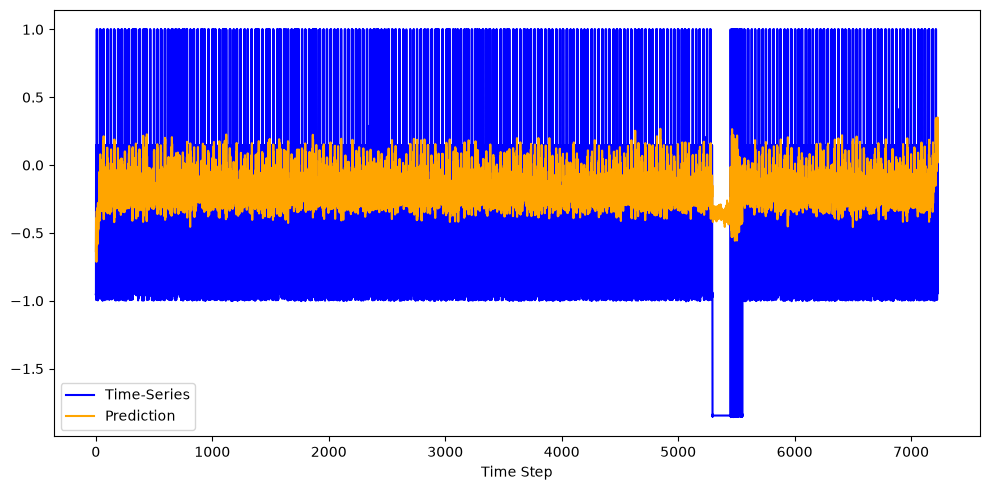

Channel T-9 Signal...
Epoch  25 | D Loss: 2.653232 | G Loss: 0.215827
Epoch  50 | D Loss: 2.211615 | G Loss: -2.309978
Epoch  75 | D Loss: 5.529524 | G Loss: -4.578253
Epoch 100 | D Loss: 2.306712 | G Loss: -1.705077
Epoch 125 | D Loss: 0.067908 | G Loss: -0.095447
Epoch 150 | D Loss: 0.600477 | G Loss: -0.607862
Epoch 175 | D Loss: 0.614282 | G Loss: -0.601755
Epoch 200 | D Loss: 0.456953 | G Loss: -0.436716
Epoch 225 | D Loss: 0.224475 | G Loss: -0.232575
Epoch 250 | D Loss: 0.201419 | G Loss: -0.162169
Epoch 275 | D Loss: 0.257436 | G Loss: -0.291990
Epoch 300 | D Loss: 0.344817 | G Loss: -0.400164
Epoch 325 | D Loss: 0.616555 | G Loss: -0.622352
Epoch 350 | D Loss: 0.173485 | G Loss: -0.193710
Epoch 375 | D Loss: 0.311024 | G Loss: -0.327118
Epoch 400 | D Loss: 0.193605 | G Loss: -0.374154
Epoch 425 | D Loss: 0.290467 | G Loss: -0.194044
Epoch 450 | D Loss: 0.292476 | G Loss: -0.215712
Epoch 475 | D Loss: 0.340843 | G Loss: -0.204776
Epoch 500 | D Loss: 0.316162 | G Loss: -0.066657

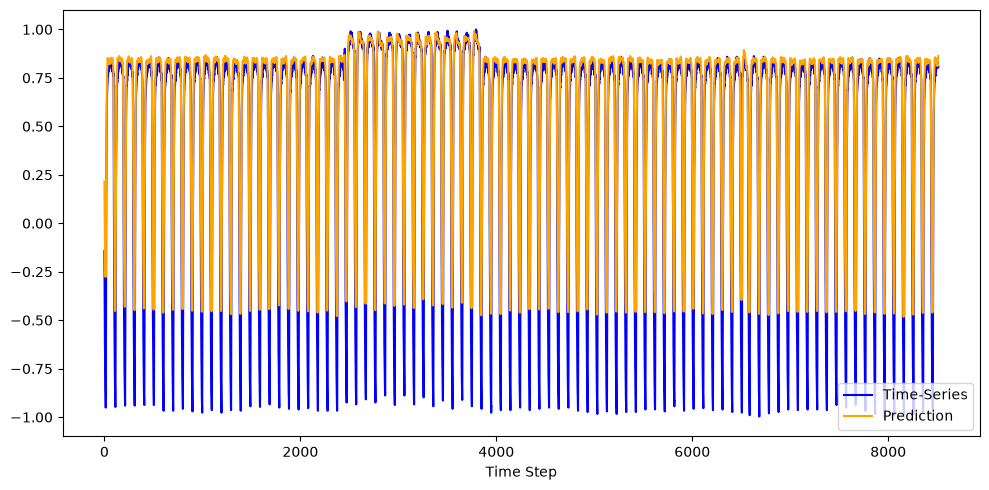

Channel T-9 Signal...
Epoch  25 | D Loss: 4.257102 | G Loss: 0.023249
Epoch  50 | D Loss: 0.960739 | G Loss: 0.027363
Epoch  75 | D Loss: 0.006523 | G Loss: 0.006928
Epoch 100 | D Loss: -0.067224 | G Loss: 0.137922
Epoch 125 | D Loss: 0.061431 | G Loss: -0.039521
Epoch 150 | D Loss: 0.340496 | G Loss: -0.330761
Epoch 175 | D Loss: 0.408746 | G Loss: -0.408655
Epoch 200 | D Loss: 0.390863 | G Loss: -0.374827
Epoch 225 | D Loss: 0.269870 | G Loss: -0.235875
Epoch 250 | D Loss: 0.238611 | G Loss: -0.175197
Epoch 275 | D Loss: 0.275603 | G Loss: -0.213437
Epoch 300 | D Loss: 0.053339 | G Loss: 0.021183
Epoch 325 | D Loss: 0.110432 | G Loss: 0.061626
Epoch 350 | D Loss: 0.309791 | G Loss: 0.042365
Epoch 375 | D Loss: 0.010422 | G Loss: 0.232963
Epoch 400 | D Loss: 0.025843 | G Loss: 0.310957
Epoch 425 | D Loss: 0.040612 | G Loss: 0.319651
Epoch 450 | D Loss: -0.020824 | G Loss: 0.442173
Epoch 475 | D Loss: -0.020178 | G Loss: 0.502783
Epoch 500 | D Loss: -0.098028 | G Loss: 0.915078
Epoch 5

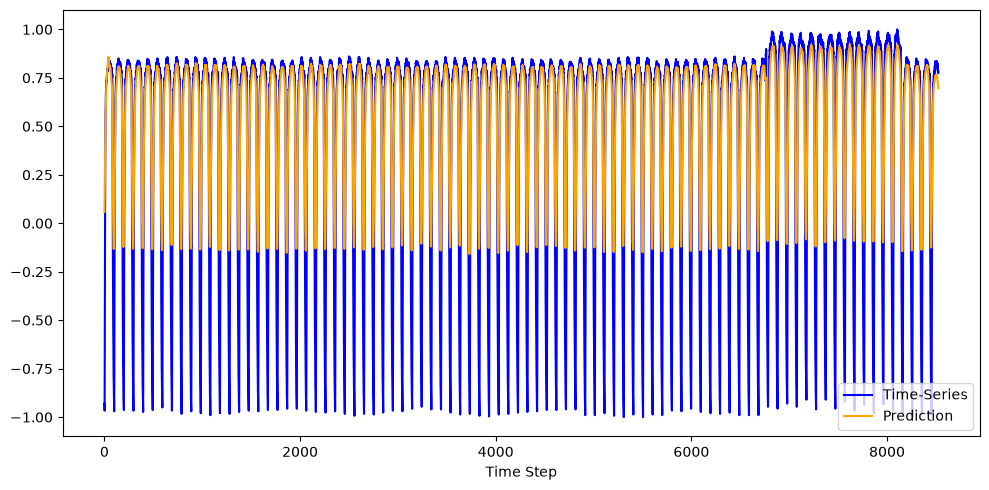

Channel T-9 Signal...
Epoch  25 | D Loss: 5.260018 | G Loss: -0.455786
Epoch  50 | D Loss: 5.693708 | G Loss: -3.094852
Epoch  75 | D Loss: 0.961913 | G Loss: 0.568152
Epoch 100 | D Loss: 1.419339 | G Loss: -0.532426
Epoch 125 | D Loss: 0.919056 | G Loss: -0.327769
Epoch 150 | D Loss: 0.778904 | G Loss: -0.292063
Epoch 175 | D Loss: 0.627244 | G Loss: -0.126190
Epoch 200 | D Loss: 0.329519 | G Loss: 0.282173
Epoch 225 | D Loss: 0.351527 | G Loss: 0.090667
Epoch 250 | D Loss: 0.230700 | G Loss: 0.111310
Epoch 275 | D Loss: 0.155379 | G Loss: 0.162416
Epoch 300 | D Loss: 0.115590 | G Loss: 0.181396
Epoch 325 | D Loss: 0.098998 | G Loss: 0.205212
Epoch 350 | D Loss: 0.054213 | G Loss: 0.219531
Epoch 375 | D Loss: 0.053694 | G Loss: 0.232745
Epoch 400 | D Loss: 0.045133 | G Loss: 0.280533
Epoch 425 | D Loss: 0.057839 | G Loss: 0.268011
Epoch 450 | D Loss: 0.077256 | G Loss: 0.207120
Epoch 475 | D Loss: 0.071788 | G Loss: 0.241022
Epoch 500 | D Loss: 0.158844 | G Loss: 0.190147
Epoch 525 | 

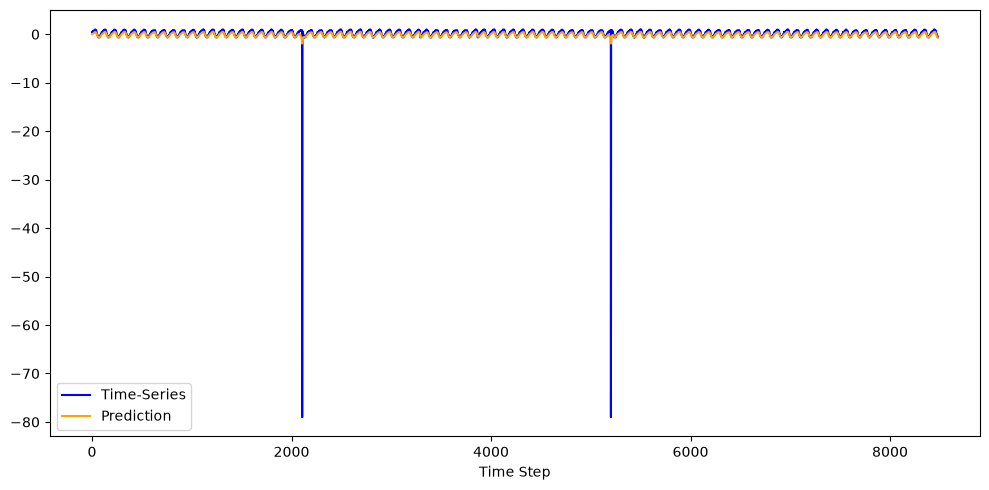

------------------
SMAP Metrics
------------------
[point] Precision: 0.257 | Recall: 0.745 | F1: 0.345
[area] Precision: 0.178 | Recall: 0.780 | F1: 0.277


In [24]:
total_metrics = {name: np.zeros(3) for (name, _) in SMAP_HYPERPARAMS["rec_error_funcs"]}
total_evaluated = 0

for smap_channel, X_train, X_test, y_test in zip(smap_channels_names, smap_train, smap_test, smap_test_y):
    # all data points are considered to be normal in the training tensor,
    # thus the labels consist of a tensor full of zeros
    y_train = torch.zeros(X_train.shape[0])

    print(f"Channel {msl_channel} Signal...")

    X_train = np.expand_dims(X_train[:, 0], axis=1)
    X_test = np.expand_dims(X_test[:, 0], axis=1)
    
    try:
        metrics = run_pipeline(
            X=X_train, y=y_train,
            X_test=X_test, y_test=y_test,
            **MSL_HYPERPARAMS
        )
        for key in total_metrics:
            total_metrics[key] += np.array(metrics[key])
        total_evaluated += 1
    except:
        continue

print("------------------")
print("SMAP Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / total_evaluated
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")